# CricketMind - LangGraph Demo

Runnable slice of the CricketMind architecture (Architecture v2, Figure 1).
The graph is built with **dummy node functions** first so the wiring, the routing
and both correction loops can be verified before any real model is attached.

Scope for today:

| Node | Stage |
|---|---|
| `N1` | Video Input (15 frames) |
| `N2` | Vision Encoder - EfficientNetV2-S |
| `N3` | Text Encoder - query semantics |
| `N4` | Temporal Fusion - **Temporal Transformer** (2 layers, 4 heads) |
| `N5` | Classifier Head - 15 shot classes |
| `N6` | Multimodal Shot DNA |
| `N7a` / `N7b` | FAISS retrieval - Cricsheet / Kaggle |
| `N8` / `N9` | Stats Analysis Engine / What-If Simulator |
| `N10` | Supervisor Router - dynamic dispatch |
| `N11a`-`N11l` | Twelve stakeholder agents |
| `N12` / `N13` | Report synthesis / Final output |

Plus the two gates: **Conf. Check** (retry loop) and **Faith Check** (regenerate loop).

**Temporal stage note:** N4 is a temporal transformer, not a GRU. Self-attention lets
frame 1 (pre-delivery stance) relate directly to frame 15 (follow-through), which is
what separates near-identical strokes such as sweep vs. reverse sweep. The GRU is the
earlier baseline it replaces.

**Hardware note:** this notebook runs unmodified on both machines - Intel Arc B580
(`xpu` backend) and NVIDIA RTX 3070 (`cuda` backend), falling back to CPU.
Nothing below hardcodes a device.

## 0. Environment setup (run once per machine)

`torch` is installed *per machine* with a different wheel — do **not** pin it in a shared
requirements file, or one of the two setups will break.

```bash
# Intel Arc B580
pip install torch torchvision --index-url https://download.pytorch.org/whl/xpu

# NVIDIA RTX 3070
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124
```

The LangGraph stack is identical on both:

```bash
pip install langgraph langchain-core pydantic python-dotenv ipykernel
```

In [1]:
# Uncomment on a fresh machine. torch/torchvision are installed separately (see above).
# %pip install -q langgraph langchain-core pydantic python-dotenv ipykernel

## 1. Imports

In [2]:
import os
import sys
import json
import time
import random
from pathlib import Path
from dataclasses import dataclass, field
from typing import Annotated, Any, Literal, Optional, TypedDict
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
# Intel Arc (XPU) support lives in a separate extension on older torch builds.
# torch >= 2.5 ships torch.xpu natively, so this import is optional and must
# never be allowed to hard-fail on the NVIDIA machine.
try:
    import intel_extension_for_pytorch as ipex
    _HAS_IPEX = True
except ImportError:
    _HAS_IPEX = False
#langgraph / langchain
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel, Field
from IPython.display import display, Markdown
print(f"python      {sys.version.split()[0]}")
print(f"torch       {torch.__version__}")
print(f"torchvision {torchvision.__version__}")
print(f"numpy       {np.__version__}")
print(f"opencv      {cv2.__version__}")
print(f"ipex        {'yes' if _HAS_IPEX else 'not installed (fine on CUDA/CPU)'}")

python      3.10.11
torch       2.13.0+xpu
torchvision 0.28.0+xpu
numpy       2.2.6
opencv      5.0.0
ipex        not installed (fine on CUDA/CPU)


## 2. Device resolution — Arc B580 / RTX 3070 / CPU

In [3]:
def get_device() -> torch.device:
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        return torch.device("xpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

In [4]:
def get_amp_settings(device: torch.device) -> tuple[Optional[torch.dtype], bool]:
    """Returns (autocast_dtype_or_None, use_grad_scaler)."""
    if device.type == "xpu":
        return torch.bfloat16, False     # Arc: bf16 is native, no scaler needed
    if device.type == "cuda":
        return torch.float16, True       # Ampere: fp16 + GradScaler
    return None, False                   # CPU: no autocast

In [5]:
def empty_cache(device: torch.device) -> None:
    if device.type == "xpu":
        torch.xpu.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

In [6]:
def describe_device(device: torch.device) -> str:
    if device.type == "xpu":
        return torch.xpu.get_device_name(0)
    if device.type == "cuda":
        return torch.cuda.get_device_name(0)
    return "CPU"

In [7]:
DEVICE = get_device()
AMP_DTYPE, USE_SCALER = get_amp_settings(DEVICE)
print(f"device      {DEVICE}  ({describe_device(DEVICE)})")
print(f"autocast    {AMP_DTYPE}")
print(f"gradscaler  {USE_SCALER}")

device      xpu  (Intel(R) Arc(TM) B580 Graphics)
autocast    torch.bfloat16
gradscaler  False


## 3. Constants

The 15 CricShot10k classes

In [8]:
SHOT_CLASSES = [
    "Cover Drive", "Defensive", "Down The Wicket", "Flick", "Hook",
    "Late Cut", "Lofted Legside", "Lofted Offside", "Pull",
    "Reverse Sweep", "Scoop", "Square Cut", "Straight Drive",
    "Sweep", "Upper Cut",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(SHOT_CLASSES)}
NUM_CLASSES  = len(SHOT_CLASSES)          
NUM_FRAMES   = 15                        
FRAME_SIZE   = 224                        
CONF_THRESHOLD = 0.70                     # N5 -> Conf. Check gate
MAX_RETRIES    = 2                        # bound on the retry loop
MAX_REGENS     = 2                        # bound on the regenerate loop
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
print(f"classes      {NUM_CLASSES}")
print(f"clip shape   ({NUM_FRAMES}, 3, {FRAME_SIZE}, {FRAME_SIZE})")
print(f"gates        conf>={CONF_THRESHOLD}  retries<={MAX_RETRIES}  regens<={MAX_REGENS}")
print(f"root         {PROJECT_ROOT}")

classes      15
clip shape   (15, 3, 224, 224)
gates        conf>=0.7  retries<=2  regens<=2
root         d:\Cricket\cricshot-improve


## 4. The graph State

Every node in the graph reads from and writes into one shared `TypedDict`. A node
returns a **partial** dict containing only the keys it changed; LangGraph merges
that into the running state.

How a key is merged depends on whether it is annotated with a **reducer**:

| Kind | Merge behaviour | Used for |
|---|---|---|
| plain key | last write wins (overwrite) | scalars only one node ever writes |
| `Annotated[list, operator.add]` | concatenate | fields written by parallel branches |
| `Annotated[list, upsert_findings]` | replace by agent id | agent findings, which the regenerate loop re-runs |


In [9]:
import operator

In [10]:
def upsert_findings(left: list, right: list) -> list:
    """Decides how to combine agent findings when more than one is written.

    Every agent writes its finding into `agent_findings`. Two different things
    have to happen, depending on WHO wrote it:

      1. Findings from DIFFERENT agents must pile up.
         Coaches writes, Players writes  ->  the report has 2 findings.

      2. If the SAME agent writes twice, the new finding must REPLACE the old.
         Coaches writes, Coaches writes again  ->  the report has 1 finding.

    Rule 2 is the one that matters. When an agent fails the Faith Check it gets
    re-run, so it produces a finding twice - once with the fabricated number and
    once corrected. If we simply glued the two lists together, the rejected
    finding would still be sitting in the list and would reach the user. That is
    exactly what the Faith Check was supposed to prevent.

    The way we get both behaviours is to keep ONE SLOT PER AGENT, named after
    that agent. Writing into a slot that already exists overwrites whatever was
    in it, and the slot stays where it was, so the report does not get
    reshuffled just because one agent had to retry.
    """

    # LangGraph passes `left` as None on the very first write, before anything
    # is in state. Looping over None would crash, so turn it into an empty list.
    if left is None:
        left = []
    if right is None:
        right = []

    # The slots. The key is the agent id ("n11b"), the value is its finding.
    # A dictionary can never hold the same key twice, and that is what stops an
    # agent from ending up with two findings.
    slots = {}

    # Put the findings we already had into their slots.
    for finding in left:
        agent_id = finding["agent"]
        slots[agent_id] = finding

    # Add the new findings. This single line covers both rules above:
    #   - agent id not seen before -> a new slot is created  (rule 1)
    #   - agent id already there   -> its slot is overwritten (rule 2)
    for finding in right:
        agent_id = finding["agent"]
        slots[agent_id] = finding

    # The slot names were only there to spot duplicates. Drop them and hand
    # back a plain list of findings, in the order the agents first appeared.
    return list(slots.values())


In [11]:
class CricketMindState(TypedDict, total=False):
    """Shared state for the CricketMind graph (Architecture v2).

    total=False because nodes contribute keys progressively -- at START only
    video_path and query exist, and asserting otherwise would make every node
    responsible for fields it knows nothing about.
    """

    #inputs
    video_path: str
    query: str

    # N1/N2/N4/N5: perception
    frames:            list          # N1 -> NUM_FRAMES sampled frames
    frame_features:    Any           # N2 -> (T, 1280) per-frame embeddings
    temporal_features: Any           # N4 -> (1280,) transformer-pooled vector
    shot_label:        str           # N5 -> one of SHOT_CLASSES
    shot_confidence:   float         # N5 -> top-1 probability

    #control
    retry_count: int                 # Conf. Check  loop counter
    regen_count: int                 # Faith Check  loop counter
    status:      str                 # ok | low_confidence | unfaithful

    #N3/N6: grounding
    query_embedding: Any             # N3 -> embedded query
    query_filters:   dict            # N3 -> {"bowler_type": "pace", "phase": "powerplay"}
    shot_dna:        dict            # N6 -> label + posture metrics + filters

    #N7a/N7b: retrieval (parallel writers -> need reducers)
    stats_hits:   Annotated[list, operator.add]   # N7a  Cricsheet ball-by-ball
    context_hits: Annotated[list, operator.add]   # N7b  Kaggle historical

    # N8/N9: shared analytical services
    # The ONLY sanctioned sources of numbers. The Faith Check validates every
    # agent claim against these two dicts and nothing else.
    stats_results: dict              # N8 -> deterministic aggregates
    sim_results:   dict              # N9 -> Monte Carlo outcomes

    #N10: dispatch
    active_agents: list              # which of N11a-N11l the router woke
    routing_info:  dict              # who proposed which agents, and what the rules removed

    #N11a-N11l: findings (parallel writers, re-runnable)
    agent_findings: Annotated[list, upsert_findings]

    #Faith Check
    # plain list, NOT a reducer: only faith_check writes this, and on the
    # second pass through the regenerate loop operator.add would append the
    # new failures to the stale ones, so a corrected agent would still look
    # broken. Reducers are for fields written by parallel nodes.
    faith_failures: list

    #N12/N13
    report: str

In [12]:
def new_state(video_path: str | None, query: str) -> CricketMindState:
    """Build a valid initial state. Collections start empty rather than absent
    so a reducer never receives None on the first write.

    `video_path` may be None. A question like "what if Rohit had opened instead
    of Kohli?" has no clip to analyse, and the graph routes those straight to N6
    without touching the vision branch.
    """
    return {
        "video_path": video_path,
        "query": query,
        "retry_count": 0,
        "regen_count": 0,
        "status": "ok",
        "stats_hits": [],
        "context_hits": [],
        "active_agents": [],
        "agent_findings": [],
        "faith_failures": [],
    }


In [13]:
def describe_state(state: dict, title: str = "STATE") -> None:
    """Compact state dump -- long tensors and lists are summarised, not printed."""
    print(f"--- {title} " + "-" * max(0, 56 - len(title)))
    for k, v in state.items():
        if isinstance(v, (list, tuple)):
            shown = f"[{len(v)} item(s)]"
        elif isinstance(v, dict):
            shown = "{" + ", ".join(list(v)[:4]) + ("..." if len(v) > 4 else "") + "}"
        elif isinstance(v, str) and len(v) > 48:
            shown = v[:45] + "..."
        else:
            shown = v
        print(f"  {k:18s} {shown}")

In [14]:
print("CricketMindState fields:", len(CricketMindState.__annotations__))
describe_state(new_state("clips/kohli_01.mp4",
                         "Compare Kohli's cover drive vs pull against pace in the powerplay"),
               "INITIAL")

CricketMindState fields: 22
--- INITIAL -------------------------------------------------
  video_path         clips/kohli_01.mp4
  query              Compare Kohli's cover drive vs pull against p...
  retry_count        0
  regen_count        0
  status             ok
  stats_hits         [0 item(s)]
  context_hits       [0 item(s)]
  active_agents      [0 item(s)]
  agent_findings     [0 item(s)]
  faith_failures     [0 item(s)]


## The vision path (N1 -> N2 -> N4 -> N5)

Four dummy nodes and the first graph that actually executes.

Every node has the signature the real implementation will keep:

```python
def nX_something(state: CricketMindState) -> dict:
    ...
    return {"only": "the", "keys": "it changed"}
```

Later, making a node real means replacing its **body**. The signature, the node
name and the edges never change --- that is the whole reason for building the
graph with stubs first.

Two conventions worth noting:

* **`FakeTensor` carries a shape, not data.** The stubs are pure Python, so
  nothing here allocates a tensor or touches the GPU. But the *shapes* are the
  real ones --- `(15, 1280)` out of EfficientNetV2-S, `(1280,)` after the
  transformer pools over time --- so a shape mismatch shows up now rather than
  on the day the real backbone is plugged in.
* **Each node asserts its input exists.** A wiring mistake then fails loudly at
  the offending node instead of quietly propagating `None` three nodes downstream.

N3 (Text Encoder) is deliberately absent until Step 4. This step is the vision
branch alone, in a straight line.

In [15]:
from dataclasses import dataclass

In [16]:
@dataclass(frozen=True)
class FakeTensor:
    """Stand-in for a torch tensor: carries the real shape, no data.

    Keeps the stub graph free of GPU work while still making shape contracts
    between nodes explicit and checkable.
    """
    shape: tuple
    note:  str = ""

    def __repr__(self) -> str:
        return f"<FakeTensor {self.shape} {self.note}>"

In [17]:
TRACE = True

In [18]:
def trace(node: str, msg: str) -> None:
    if TRACE:
        print(f"  [{node:5s}] {msg}")

In [19]:
# Knobs the stubs read instead of a real model. Keeping them module-level keeps
# every run deterministic.
#
# STUB_CONFIDENCE may be a float, or a SEQUENCE indexed by retry_count -- element
# i is the confidence produced on attempt i. The sequence form is what lets Step 3
# demonstrate a retry that actually recovers.
STUB_LABEL      = "Cover Drive"
STUB_CONFIDENCE = 0.92
FEATURE_DIM     = 1280               # EfficientNetV2-S output width

In [20]:
#N1
def n1_video_input(state: CricketMindState) -> dict:
    """Sample NUM_FRAMES frames from the clip.

    Real version: decode the video and uniformly sample 15 frames at 224x224.
    """
    path = state["video_path"]
    assert path, "N1: no video_path in state"
    frames = [f"{path}#f{i:02d}" for i in range(NUM_FRAMES)]
    trace("N1", f"sampled {len(frames)} frames from {path}")
    return {"frames": frames}

In [21]:
#N2
def n2_vision_encoder(state: CricketMindState) -> dict:
    """Per-frame spatial embedding via EfficientNetV2-S.

    Frame-independent: no temporal reasoning happens here.
    """
    frames = state.get("frames")
    assert frames, "N2: N1 did not run (no frames in state)"
    feats = FakeTensor((len(frames), FEATURE_DIM), "EfficientNetV2-S per-frame")
    trace("N2", f"encoded {len(frames)} frames -> {feats.shape}")
    return {"frame_features": feats}

In [22]:
#N4
def n4_temporal_fusion(state: CricketMindState) -> dict:
    """Temporal transformer (2 layers, 4 heads) + temporal mean pooling.

    Not a GRU: self-attention lets frame 0 (stance) relate directly to
    frame 14 (follow-through) instead of through 14 hidden states.
    """
    feats = state.get("frame_features")
    assert feats is not None, "N2 did not run (no frame_features in state)"
    pooled = FakeTensor((FEATURE_DIM,), "transformer mean-pooled")
    trace("N4", f"{feats.shape} -> self-attention (2L/4H) -> {pooled.shape}")
    return {"temporal_features": pooled}

In [23]:
def n5_classifier_head(state: CricketMindState) -> dict:
    """Linear head over the 15 CricShot10k classes.

    Attempt-aware. When the Conf. Check sends control back to N1 the clip is
    re-sampled, so the real head would see different frames and produce a
    different confidence. STUB_CONFIDENCE may therefore be a sequence indexed
    by retry_count.
    """
    pooled = state.get("temporal_features")
    assert pooled is not None, "N5: N4 did not run (no temporal_features in state)"

    attempt = state.get("retry_count", 0)
    if isinstance(STUB_CONFIDENCE, (list, tuple)):
        conf = STUB_CONFIDENCE[min(attempt, len(STUB_CONFIDENCE) - 1)]
    else:
        conf = STUB_CONFIDENCE

    label = STUB_LABEL
    assert label in SHOT_CLASSES, f"N5: {label!r} is not a CricShot10k class"
    trace("N5", f"attempt {attempt}: {label} (idx {CLASS_TO_IDX[label]}) p={conf:.2f}")
    return {"shot_label": label, "shot_confidence": conf}

In [24]:
print("defined: n1_video_input, n2_vision_encoder, n4_temporal_fusion, n5_classifier_head")

defined: n1_video_input, n2_vision_encoder, n4_temporal_fusion, n5_classifier_head


### Wiring and running it

```
START -> n1_video_input -> n2_vision_encoder -> n4_temporal_fusion
      -> n5_classifier_head -> END
```

Straight line, no branching yet.

`add_node(name, fn)` registers a node; `add_edge(a, b)` says b runs after a.
A node is registered under **the same name as the function that implements it**,
so the box you see in `show_graph()` can be found in this notebook by searching
for its label.

`compile()` validates the graph -- every node reachable, no dangling edges -- and
returns something invokable. This is the first point where a wiring mistake
becomes an error rather than an opinion.

In [25]:
from langgraph.graph import StateGraph, START, END

In [26]:
def build_vision_graph():
    """Step 2 graph: the vision branch only, linear."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input", n1_video_input)
    g.add_node("n2_vision_encoder", n2_vision_encoder)
    g.add_node("n4_temporal_fusion", n4_temporal_fusion)
    g.add_node("n5_classifier_head", n5_classifier_head)

    g.add_edge(START, "n1_video_input")
    g.add_edge("n1_video_input", "n2_vision_encoder")
    g.add_edge("n2_vision_encoder", "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")
    g.add_edge("n5_classifier_head", END)

    return g.compile()

In [27]:
vision_graph = build_vision_graph()
QUERY = "Compare Kohli's cover drive vs his pull shot against fast bowlers in the powerplay"
print("invoking:")
result = vision_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
describe_state(result, "AFTER N5")
print()
print("node order:", " -> ".join(n for n in vision_graph.get_graph().nodes if n not in ("__start__", "__end__")))
assert result["shot_label"] == "Cover Drive"
assert result["shot_confidence"] == 0.92
assert result["frame_features"].shape == (NUM_FRAMES, FEATURE_DIM)
assert result["temporal_features"].shape == (FEATURE_DIM,)
print("PASS: vision path runs end to end and shapes line up")

invoking:
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92

--- AFTER N5 ------------------------------------------------
  video_path         clips/kohli_01.mp4
  query              Compare Kohli's cover drive vs his pull shot ...
  frames             [15 item(s)]
  frame_features     <FakeTensor (15, 1280) EfficientNetV2-S per-frame>
  temporal_features  <FakeTensor (1280,) transformer mean-pooled>
  shot_label         Cover Drive
  shot_confidence    0.92
  retry_count        0
  regen_count        0
  status             ok
  stats_hits         [0 item(s)]
  context_hits       [0 item(s)]
  active_agents      [0 item(s)]
  agent_findings     [0 item(s)]
  faith_failures     [0 item(s)]

node order: n1_video_input -> n2_vision_encoder -> n4_temporal_fusion -> n5_classifier_head
PASS: vision path runs end to end and shapes line up


### Viewing the graph

Three ways to look at whatever is currently compiled, in order of how pretty they are:

| Call | Needs | Output |
|---|---|---|
| `g.get_graph().draw_ascii()` | `grandalf` (installed) | text, always works offline |
| `g.get_graph().draw_mermaid()` | nothing | Mermaid source you can paste anywhere |
| `g.get_graph().draw_mermaid_png()` | network (mermaid.ink) | a real PNG, rendered inline |

`show_graph()` below tries the PNG first and quietly falls back to ASCII, so it
works on a plane and in the lab. Re-run it after every step to watch the graph
grow --- it reads the compiled object, so it can never drift from the real wiring.

In [28]:
from IPython.display import Image, display


def show_graph(compiled, png: bool = True, mermaid: bool = False):
    """Render a compiled LangGraph.

    png=True     try mermaid.ink for an inline image, fall back to ASCII offline
    mermaid=True also print the Mermaid source (handy for pasting into the thesis)
    """
    g = compiled.get_graph()

    if png:
        try:
            display(Image(g.draw_mermaid_png()))
        except Exception as e:
            print(f"(no PNG: {type(e).__name__} -- falling back to ASCII)\n")
            print(g.draw_ascii())
    else:
        print(g.draw_ascii())

    if mermaid:
        print("\n--- Mermaid source " + "-" * 40)
        print(g.draw_mermaid())

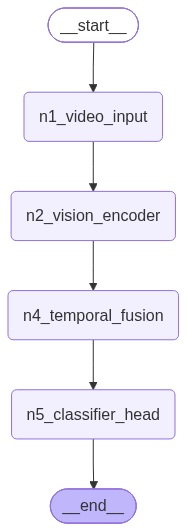

In [29]:
show_graph(vision_graph)

## 6. The Conf. Check gate and the retry loop

The first place the graph makes a *decision*. Until now every edge was
unconditional: `n1_video_input` always went to `n2_vision_encoder`. A
**conditional edge** calls a function that returns the name of the next route.

```python
g.add_conditional_edges("n5_classifier_head", conf_gate, {
    "accept":    END,          # p >= threshold
    "retry":     "retry",      # p <  threshold, budget left
    "exhausted": "degrade",    # p <  threshold, budget spent
})
```

Two things about this that are easy to get wrong:

**A conditional function cannot write to state.** It receives the state and
returns a route name --- that is all. So the retry branch cannot simply point back
at `n1_video_input`, because *something* has to increment the counter that makes
the loop terminate. That is what the `retry` node is for. In Figure 1 the retry
loop is drawn as a single dashed edge; in code that edge needs a body, and the
body is also where the real system would request an alternate camera angle or
slide the sampling window.

**The counter is not optional.** LangGraph does have a `recursion_limit`
(25 by default) that will eventually stop a runaway graph, but it stops it by
raising `GraphRecursionError` --- an accident, not a decision. Our counter makes
exhaustion a *designed* outcome: the graph reports `status="low_confidence"`
instead of pretending it knows what shot it saw.

### Making N5 attempt-aware

`STUB_CONFIDENCE` becomes optionally a sequence, so a retry can genuinely recover
rather than looping on the same number forever. Element `i` is the confidence on
attempt `i`. Re-run the two cells below to redefine the knob and N5.

In [30]:
def conf_gate(state: CricketMindState) -> str:
    """Conf. Check --- the red diamond in Figure 1.

    Returns a ROUTE NAME only. It must not return a state update; LangGraph
    ignores anything a conditional function returns other than the route.
    """
    conf  = state.get("shot_confidence", 0.0)
    tries = state.get("retry_count", 0)

    if conf >= CONF_THRESHOLD:
        trace("GATE", f"p={conf:.2f} >= {CONF_THRESHOLD} -> accept")
        return "accept"

    if tries >= MAX_RETRIES:
        trace("GATE", f"p={conf:.2f} < {CONF_THRESHOLD}, budget spent ({tries}/{MAX_RETRIES}) -> exhausted")
        return "exhausted"

    trace("GATE", f"p={conf:.2f} < {CONF_THRESHOLD} -> retry {tries + 1}/{MAX_RETRIES}")
    return "retry"

In [31]:
def retry_prep(state: CricketMindState) -> dict:
    """The body of the red dashed edge back to N1.

    Real version: request an alternate camera angle, slide the 15-frame sampling
    window, or apply test-time augmentation. Here it only increments the counter
    -- which is the part that makes the loop terminate.
    """
    n = state.get("retry_count", 0) + 1
    trace("RETRY", f"re-sampling clip, attempt {n}")
    return {"retry_count": n}

In [32]:
def low_confidence_exit(state: CricketMindState) -> dict:
    """Graceful degradation once the retry budget is spent.

    Deliberately does NOT clear shot_label: downstream code should be able to
    see what the model guessed *and* that it was not trusted.
    """
    trace("DEGRD", f"giving up after {state.get('retry_count', 0)} retries")
    return {"status": "low_confidence"}

In [33]:
def build_gated_graph():
    """Step 3 graph: vision path + Conf. Check + bounded retry loop."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input", n1_video_input)
    g.add_node("n2_vision_encoder", n2_vision_encoder)
    g.add_node("n4_temporal_fusion", n4_temporal_fusion)
    g.add_node("n5_classifier_head", n5_classifier_head)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    g.add_edge(START, "n1_video_input")
    g.add_edge("n1_video_input", "n2_vision_encoder")
    g.add_edge("n2_vision_encoder", "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    # the red diamond
    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    END,
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("retry", "n1_video_input")          # the red dashed loop
    g.add_edge("degrade", END)

    return g.compile()

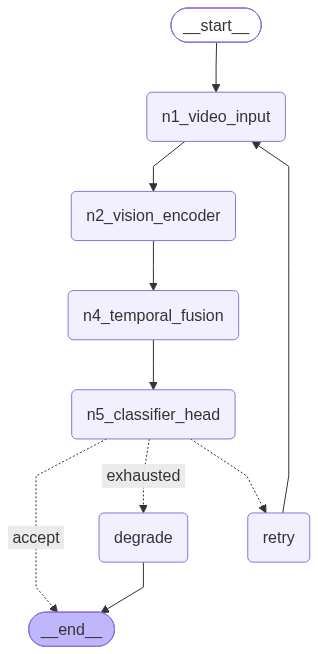

In [34]:
gated_graph = build_gated_graph()
show_graph(gated_graph)

In [35]:
def run_case(title: str, confidence, expect_status: str, expect_retries: int):
    """Run the gated graph with a scripted confidence and check the outcome."""
    global STUB_CONFIDENCE
    saved, STUB_CONFIDENCE = STUB_CONFIDENCE, confidence
    print(f"=== {title}  (STUB_CONFIDENCE={confidence}) " + "=" * max(0, 30 - len(title)))
    try:
        out = gated_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
    finally:
        STUB_CONFIDENCE = saved

    got_status  = out.get("status")
    got_retries = out.get("retry_count", 0)
    print(f"  -> status={got_status!r}  retry_count={got_retries}  p={out['shot_confidence']:.2f}")
    assert got_status  == expect_status,  f"expected status {expect_status!r}, got {got_status!r}"
    assert got_retries == expect_retries, f"expected {expect_retries} retries, got {got_retries}"
    print("  OK\n")
    return out

In [36]:
_ = run_case("A: confident first time", 0.92,
             expect_status="ok", expect_retries=0)

_ = run_case("B: recovers on third attempt", [0.41, 0.55, 0.88],
             expect_status="ok", expect_retries=2)

_ = run_case("C: never recovers, degrades", 0.30,
             expect_status="low_confidence", expect_retries=MAX_RETRIES)

print("PASS: gate accepts, retries with a bound, and degrades instead of looping forever")

=== A: confident first time  (STUB_CONFIDENCE=0.92) =======
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  -> status='ok'  retry_count=0  p=0.92
  OK

=== B: recovers on third attempt  (STUB_CONFIDENCE=[0.41, 0.55, 0.88]) ==
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.41
  [GATE ] p=0.41 < 0.7 -> retry 1/2
  [RETRY] re-sampling clip, attempt 1
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 1: Cover Drive (idx 0) p=0.55
  [GATE ] p=0.55 < 0.7 -> retry 2/2
  [RETRY] re-sampling clip, attempt 2
  [N1   ] sampled 15 frames from clips

## 7.The text branch and the Shot DNA join

Two new nodes, and the first time the graph does more than one thing at once.

**`n3_text_encoder` runs in parallel with the whole vision branch.** Both are
wired straight off `START`:

```python
g.add_edge(START, "n1_video_input")
g.add_edge(START, "n3_text_encoder")
```

That is the entire mechanism --- two edges out of the same node means both run.
LangGraph executes in *supersteps*: everything triggered at the same time runs
together, then their results are merged into state before the next superstep.

N3 does not wait for classification because its output parameterises **retrieval**,
not perception. Which shot the video contains has no bearing on the fact that the
query said "fast bowlers" and "powerplay".

### An edge is a trigger, not a data dependency

This is the trap in this step, and it cost a broken run to find.

Figure 1 draws an arrow from N3 into N6, so the obvious wiring is
`g.add_edge("n3_text_encoder", "n6_shot_dna")`. That is wrong, and it fails like
this:

```
[N1] sampled 15 frames
[N3] query -> (768,), filters={...}
[N2] encoded 15 frames
AssertionError: n6_shot_dna: vision branch delivered no shot_label
```

N6 ran while the vision branch was still at N2. Three experiments pinned down why:

| wiring | accept path | degrade path |
|---|---|---|
| static `n3 -> n6` edge | N6 fires early, crashes | crashes |
| two static parents (`n3` + an `accepted` node) | still fires early | still fires early |
| two static parents, `defer=True` | works | **N6 runs anyway** |
| accept route only | works | N6 correctly skipped |

The lesson: **in LangGraph an edge means "run this next", not "this node needs
that node's output".** A node fires as soon as *any* incoming edge is satisfied
--- there is no all-parents barrier. So a static edge from N3 guarantees N6 runs
right after N3, regardless of the vision branch.

The data dependency is real, but it travels through **state**, not through an
edge. N3 writes `query_embedding` and `query_filters`; N6 reads them from state
whenever it happens to run. The only edge N6 needs is the one that decides
*when* it should run --- the gate's `accept` route.

`defer=True` on N6 then says "run after everything else still pending", which
keeps the join correct if the text branch later grows into several nodes.

In [37]:
def n3_text_encoder(state: CricketMindState) -> dict:
    """Embed the query and pull out the retrieval filters it implies.

    Also extracts which shots the query *names*. The running example compares a
    cover drive with a pull, so retrieval must fetch both -- filtering on the
    shot the video happened to contain would silently drop half the comparison.

    Real version: a sentence embedding plus a structured parse (entity linking
    for the player, phase and bowler-type extraction). The keyword matching here
    is a stand-in that keeps the stub deterministic.
    """
    q = state.get("query")
    assert q, "n3_text_encoder: no query in state"

    ql = q.lower()
    filters = {}

    if "spin" in ql:
        filters["bowler_type"] = "spin"
    elif "pace" in ql or "fast" in ql:
        filters["bowler_type"] = "pace"

    if "powerplay" in ql:
        filters["phase"] = "powerplay"
    elif "death" in ql:
        filters["phase"] = "death"

    # The player named FIRST in the question is the one it is about:
    # "What if Rohit faced the attack instead of Kohli?" is about Rohit.
    # (Checking the names in a fixed order used to pick Kohli here.)
    named_players = [p for p in ("kohli", "rohit", "babar", "root", "smith") if p in ql]
    if named_players:
        first = min(named_players, key=ql.index)    # smallest position in the text
        filters["player"] = first.capitalize()

    # which shots does the QUERY mention, regardless of what the video showed
    named = [s for s in SHOT_CLASSES if s.lower() in ql]
    if named:
        filters["shots"] = named

    emb = FakeTensor((768,), "query embedding")
    trace("N3", f"query -> {emb.shape}, filters={filters}")
    return {"query_embedding": emb, "query_filters": filters}

In [38]:
# Deterministic stand-in for the continuous visual metrics the real N6 would
# read off the pose estimator. Keyed by shot so the numbers at least move in a
# plausible direction between strokes.
POSTURE_BY_SHOT = {
    "Cover Drive":  {"weight_transfer": 0.88, "bat_face_angle": -4.0, "stride_len": 0.72},
    "Pull":         {"weight_transfer": 0.61, "bat_face_angle": 11.5, "stride_len": 0.34},
    "Sweep":        {"weight_transfer": 0.70, "bat_face_angle":  6.0, "stride_len": 0.55},
}
DEFAULT_POSTURE = {"weight_transfer": 0.65, "bat_face_angle": 0.0, "stride_len": 0.50}

In [39]:
def n6_shot_dna(state: CricketMindState) -> dict:
    """Fuse whatever grounding is available into one structured record.

    This is the interface boundary of the whole system: everything downstream
    consumes shot_dna and never sees a pixel.

    Two ways in. On the **video** path the Conf. Check has accepted a
    classification, so `shot` and `posture` are populated. On the **text-only**
    path there was no clip at all, so both are None and the query's own filters
    carry the whole grounding. N3 must have run either way -- without a query
    there is nothing to ground.

    Posture is deliberately left as None rather than filled with a default when
    no clip was supplied. A default would be an invented measurement entering
    the sanctioned-fact surface, which is precisely the fabrication the Faith
    Check exists to prevent.
    """
    label = state.get("shot_label")
    emb   = state.get("query_embedding")
    assert emb is not None, "n6_shot_dna: n3_text_encoder has not run"

    from_video = label is not None

    dna = {
        "modality":   "video" if from_video else "text",
        "shot":       label,
        "confidence": state.get("shot_confidence") if from_video else None,
        "posture":    POSTURE_BY_SHOT.get(label, DEFAULT_POSTURE) if from_video else None,
        "filters":    state.get("query_filters", {}),
        "attempts":   state.get("retry_count", 0) + 1 if from_video else 0,
    }

    if from_video:
        trace("N6", f"shot_dna: {dna['shot']} p={dna['confidence']:.2f} "
                    f"filters={dna['filters']}")
    else:
        trace("N6", f"shot_dna: text-only, no clip -- filters={dna['filters']}")
    return {"shot_dna": dna}


In [40]:
def build_grounded_graph():
    """Step 4 graph: parallel text branch + gated vision branch, joining at N6.

    Note what is NOT here: an edge from n3_text_encoder to n6_shot_dna. N6 reads
    N3's output out of state. Giving it an edge would make N6 fire the moment N3
    finished, long before the vision branch produced a shot label. See the notes
    above -- an edge is a trigger, not a data dependency.
    """
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",     n1_video_input)
    g.add_node("n2_vision_encoder",  n2_vision_encoder)
    g.add_node("n4_temporal_fusion", n4_temporal_fusion)
    g.add_node("n5_classifier_head", n5_classifier_head)
    g.add_node("n3_text_encoder",    n3_text_encoder)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    # defer=True: run only once nothing else is pending, so the join stays
    # correct even if the text branch grows into several nodes later.
    g.add_node("n6_shot_dna", n6_shot_dna, defer=True)

    # two edges off START -- this is the whole of "run in parallel"
    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")

    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    # the gate is N6's ONLY trigger
    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("retry", "n1_video_input")
    g.add_edge("n6_shot_dna", END)
    g.add_edge("degrade", END)

    return g.compile()

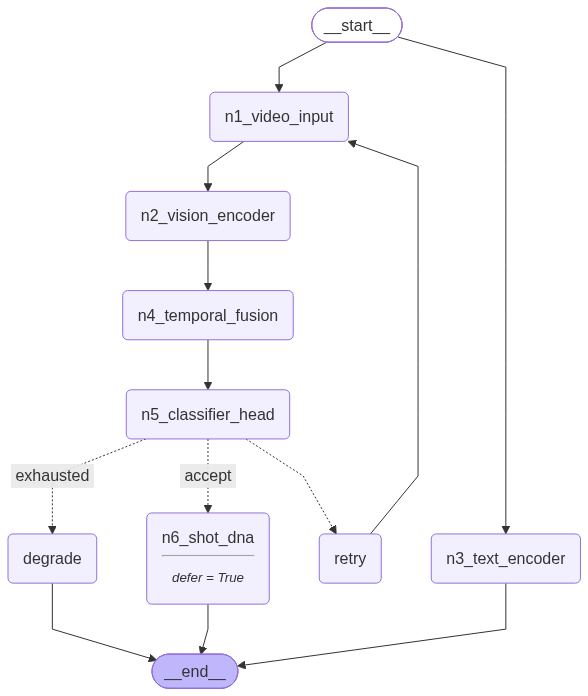

In [41]:
grounded_graph = build_grounded_graph()
show_graph(grounded_graph)

In [42]:
# --- A: accept path. Both branches run; N6 joins them. -----------------
STUB_CONFIDENCE = 0.92
out_a = grounded_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print("shot_dna:", json.dumps(out_a.get("shot_dna"), indent=2))

assert out_a["shot_dna"]["shot"] == "Cover Drive"

# Check the filters we care about individually rather than comparing the whole
# dict: n3_text_encoder gains new filter keys as the system grows, and an
# exact-equality assertion turns every such addition into a false failure.
f = out_a["shot_dna"]["filters"]
assert f["bowler_type"] == "pace"
assert f["phase"]       == "powerplay"
assert f["player"]      == "Kohli"
print("OK: N6 saw both the vision result and the query filters")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}

shot_dna: {
  "modality": "video",
  "shot": "Cover Drive",
  "confidence": 0.92,
  "posture": {
    "weight_transfer": 0.88,
    "bat_face_angle": -4.0,
    "stride_len": 0.72
  },
  "filters": {
    "bowler_type": "pace",
    "phase": "powerplay",
    "player": "Kohli",
    "shots": [
      "Cover Drive",
      "Pull"
    ]
  },
  "attempts": 1
}
OK: N6 saw both the vision result and the query filters


In [43]:
# --- B: retry path. N3 runs once; N6 still joins correctly. ------------
STUB_CONFIDENCE = [0.41, 0.88]
out_b = grounded_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print("retry_count:", out_b["retry_count"], "| attempts recorded in dna:", out_b["shot_dna"]["attempts"])
assert out_b["retry_count"] == 1
assert out_b["shot_dna"]["confidence"] == 0.88
print("OK: the loop did not disturb the join")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.41
  [GATE ] p=0.41 < 0.7 -> retry 1/2
  [RETRY] re-sampling clip, attempt 1
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 1: Cover Drive (idx 0) p=0.88
  [GATE ] p=0.88 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.88 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}

retry_count: 1 | attempts recorded in dna: 2
OK: the loop did not disturb the join


In [44]:
# --- C: degrade path. Does N6 run with only one of its two inputs? -----
STUB_CONFIDENCE = 0.30
out_c = grounded_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print("status  :", out_c.get("status"))
print("shot_dna:", out_c.get("shot_dna"))
assert out_c["status"] == "low_confidence"
assert "query_embedding" in out_c, "N3 should still have run -- it is independent of the gate"
assert out_c.get("shot_dna") is None, "N6 must NOT run when the gate refused to accept"
print("OK: N6 was skipped, not run half-fed and not deadlocked")

STUB_CONFIDENCE = 0.92   # leave the knob in its default state

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.30
  [GATE ] p=0.30 < 0.7 -> retry 1/2
  [RETRY] re-sampling clip, attempt 1
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 1: Cover Drive (idx 0) p=0.30
  [GATE ] p=0.30 < 0.7 -> retry 2/2
  [RETRY] re-sampling clip, attempt 2
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 2: Cover Drive (idx 0) p=0.30
  [GATE ] p=0.30 < 0.7, budget spent (2/2) -> exhausted
  [DEGRD] giving up after 2 retries

status  : low_confidence


## 8.The retrieval fan-out (N7a / N7b)

`n6_shot_dna` now fans out to two retrievers that run at the same time:

```python
g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
g.add_edge("n6_shot_dna", "n7b_context_retrieval")
```

* **N7a** is the narrow, high-precision query --- ball-by-ball deliveries matching
  the player, phase, bowler type and the shots the query named.
* **N7b** is the broad, high-recall envelope --- career and venue context that
  stops the report over-fitting its story to fifty deliveries.

This is the step the Step 1 reducers were written for. Two nodes finishing in the
same superstep both write to state, and how their writes combine is decided
entirely by the `Annotated[...]` on the field.

### The fake corpus is aggregated, not invented

The stub Cricsheet corpus is built from explicit aggregates --- 50 balls of cover
drive for 71 runs, 50 balls of pull for 56 --- expanded into ball-level rows. The
strike rates the Stats Engine will compute in Step 6 therefore *fall out of the
data* (71/50 = 142, 56/50 = 112) rather than being hardcoded to match the thesis
example. That distinction matters: N8 has to do real arithmetic on real rows, or
the Faith Check in Step 9 would be validating against a constant.

In [45]:
def _expand(shot, balls, runs, outs, phase, bowler_type, player):
    """Expand an aggregate into deterministic ball-level rows summing to `runs`.

    A repeating scoring pattern is adjusted until the total matches exactly, so
    the corpus is reproducible and the strike rates are arithmetic rather than
    assertion.
    """
    pattern = [1, 0, 4, 1, 2, 0, 1, 1, 0, 2]
    seq = [pattern[i % len(pattern)] for i in range(balls)]

    diff, i = runs - sum(seq), 0
    while diff and i < balls * 8:
        j = i % balls
        if diff > 0 and seq[j] < 6:
            seq[j] += 1; diff -= 1
        elif diff < 0 and seq[j] > 0:
            seq[j] -= 1; diff += 1
        i += 1
    assert sum(seq) == runs, f"_expand: could not hit {runs} in {balls} balls"

    return [
        {"player": player, "shot": shot, "runs": r, "out": k < outs,
         "phase": phase, "bowler_type": bowler_type}
        for k, r in enumerate(seq)
    ]

In [46]:
# Stand-in for the Cricsheet FAISS index. The last two blocks are deliberate
# noise -- if N7a's filtering is wrong they will leak into the results and the
# strike rates will come out wrong.
FAKE_CRICSHEET = (
    _expand("Cover Drive", balls=50, runs=71, outs=1,
            phase="powerplay", bowler_type="pace",  player="Kohli")   # SR 142
    + _expand("Pull",      balls=50, runs=56, outs=4,
            phase="powerplay", bowler_type="pace",  player="Kohli")   # SR 112
    + _expand("Cover Drive", balls=30, runs=33, outs=1,
            phase="powerplay", bowler_type="spin",  player="Kohli")   # noise
    + _expand("Pull",      balls=20, runs=34, outs=1,
            phase="death",     bowler_type="pace",  player="Kohli")   # noise
)

print(f"fake Cricsheet corpus: {len(FAKE_CRICSHEET)} deliveries")

fake Cricsheet corpus: 150 deliveries


In [47]:
# Stand-in for the broader Kaggle historical index: aggregate context rather
# than individual deliveries.
FAKE_CONTEXT = [
    {"metric": "career_sr_vs_pace",         "player": "Kohli", "value": 138.0},
    {"metric": "venue_sr",                  "player": "Kohli", "value": 151.2,
     "venue": "M. Chinnaswamy Stadium"},
    {"metric": "powerplay_dismissal_rate",  "player": "Kohli", "value": 0.08},
    {"metric": "career_sr_vs_spin",         "player": "Kohli", "value": 121.4},
]

In [48]:
def n7a_stats_retrieval(state: CricketMindState) -> dict:
    """N7a --- narrow, high-precision retrieval from the ball-by-ball index.

    Filters on player, phase and bowler type from the query, and on the union of
    the shot the video showed and any shots the query named. On a text-only
    query the video contributes nothing, so the query must name at least one
    shot itself -- otherwise there is no retrieval key at all.
    """
    dna = state.get("shot_dna")
    assert dna is not None, "n7a_stats_retrieval: n6_shot_dna has not run"
    f = dna["filters"]

    wanted = set(f.get("shots", []))
    if dna.get("shot"):
        wanted.add(dna["shot"])
    assert wanted, ("n7a_stats_retrieval: nothing to retrieve -- a text-only query "
                    "must name at least one shot")

    hits = [
        r for r in FAKE_CRICSHEET
        if r["shot"] in wanted
        and (("player"      not in f) or r["player"]      == f["player"])
        and (("phase"       not in f) or r["phase"]       == f["phase"])
        and (("bowler_type" not in f) or r["bowler_type"] == f["bowler_type"])
    ]

    trace("N7a", f"shots={sorted(wanted)} -> {len(hits)} deliveries "
                 f"(from {len(FAKE_CRICSHEET)})")
    return {"stats_hits": hits}


In [49]:
def n7b_context_retrieval(state: CricketMindState) -> dict:
    """N7b --- broad, high-recall retrieval of historical context.

    Deliberately does NOT filter by shot. Its job is the surrounding envelope:
    career form, venue behaviour, comparable conditions.
    """
    dna = state.get("shot_dna")
    assert dna is not None, "n7b_context_retrieval: n6_shot_dna has not run"
    player = dna["filters"].get("player")

    hits = [r for r in FAKE_CONTEXT if player is None or r["player"] == player]
    trace("N7b", f"player={player} -> {len(hits)} context rows")
    return {"context_hits": hits}

In [50]:
def build_retrieval_graph():
    """Step 5 graph: everything from Step 4, plus the parallel retrieval fan-out."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",       n1_video_input)
    g.add_node("n2_vision_encoder",    n2_vision_encoder)
    g.add_node("n4_temporal_fusion",   n4_temporal_fusion)
    g.add_node("n5_classifier_head",   n5_classifier_head)
    g.add_node("n3_text_encoder",      n3_text_encoder)
    g.add_node("n6_shot_dna",          n6_shot_dna, defer=True)
    g.add_node("n7a_stats_retrieval",  n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")

    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    # the fan-out: two edges out of one node means both run in parallel
    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")

    g.add_edge("retry", "n1_video_input")
    g.add_edge("n7a_stats_retrieval",  END)
    g.add_edge("n7b_context_retrieval", END)
    g.add_edge("degrade", END)

    return g.compile()

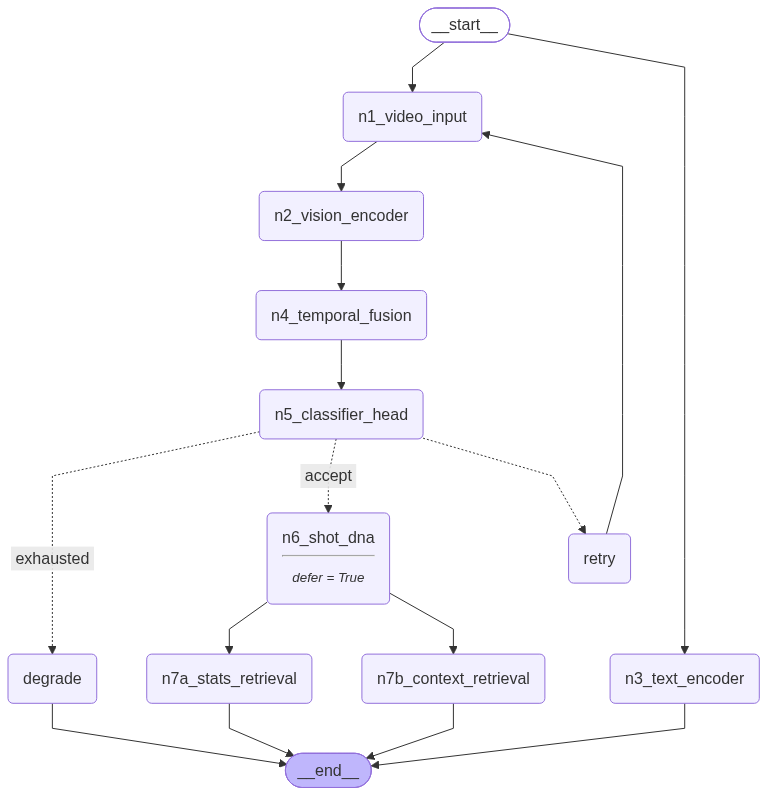

In [51]:
retrieval_graph = build_retrieval_graph()
show_graph(retrieval_graph)

In [52]:
# A: both retrievers land, neither overwrites the other
STUB_CONFIDENCE = 0.92
out = retrieval_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print("stats_hits  :", len(out["stats_hits"]), "deliveries")
print("context_hits:", len(out["context_hits"]), "rows")
assert len(out["stats_hits"])   == 100, "N7a lost rows"
assert len(out["context_hits"]) == 4,   "N7b lost rows"
print("OK: parallel writes merged, nothing dropped")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows

stats_hits  : 100 deliveries
context_hits: 4 rows
OK: parallel writes merged, nothing dropped


In [53]:
# B: filtering actually filters, and the arithmetic is real
from collections import defaultdict

agg = defaultdict(lambda: {"balls": 0, "runs": 0, "outs": 0})
for r in out["stats_hits"]:
    a = agg[r["shot"]]
    a["balls"] += 1
    a["runs"]  += r["runs"]
    a["outs"]  += int(r["out"])

for shot, a in sorted(agg.items()):
    sr = 100.0 * a["runs"] / a["balls"]
    print(f"  {shot:12s} {a['balls']:3d} balls  {a['runs']:3d} runs  SR {sr:6.1f}  outs {a['outs']}")

assert set(agg) == {"Cover Drive", "Pull"}, "wrong shots retrieved"
assert all(r["bowler_type"] == "pace"      for r in out["stats_hits"]), "spin noise leaked in"
assert all(r["phase"]       == "powerplay" for r in out["stats_hits"]), "death-overs noise leaked in"
assert round(100.0 * agg["Cover Drive"]["runs"] / agg["Cover Drive"]["balls"], 1) == 142.0
assert round(100.0 * agg["Pull"]["runs"]        / agg["Pull"]["balls"],        1) == 112.0
print("OK: SR 142 vs 112 computed from the rows, not hardcoded")

  Cover Drive   50 balls   71 runs  SR  142.0  outs 1
  Pull          50 balls   56 runs  SR  112.0  outs 4
OK: SR 142 vs 112 computed from the rows, not hardcoded


In [54]:
def _make_writer(tag: str):
    """Build a throwaway node that writes a fixed value to `report`.

    A factory rather than two near-identical functions: the point of the
    demonstration is that TWO nodes write THE SAME key in one superstep, and
    the tag is the only thing that differs between them.
    """
    def _writer(state: CricketMindState) -> dict:
        return {"report": f"from {tag}"}
    return _writer

In [55]:
# --- C: why the reducers are needed at all ------------------------------
# `report` is a plain str field with no reducer. Two nodes writing it in the
# same superstep is exactly what an un-annotated parallel write looks like.
_g = StateGraph(CricketMindState)
_g.add_node("a", _make_writer("A"))
_g.add_node("b", _make_writer("B"))
_g.add_edge(START, "a"); _g.add_edge(START, "b")
_g.add_edge("a", END);   _g.add_edge("b", END)

try:
    _g.compile().invoke(new_state("c.mp4", "q"))
    print("no error -- this field must have a reducer after all")
except Exception as e:
    print(f"{type(e).__name__}: {str(e).splitlines()[0]}")
    print()
    print("That is what stats_hits and context_hits would do without")
    print("Annotated[list, operator.add]. The reducer is not decoration.")

InvalidUpdateError: At key 'report': Can receive only one value per step. Use an Annotated key to handle multiple values.

That is what stats_hits and context_hits would do without
Annotated[list, operator.add]. The reducer is not decoration.


## 9.The two shared analytical services (N8 / N9)

These are the nodes that make the Faith Check in Step 9 mean anything.

Neither is an LLM node, even in the finished system. **N8 is arithmetic** over the
rows N7a retrieved; **N9 is sampling** from the distribution those rows describe.
Between them they hold exclusive authority to emit a number, and every one of the
twelve stakeholder agents in Step 8 consumes their output rather than doing sums
inside its own prompt.

That is the central claim of Architecture v2: numeric truth is produced **once**,
by two auditable engines, and then narrated twelve different ways.

### Why they are independent of each other

Both read `stats_hits` and neither reads the other's output. That is deliberate.
N8 and N9 run in the same phase, so if N9 depended on `stats_results` the ordering
between them would be undefined --- the Step 4 lesson again. Instead each derives
what it needs from the same evidence:

| | reads | produces | kind of claim |
|---|---|---|---|
| **N8** | `stats_hits` | strike rates, dismissal rates | observational |
| **N9** | `stats_hits` | counterfactual probabilities | forward-looking |

Both are marked `defer=True`, so they run only once both retrievers have
finished --- otherwise N9, triggered by N7b, could start before N7a had put
`stats_hits` into state at all.

### The 40% is not a coincidence

The thesis example says a batsman facing six back-of-a-length deliveries has
roughly a 40% chance of being dismissed attempting the pull. The corpus gives the
pull 4 dismissals in 50 balls, so `p = 0.08` per ball, and

```
1 - (1 - 0.08)^6  =  0.394
```

N9 arrives at that by Monte Carlo rather than by formula, and the test asserts the
simulation lands within tolerance of the closed form. The number is *derived from
the evidence*, which is precisely what will let the Faith Check reject an agent
that invents a different one.

In [56]:
# N9 simulation settings. Seeded so the notebook is reproducible; the real
# system would report the same interval from any seed given enough trials.
SIM_TRIALS     = 20_000     # Monte Carlo runs
SIM_DELIVERIES = 6          # "what if the bowler sends down six of these?"

print(f"N9: {SIM_TRIALS:,} trials x {SIM_DELIVERIES} deliveries")

N9: 20,000 trials x 6 deliveries


In [57]:
def n8_stats_engine(state: CricketMindState) -> dict:
    """N8 --- Statistical Analysis Engine.

    Deterministic aggregation over the deliveries N7a retrieved. No sampling, no
    generation: every number it emits is a count or a ratio that can be
    recomputed by hand from `stats_hits`. That reproducibility is what makes the
    Faith Check downstream meaningful.
    """
    hits = state.get("stats_hits") or []
    assert hits, "n8_stats_engine: no stats_hits -- did n7a_stats_retrieval run?"

    by_shot = {}
    for r in hits:
        a = by_shot.setdefault(r["shot"], {"balls": 0, "runs": 0, "dismissals": 0})
        a["balls"]      += 1
        a["runs"]       += r["runs"]
        a["dismissals"] += int(r["out"])

    for a in by_shot.values():
        a["strike_rate"]    = round(100.0 * a["runs"] / a["balls"], 1)
        a["dismissal_rate"] = round(a["dismissals"] / a["balls"], 4)

    ranked = sorted(by_shot.items(), key=lambda kv: kv[1]["strike_rate"], reverse=True)
    results = {
        "by_shot":     by_shot,
        "best_shot":   ranked[0][0],
        "worst_shot":  ranked[-1][0],
        "sample_size": len(hits),
    }

    trace("N8", "  ".join(f"{s}: SR {a['strike_rate']}" for s, a in ranked))
    return {"stats_results": results}

In [58]:
def n9_whatif_simulator(state: CricketMindState) -> dict:
    """N9 --- What-If Simulator (Monte Carlo).

    The only source of forward-looking, non-observational claims in the system.
    Answers questions no historical record can answer directly by sampling from
    the distribution the retrieved deliveries describe, and always reports an
    interval alongside the point estimate.
    """
    hits = state.get("stats_hits") or []
    assert hits, "n9_whatif_simulator: no stats_hits -- did n7a_stats_retrieval run?"

    # per-ball dismissal risk by shot, from the same rows N8 reads
    tally = {}
    for r in hits:
        t = tally.setdefault(r["shot"], {"balls": 0, "outs": 0})
        t["balls"] += 1
        t["outs"]  += int(r["out"])

    vulnerable = max(tally, key=lambda s: tally[s]["outs"] / tally[s]["balls"])
    p_ball = tally[vulnerable]["outs"] / tally[vulnerable]["balls"]

    rng = random.Random(SEED)
    dismissed = 0
    for _ in range(SIM_TRIALS):
        for _ in range(SIM_DELIVERIES):
            if rng.random() < p_ball:
                dismissed += 1
                break

    p  = dismissed / SIM_TRIALS
    se = (p * (1 - p) / SIM_TRIALS) ** 0.5

    results = {
        "scenario":       f"{SIM_DELIVERIES} consecutive deliveries targeting the {vulnerable.lower()}",
        "target_shot":    vulnerable,
        "p_ball":         round(p_ball, 4),
        "p_dismissal":    round(p, 4),
        "ci95":           [round(p - 1.96 * se, 4), round(p + 1.96 * se, 4)],
        "analytic_check": round(1 - (1 - p_ball) ** SIM_DELIVERIES, 4),
        "trials":         SIM_TRIALS,
    }

    trace("N9", f"{vulnerable}: p_ball={p_ball:.3f} -> P(out in {SIM_DELIVERIES}) "
                f"= {p:.3f} +/- {1.96 * se:.3f}")
    return {"sim_results": results}

In [59]:
def build_analytics_graph():
    """Step 6 graph: retrieval fan-out feeding the two analytical services."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",        n1_video_input)
    g.add_node("n2_vision_encoder",     n2_vision_encoder)
    g.add_node("n4_temporal_fusion",    n4_temporal_fusion)
    g.add_node("n5_classifier_head",    n5_classifier_head)
    g.add_node("n3_text_encoder",       n3_text_encoder)
    g.add_node("n6_shot_dna",           n6_shot_dna, defer=True)
    g.add_node("n7a_stats_retrieval",   n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    # defer=True: both retrievers must have finished before either engine runs.
    # N9 is triggered by N7b but reads stats_hits, which N7a writes.
    g.add_node("n8_stats_engine",     n8_stats_engine,     defer=True)
    g.add_node("n9_whatif_simulator", n9_whatif_simulator, defer=True)

    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")

    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")

    g.add_edge("n7a_stats_retrieval",   "n8_stats_engine")
    g.add_edge("n7b_context_retrieval", "n9_whatif_simulator")

    g.add_edge("retry", "n1_video_input")
    g.add_edge("n8_stats_engine",     END)
    g.add_edge("n9_whatif_simulator", END)
    g.add_edge("degrade", END)

    return g.compile()

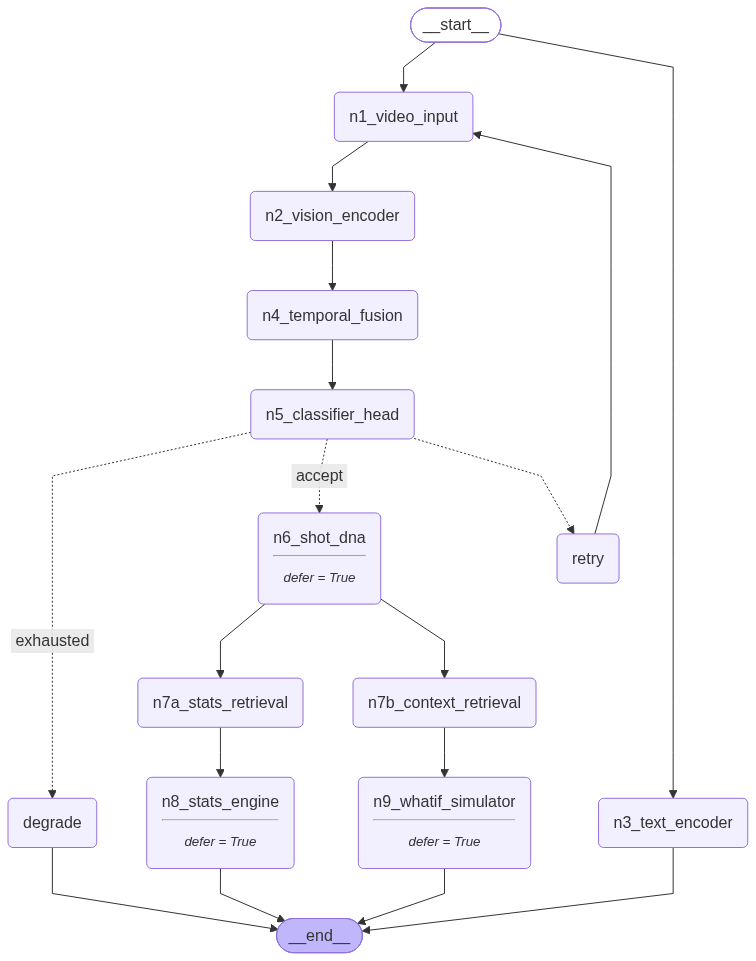

In [60]:
analytics_graph = build_analytics_graph()
show_graph(analytics_graph)

In [61]:
# A: N8 aggregates, and both engines got their evidence
STUB_CONFIDENCE = 0.92
out6 = analytics_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print(json.dumps(out6["stats_results"], indent=2))

sr = out6["stats_results"]["by_shot"]
assert sr["Cover Drive"]["strike_rate"] == 142.0
assert sr["Pull"]["strike_rate"]        == 112.0
assert out6["stats_results"]["best_shot"]  == "Cover Drive"
assert out6["stats_results"]["worst_shot"] == "Pull"
assert out6["stats_results"]["sample_size"] == 100
print("OK: N8 reproduced SR 142 vs 112 by counting rows")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007

{
  "by_shot": {
    "Cover Drive": {
      "balls": 50,
      "runs": 71,
      "dismissals": 1,
      "strike_rate": 142.0,
      "dismissal_rate": 0.02
    },
    "Pull": {
      "balls": 50,
      "runs": 56,
      "dismissals": 4,
      "strike_rate": 112.0,
 

In [62]:
# B: N9's simulation agrees with the closed form
sim = out6["sim_results"]
print(json.dumps(sim, indent=2))

lo, hi = sim["ci95"]
assert sim["target_shot"] == "Pull", "N9 picked the wrong vulnerable shot"
assert abs(sim["p_dismissal"] - sim["analytic_check"]) < 0.02, "Monte Carlo drifted"
assert lo <= sim["analytic_check"] <= hi, "closed form outside the 95% interval"
print()
print(f"OK: simulated {sim['p_dismissal']:.1%} vs analytic {sim['analytic_check']:.1%}"
      f"  (thesis quotes ~40%)")

{
  "scenario": "6 consecutive deliveries targeting the pull",
  "target_shot": "Pull",
  "p_ball": 0.08,
  "p_dismissal": 0.3941,
  "ci95": [
    0.3873,
    0.4009
  ],
  "analytic_check": 0.3936,
  "trials": 20000
}

OK: simulated 39.4% vs analytic 39.4%  (thesis quotes ~40%)


In [63]:
# --- C: the engines are the only source of numbers ----------------------
# Every figure any agent is allowed to quote in Step 8 must appear here.
sanctioned = {
    "strike rates":     {s: a["strike_rate"]    for s, a in out6["stats_results"]["by_shot"].items()},
    "dismissal rates":  {s: a["dismissal_rate"] for s, a in out6["stats_results"]["by_shot"].items()},
    "sample size":      out6["stats_results"]["sample_size"],
    "P(dismissal)":     out6["sim_results"]["p_dismissal"],
    "95% interval":     out6["sim_results"]["ci95"],
}
for k, v in sanctioned.items():
    print(f"  {k:16s} {v}")

assert out6["stats_results"] and out6["sim_results"], "an engine did not run"
print()
print("These are the values the Faith Check will validate agent claims against.")

  strike rates     {'Cover Drive': 142.0, 'Pull': 112.0}
  dismissal rates  {'Cover Drive': 0.02, 'Pull': 0.08}
  sample size      100
  P(dismissal)     0.3941
  95% interval     [0.3873, 0.4009]

These are the values the Faith Check will validate agent claims against.


## 10.The Supervisor Router (N10)

N10 decides **which of the twelve stakeholder agents to wake**. It does not run
them --- that is Step 8 --- it only writes `active_agents` into state.

Routing is the mechanism that makes a fourteen-agent system legible. Waking all
twelve on every query would be both wasteful and actively harmful: a coach asking
about a match-up would get a sponsorship ROI paragraph and a stadium floodlight
schedule buried in the same report. Your architecture doc puts it as "dispatching
all twelve would bury the answer in irrelevant perspectives", and `MAX_ACTIVE_AGENTS`
is where that becomes enforceable rather than aspirational.

### What the router reads

Three sources, in order of authority:

1. **The query** --- keyword evidence for which stakeholder is actually asking.
2. **The Shot DNA** --- what the video showed, which can wake an agent the words
   did not (a low-confidence classification is a technique question whether or not
   the user said "technique").
3. **The analytics** --- a large gap between the best and worst shot is tactical
   signal, regardless of phrasing.

Keyword matching is a stand-in for a real LLM router. What matters for the graph
is that the *interface* is settled: N10 reads state and writes a list of agent
ids. Replacing the body with an LLM call later changes nothing else.

### Why N10 is deferred

N10 has two incoming edges, one from each engine. As established in Step 4,
LangGraph has no all-parents barrier --- without `defer=True` the router would
fire as soon as whichever engine finished first, and would route on half the
evidence.

In [64]:
# A report that speaks in more than four voices stops being a report. The cap is
# the difference between "dynamic dispatch" and "wake everyone and hope".
MAX_ACTIVE_AGENTS = 4

# Woken when nothing else scores -- the general-purpose pair that can say
# something useful about any delivery.
DEFAULT_AGENTS = ["n11b_tactical_analysis", "n11c_personal_performance"]

# Which router proposes the agents: "keyword" (the rule-based scorer) or "llm"
# (a local language model, Section 16). Everything before Section 16 uses
# "keyword", so none of those results depends on a language model.
ROUTER_MODE = "keyword"

In [65]:
# The twelve stakeholder agents of Architecture v2.
#
#   keywords  -- stand-in for a real semantic router (Step 7)
#   template  -- the agent's voice; formatted against the sanctioned facts
#   cites     -- which sanctioned numbers this agent is allowed to quote.
#                Step 9's Faith Check validates exactly these keys, so an agent
#                cannot smuggle in a figure N8 and N9 never produced.
AGENT_REGISTRY = [
    {"id": "n11a_club_operations", "stakeholder": "Franchises / Boards",
     "keywords": ("budget", "auction", "squad", "contract", "fixture", "travel", "roster"),
     "cites": ("best_sr", "sample_size"),
     "template": "Retention case for {player}: {best_shot} returns SR {best_sr} across "
                 "{sample_size} tracked deliveries in this phase, which supports the current "
                 "salary band at the next auction."},

    {"id": "n11b_tactical_analysis", "stakeholder": "Coaches",
     "keywords": ("tactic", "bowl", "field", "matchup", "match-up", "strategy",
                  "weakness", "opposition", "plan", "attack"),
     "cites": ("best_sr", "worst_sr", "p_pct"),
     "template": "Bowl short at {player}. The {worst_shot} returns SR {worst_sr} against "
                 "the {best_shot}'s SR {best_sr}; {deliveries} consecutive back-of-a-length "
                 "deliveries carry a {p_pct}% chance of dismissal."},

    {"id": "n11c_personal_performance", "stakeholder": "Players",
     "keywords": ("technique", "shot", "form", "drive", "pull", "sweep", "cut",
                  "trend", "milestone", "selection"),
     "cites": ("best_sr", "worst_sr", "weight_transfer"),
     "template": "Weight transfer on the {best_shot} measures {weight_transfer}, and it is "
                 "the stronger stroke at SR {best_sr}. The {worst_shot} lags at SR {worst_sr} "
                 "-- shot selection, not technique, is the gap to close."},

    {"id": "n11d_global_scouting", "stakeholder": "Scouts",
     "keywords": ("scout", "emerging", "league", "prospect", "talent pool", "recruit"),
     "cites": ("best_sr", "career_sr"),
     "template": "Benchmark for comparable recruits: SR {best_sr} on the {best_shot} against "
                 "a career SR of {career_sr} versus pace sets the bar for this role."},

    {"id": "n11e_fan_concierge", "stakeholder": "Fans",
     "keywords": ("fan", "fantasy", "ticket", "merchandise", "stadium guide", "highlight"),
     "cites": ("best_sr", "venue_sr"),
     "template": "Fantasy note: {player} strikes at {venue_sr} at this venue and {best_sr} "
                 "on the {best_shot} -- a strong captaincy pick while the field is up."},

    {"id": "n11f_stadium_operations", "stakeholder": "Stadiums",
     "keywords": ("pitch prep", "curator", "crowd", "concession", "floodlight", "drs"),
     "cites": ("sample_size",),
     "template": "Curation note: {sample_size} tracked deliveries in this phase suggest "
                 "the surface is holding pace; no change to the rolling schedule."},

    {"id": "n11g_sponsorship_intelligence", "stakeholder": "Sponsors",
     "keywords": ("sponsor", "brand", "logo", "roi", "impression", "visibility"),
     "cites": ("best_sr",),
     "template": "Visibility: boundary strokes drive replay volume, and the {best_shot} at "
                 "SR {best_sr} is this batsman's most replayed shot -- prime logo exposure."},

    {"id": "n11h_content_production", "stakeholder": "Broadcasters",
     "keywords": ("commentary", "broadcast", "overlay", "wagon wheel", "clip",
                  "highlight", "graphic"),
     "cites": ("best_sr", "worst_sr"),
     "template": "Ticker line: \"{player} -- {best_shot} SR {best_sr}, {worst_shot} SR "
                 "{worst_sr} in the powerplay.\" Wagon wheel overlay ready."},

    {"id": "n11i_compliance", "stakeholder": "Governing Bodies",
     "keywords": ("eligibility", "compliance", "icc", "audit", "bio-bubble", "sanction"),
     "cites": ("sample_size",),
     "template": "No eligibility or conduct flags attached to the {sample_size} deliveries "
                 "reviewed. Match officials' records are consistent."},

    {"id": "n11j_talent_development", "stakeholder": "Academies",
     "keywords": ("academy", "u-16", "u-19", "drill", "coaching plan", "development"),
     "cites": ("worst_sr", "weight_transfer"),
     "template": "Drill focus for age-group squads: replicate the {weight_transfer} weight "
                 "transfer of the {best_shot}; the {worst_shot} at SR {worst_sr} is the "
                 "stroke to rebuild first."},

    {"id": "n11k_injury_management", "stakeholder": "Medical Teams",
     "keywords": ("injury", "workload", "fatigue", "fitness", "recovery",
                  "hamstring", "return-to-play"),
     "cites": ("sample_size",),
     "template": "Workload: {sample_size} deliveries faced in this phase sits inside the "
                 "weekly threshold. No soft-tissue risk flag raised."},

    {"id": "n11l_player_representation", "stakeholder": "Player Agents / Managers",
     "keywords": ("valuation", "market", "agent", "transfer", "salary", "worth"),
     "cites": ("best_sr", "career_sr"),
     "template": "Valuation input: SR {best_sr} on the {best_shot} against a career SR of "
                 "{career_sr} versus pace supports a top-bracket ask this cycle."},
]

AGENTS_BY_ID = {a["id"]: a for a in AGENT_REGISTRY}
print(f"{len(AGENT_REGISTRY)} stakeholder agents registered")

12 stakeholder agents registered


In [66]:
def _score_agents(state: CricketMindState) -> dict:
    """Score every agent against the query, the Shot DNA and the analytics.

    Returns {agent_id: (score, [reasons])}. Split out from the router so the
    selection logic can be inspected on its own -- this is the part that will be
    replaced by an LLM call, and it is easier to compare against a rubric when it
    is not tangled up with graph plumbing.
    """
    q      = (state.get("query") or "").lower()
    dna    = state.get("shot_dna") or {}
    stats  = (state.get("stats_results") or {}).get("by_shot", {})
    scores = {}

    # 1. keyword evidence from the query
    for a in AGENT_REGISTRY:
        hits = [k for k in a["keywords"] if k in q]
        if hits:
            scores[a["id"]] = [len(hits), [f"query mentions {', '.join(hits)}"]]

    # 2. structural signal: a shaky classification is a technique question.
    #    A text-only query has no visual confidence at all, so the signal does
    #    not apply. Note dna.get("confidence", 1.0) would return None here, not
    #    the default -- the key exists, its value is None.
    conf = dna.get("confidence")
    if conf is not None and conf < 0.80:
        e = scores.setdefault("n11c_personal_performance", [0, []])
        e[0] += 1
        e[1].append(f"low visual confidence ({conf:.2f})")

    # 3. structural signal: a wide spread between shots is tactical
    if len(stats) >= 2:
        rates = [a["strike_rate"] for a in stats.values()]
        if max(rates) - min(rates) >= 20:
            e = scores.setdefault("n11b_tactical_analysis", [0, []])
            e[0] += 1
            e[1].append(f"SR spread {max(rates) - min(rates):.0f} between shots")

    return {k: (v[0], v[1]) for k, v in scores.items()}

### Agents whose evidence does not exist

The sanctioned-fact surface is not fixed. A text-only query carries no clip, so
no posture was measured and `weight_transfer` is absent from
`sanctioned_facts`. Two agents --- Players and Academies --- are required to
cite it.

They must therefore **not be woken**. Filling the gap with a default posture
would put an invented measurement into the sanctioned facts, where the Faith
Check would then verify it as truth. Declining to wake the agent is the honest
option: the report is shorter, and everything left in it is still grounded.

This is the same trade Result 2 measures --- containment is paid for in
completeness.

In [67]:
def agents_missing_facts(state: CricketMindState) -> set:
    """Agent ids whose required citations this query cannot supply.

    Kept separate from the scoring so the reason an agent stayed asleep is
    "its evidence does not exist", not "it scored low".
    """
    dna = state.get("shot_dna") or {}
    if dna.get("posture"):
        return set()
    return {a["id"] for a in AGENT_REGISTRY if "weight_transfer" in a["cites"]}


In [68]:
def propose_agents(state: CricketMindState) -> dict:
    """Stage 1 of N10: who SHOULD answer, before any rule is applied.

    ROUTER_MODE "keyword": the keyword scorer (_score_agents), best score
    first, ties broken by registry order so runs are reproducible.
    ROUTER_MODE "llm": the local language model (llm_route, Section 16). If it
    cannot be reached or replies badly, the keyword scorer is used instead and
    the run records that it happened.

    Returns {"router": who proposed, "ranked": agent ids, best first,
             "reason": the LLM's reason (or None),
             "scored": the keyword evidence (or None),
             "seconds": how long the LLM took (or None)}.
    """
    assert ROUTER_MODE in ("keyword", "llm"), f"unknown ROUTER_MODE {ROUTER_MODE!r}"

    router = "keyword"
    if ROUTER_MODE == "llm":
        try:
            answer = llm_route(state.get("query") or "")
            return {"router": "llm", "ranked": answer["agents"],
                    "reason": answer["reason"], "scored": None,
                    "seconds": answer["seconds"]}
        except (OSError, ValueError, KeyError) as e:     # unreachable, or a bad reply
            trace("N10", f"LLM router failed ({type(e).__name__}) -> keyword router")
            router = "keyword (LLM unavailable)"

    scored = _score_agents(state)
    order  = {a["id"]: i for i, a in enumerate(AGENT_REGISTRY)}
    ranked = sorted(scored, key=lambda aid: (-scored[aid][0], order[aid]))
    return {"router": router, "ranked": ranked, "reason": None, "scored": scored,
            "seconds": None}

In [69]:
def n10_supervisor_router(state: CricketMindState) -> dict:
    """N10 --- Supervisor Router. Chooses which agents run; does not run them.

    Two stages, kept apart on purpose:
      1. propose_agents -- who SHOULD answer, best first. The keyword scorer
         or the language model, depending on ROUTER_MODE.
      2. the rules, applied here and identical for both routers: agents whose
         evidence does not exist are removed, at most MAX_ACTIVE_AGENTS are
         kept, and if nobody is left the default pair answers.
    Because the rules run after the proposal, the guarantees -- the cap, the
    evidence rule, and the bounds that follow from them -- hold whichever
    router proposed. The language model proposes; the rules decide.

    Writes `active_agents`, plus `routing_info` recording who proposed what
    and what the rules removed.
    """
    proposal = propose_agents(state)
    blocked  = agents_missing_facts(state)

    skipped = [a for a in proposal["ranked"] if a in blocked]
    allowed = [a for a in proposal["ranked"] if a not in blocked]
    if skipped:
        trace("N10", f"no evidence for {len(skipped)}: "
                     + ", ".join(AGENTS_BY_ID[a]["stakeholder"] for a in skipped))

    if allowed:
        chosen = allowed[:MAX_ACTIVE_AGENTS]
        trace("N10", f"woke {len(chosen)}/{len(AGENT_REGISTRY)}: "
                     + ", ".join(AGENTS_BY_ID[c]["stakeholder"] for c in chosen))
        if proposal["scored"] is not None:          # keyword router: its evidence
            for aid in chosen:
                trace("  ->", f"{aid}: {'; '.join(proposal['scored'][aid][1])}")
        else:                                        # LLM router: its reason
            trace("  ->", f"LLM: {proposal['reason']}")
    else:
        chosen = [a for a in DEFAULT_AGENTS if a not in blocked]
        trace("N10", f"no signal -> default {[AGENTS_BY_ID[c]['stakeholder'] for c in chosen]}")

    return {"active_agents": chosen,
            "routing_info": {"router":    proposal["router"],
                             "proposed":  proposal["ranked"],
                             "blocked":   skipped,
                             "reason":    proposal["reason"],
                             "defaulted": not allowed,
                             "seconds":   proposal["seconds"]}}


In [70]:
def build_router_graph():
    """Step 7 graph: everything so far, plus the supervisor router."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",        n1_video_input)
    g.add_node("n2_vision_encoder",     n2_vision_encoder)
    g.add_node("n4_temporal_fusion",    n4_temporal_fusion)
    g.add_node("n5_classifier_head",    n5_classifier_head)
    g.add_node("n3_text_encoder",       n3_text_encoder)
    g.add_node("n6_shot_dna",           n6_shot_dna,         defer=True)
    g.add_node("n7a_stats_retrieval",   n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("n8_stats_engine",       n8_stats_engine,     defer=True)
    g.add_node("n9_whatif_simulator",   n9_whatif_simulator, defer=True)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    # defer=True: two incoming edges, and LangGraph has no all-parents barrier
    g.add_node("n10_supervisor_router", n10_supervisor_router, defer=True)

    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")

    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")
    g.add_edge("n7a_stats_retrieval",   "n8_stats_engine")
    g.add_edge("n7b_context_retrieval", "n9_whatif_simulator")

    g.add_edge("n8_stats_engine",     "n10_supervisor_router")
    g.add_edge("n9_whatif_simulator", "n10_supervisor_router")

    g.add_edge("retry", "n1_video_input")
    g.add_edge("n10_supervisor_router", END)
    g.add_edge("degrade", END)

    return g.compile()

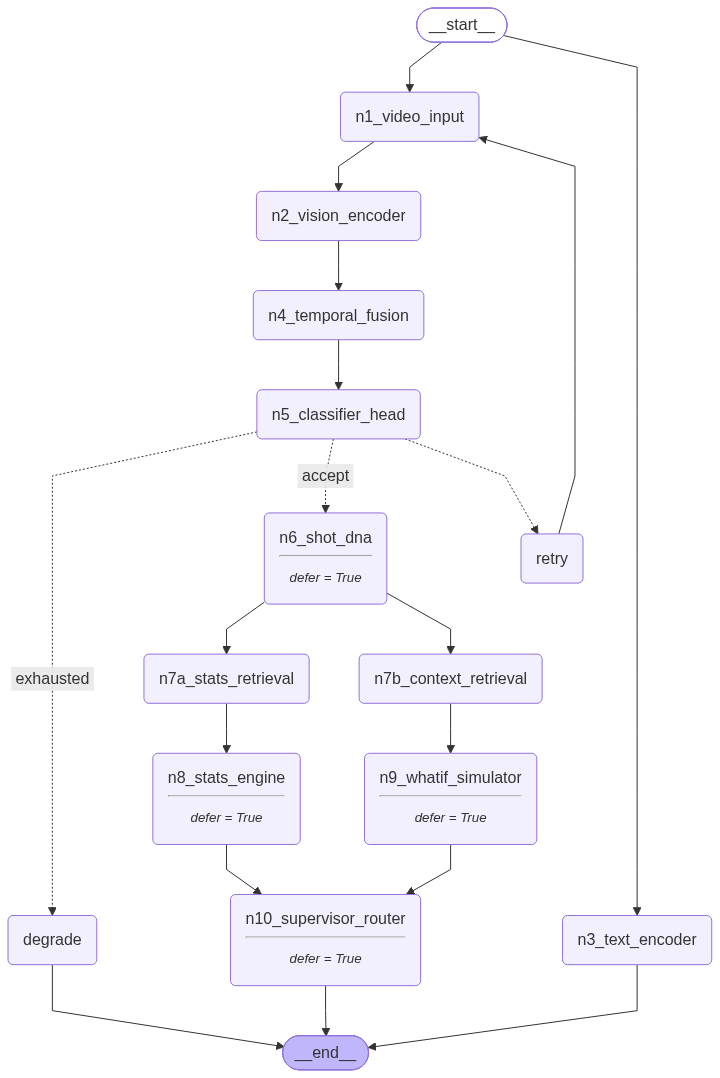

In [71]:
router_graph = build_router_graph()
show_graph(router_graph)

In [72]:
#A: the running example wakes the coach and the player
STUB_CONFIDENCE = 0.92
out7 = router_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
for aid in out7["active_agents"]:
    print(f"  {aid:32s} {AGENTS_BY_ID[aid]['stakeholder']}")

assert "n11b_tactical_analysis"    in out7["active_agents"]
assert "n11c_personal_performance" in out7["active_agents"]
assert len(out7["active_agents"]) <= MAX_ACTIVE_AGENTS
print()
print("OK: a match-up question woke the tactical and player agents")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots

  n11c_personal_performance        Players
  n11b_tactical_analysis        

In [73]:
# B: different stakeholders, different agents
TRACE = False
PROBES = [
    ("workload / injury",  "How much workload has Kohli carried this week, any injury risk?"),
    ("market valuation",   "What is Kohli's IPL auction valuation and market worth?"),
    ("broadcast",          "Generate commentary and a wagon wheel overlay clip"),
    ("compliance",         "Check ICC eligibility and audit the franchise"),
    ("vague",              "Tell me about this delivery"),
]

for label, q in PROBES:
    res = router_graph.invoke(new_state("clips/kohli_01.mp4", q))
    names = [AGENTS_BY_ID[a]["stakeholder"] for a in res["active_agents"]]
    print(f"  {label:18s} -> {names}")

TRACE = True

  workload / injury  -> ['Medical Teams']
  market valuation   -> ['Player Agents / Managers', 'Franchises / Boards']
  broadcast          -> ['Broadcasters']
  compliance         -> ['Governing Bodies']
  vague              -> ['Coaches', 'Players']


In [74]:
#C: the router never wakes everyone
TRACE = False
worst_case = ("budget auction squad tactic bowling technique shot scout league "
              "fan fantasy pitch prep crowd sponsor logo roi commentary overlay "
              "eligibility icc academy drill injury workload valuation market")

res = router_graph.invoke(new_state("clips/kohli_01.mp4", worst_case))
TRACE = True

print(f"  query matching every agent -> woke {len(res['active_agents'])}")
for aid in res["active_agents"]:
    print(f"    {AGENTS_BY_ID[aid]['stakeholder']}")

assert len(res["active_agents"]) == MAX_ACTIVE_AGENTS
assert len(res["active_agents"]) < len(AGENT_REGISTRY)
print()
print("OK: dispatch stays bounded even when every keyword fires")

  query matching every agent -> woke 4
    Franchises / Boards
    Sponsors
    Coaches
    Players

OK: dispatch stays bounded even when every keyword fires


## 11.The twelve stakeholder agents (N11a-N11l)

Twelve agents, **one factory**. Each is the same shape --- read the sanctioned
facts, say something in its own vocabulary --- and differs only in configuration:
its id, its stakeholder, its template and, critically, **which numbers it is
allowed to cite**.

Twelve copy-pasted functions would be twelve places to fix every future change,
and twelve places for a bug to hide in eleven of them.

### Dynamic fan-out

Step 7's router wrote `active_agents`. Turning that list into actual execution is
one conditional edge whose function returns **a list of node names** rather than a
single one:

```python
def dispatch_agents(state):
    return state.get("active_agents") or [END]

g.add_conditional_edges("n10_supervisor_router", dispatch_agents,
                        [a["id"] for a in AGENT_REGISTRY] + [END])
```

All twelve nodes are registered; only the named subset runs. That is the whole
mechanism --- a conditional function returning a list is LangGraph's fan-out.

### Citations are the point

Every finding carries a `cites` dict: the exact fact keys and values the agent
quoted. That is not decoration --- it is what makes Step 9 possible. The Faith
Check does not have to parse prose looking for numbers; it compares each cited
value against what N8 and N9 actually produced.

An agent that invents a figure has to invent it *in its citations*, where it is
trivially caught. This is the payoff for the Architecture v2 split: because the
two engines are the only sanctioned sources of numbers, there is a single
ground-truth surface to validate against.

In [75]:
def sanctioned_facts(state: CricketMindState) -> dict:
    """Every number an agent is permitted to use, in one flat dict.

    Sourced only from N8 (`stats_results`), N9 (`sim_results`), N6's posture
    metrics and N7b's context rows. If a value is not in here, no agent may
    quote it -- and Step 9 enforces that.

    The surface is **dynamic**. A text-only query carries no clip, so no posture
    was measured and `weight_transfer` is simply absent rather than defaulted.
    The router reads the same rule and declines to wake any agent whose
    citations cannot be satisfied.
    """
    stats = state["stats_results"]
    sim   = state["sim_results"]
    dna   = state["shot_dna"]

    best, worst = stats["best_shot"], stats["worst_shot"]
    ctx = {r["metric"]: r["value"] for r in (state.get("context_hits") or [])}

    facts = {
        "player":          dna["filters"].get("player", "the batsman"),
        "best_shot":       best,
        "worst_shot":      worst,
        "best_sr":         stats["by_shot"][best]["strike_rate"],
        "worst_sr":        stats["by_shot"][worst]["strike_rate"],
        "sample_size":     stats["sample_size"],
        "p_pct":           round(sim["p_dismissal"] * 100, 1),
        "deliveries":      SIM_DELIVERIES,
        "target_shot":     sim["target_shot"],
        "career_sr":       ctx.get("career_sr_vs_pace"),
        "venue_sr":        ctx.get("venue_sr"),
    }

    # video-only facts: present only when a clip was actually analysed
    if dna.get("shot"):
        facts["shot"] = dna["shot"]
    if dna.get("posture"):
        facts["weight_transfer"] = dna["posture"]["weight_transfer"]

    return facts


In [76]:
# Injection knobs for Step 9. An agent named here fabricates one of the figures
# it cites, which is what gives the Faith Check something real to catch.
HALLUCINATE_ONCE   = set()   # lies on the first attempt, corrects itself after
HALLUCINATE_ALWAYS = set()   # never corrects -- exercises the regenerate budget


def make_agent(config: dict):
    """Build one stakeholder agent node from its registry entry.

    A factory rather than twelve functions: the agents differ only in voice and
    in which facts they may quote, so that difference belongs in data. The node
    keeps the standard `(state) -> dict` signature, so an agent can later become
    a real LLM call without the graph changing.
    """
    def _agent(state: CricketMindState) -> dict:
        cid   = config["id"]
        facts = sanctioned_facts(state)

        lying = (cid in HALLUCINATE_ALWAYS) or (
            cid in HALLUCINATE_ONCE and state.get("regen_count", 0) == 0)
        if lying:
            # corrupt the fact itself, so the prose and the citation agree --
            # exactly the failure mode the Faith Check exists to catch
            facts = {**facts, config["cites"][0]: 999.0}

        text  = config["template"].format(**facts)
        cites = {k: facts[k] for k in config["cites"]}

        trace("N11", f"{config['stakeholder']}: cites {list(cites)}"
                     + ("   <-- FABRICATED" if lying else ""))
        return {"agent_findings": [{
            "agent":       cid,
            "stakeholder": config["stakeholder"],
            "text":        text,
            "cites":       cites,
        }]}

    _agent.__name__ = config["id"]
    return _agent

In [77]:
# One node per registry entry. All twelve are registered on the graph; the
# router decides which of them actually run.
AGENT_NODES = {a["id"]: make_agent(a) for a in AGENT_REGISTRY}
print(f"built {len(AGENT_NODES)} agent nodes from one factory")

built 12 agent nodes from one factory


In [78]:
def dispatch_agents(state: CricketMindState) -> list:
    """Conditional edge that returns a LIST -- LangGraph's fan-out.

    Every name returned is executed in the same superstep. Returning [END]
    rather than [] matters: an empty list leaves the graph with nothing to do
    and no way to finish.
    """
    chosen = state.get("active_agents") or []
    return chosen if chosen else [END]

In [79]:
def build_agent_graph():
    """Step 8 graph: the router now fans out to the chosen stakeholder agents."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",        n1_video_input)
    g.add_node("n2_vision_encoder",     n2_vision_encoder)
    g.add_node("n4_temporal_fusion",    n4_temporal_fusion)
    g.add_node("n5_classifier_head",    n5_classifier_head)
    g.add_node("n3_text_encoder",       n3_text_encoder)
    g.add_node("n6_shot_dna",           n6_shot_dna,           defer=True)
    g.add_node("n7a_stats_retrieval",   n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("n8_stats_engine",       n8_stats_engine,       defer=True)
    g.add_node("n9_whatif_simulator",   n9_whatif_simulator,   defer=True)
    g.add_node("n10_supervisor_router", n10_supervisor_router, defer=True)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    for aid, fn in AGENT_NODES.items():
        g.add_node(aid, fn)

    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")
    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")
    g.add_edge("n7a_stats_retrieval",   "n8_stats_engine")
    g.add_edge("n7b_context_retrieval", "n9_whatif_simulator")
    g.add_edge("n8_stats_engine",     "n10_supervisor_router")
    g.add_edge("n9_whatif_simulator", "n10_supervisor_router")

    # the fan-out: one conditional edge, many possible destinations
    g.add_conditional_edges("n10_supervisor_router", dispatch_agents,
                            list(AGENT_NODES) + [END])

    for aid in AGENT_NODES:
        g.add_edge(aid, END)

    g.add_edge("retry", "n1_video_input")
    g.add_edge("degrade", END)

    return g.compile()

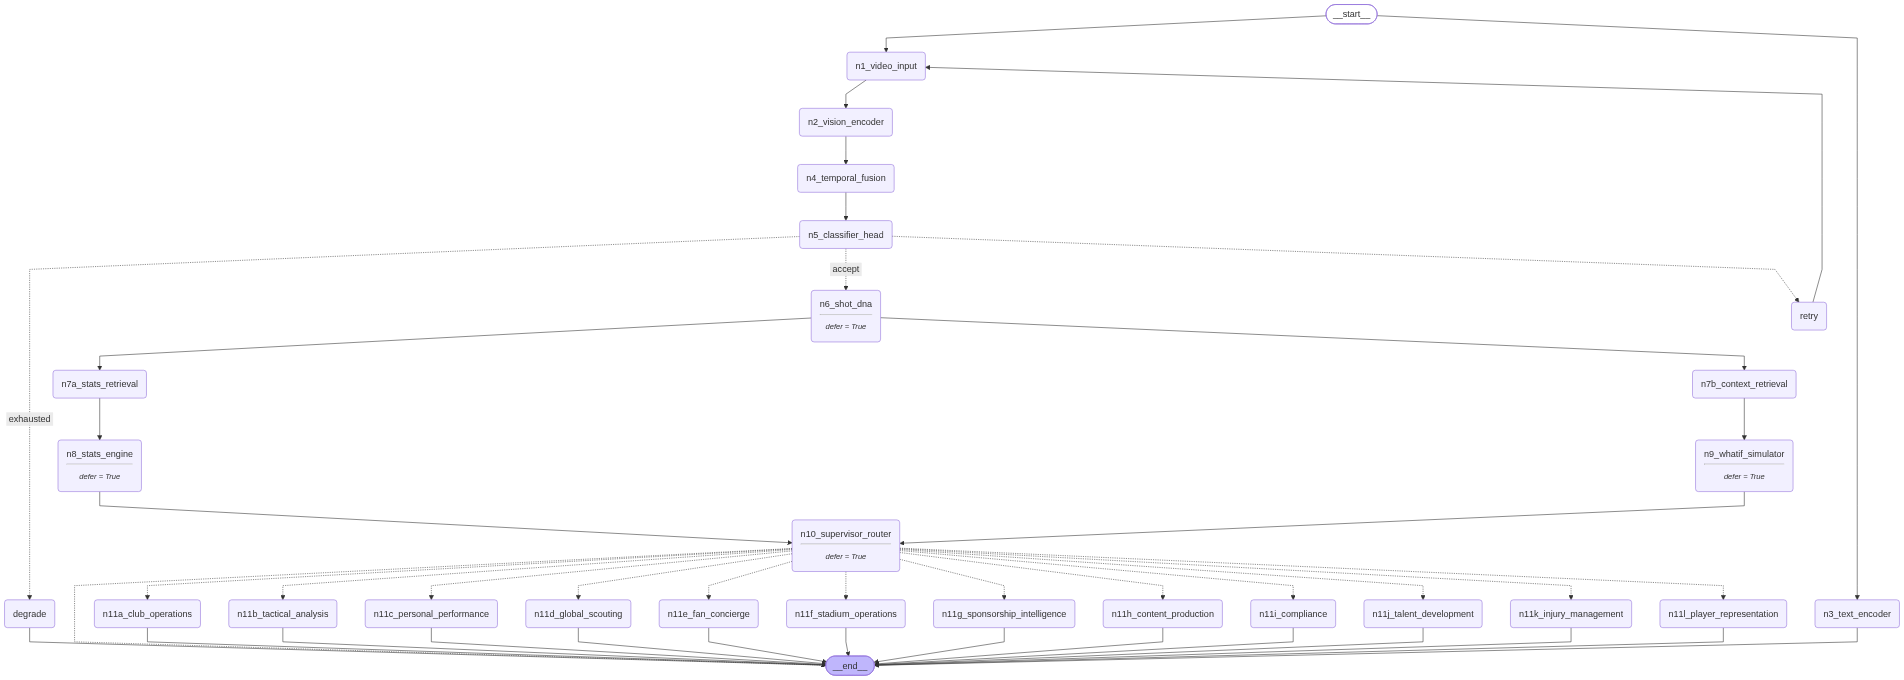

In [80]:
agent_graph = build_agent_graph()
show_graph(agent_graph)

In [81]:
# A: only the routed agents produce findings
STUB_CONFIDENCE = 0.92
out8 = agent_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
for f in out8["agent_findings"]:
    print(f"  [{f['stakeholder']}]")
    print(f"    {f['text']}")
    print(f"    cites: {f['cites']}")
    print()

ran = {f["agent"] for f in out8["agent_findings"]}
assert ran == set(out8["active_agents"]), "an agent ran that was not dispatched"
assert len(ran) < len(AGENT_REGISTRY), "everything ran -- the fan-out ignored the router"
print(f"OK: {len(ran)} of {len(AGENT_REGISTRY)} agents ran, exactly the routed set")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots
  [N11  ] Coaches: cites ['best_sr', 'worst_sr', 'p_pct']
  [N11  ] Players:

In [82]:
# B: every cited number really came from N8 or N9
facts = sanctioned_facts(out8)
bad = []
for f in out8["agent_findings"]:
    for key, value in f["cites"].items():
        if key not in facts or facts[key] != value:
            bad.append((f["agent"], key, value, facts.get(key)))

for f in out8["agent_findings"]:
    print(f"  {f['agent']:32s} {f['cites']}")

assert not bad, f"unsanctioned citations: {bad}"
print()
print("OK: every quoted figure matches the engines' output")

  n11b_tactical_analysis           {'best_sr': 142.0, 'worst_sr': 112.0, 'p_pct': 39.4}
  n11c_personal_performance        {'best_sr': 142.0, 'worst_sr': 112.0, 'weight_transfer': 0.88}

OK: every quoted figure matches the engines' output


In [83]:
# C: four agents in parallel, no lost or duplicated findings
TRACE = False
wide = ("bowling tactics, injury workload, auction valuation and technique "
        "for Kohli's pull shot against pace in the powerplay")
out8c = agent_graph.invoke(new_state("clips/kohli_01.mp4", wide))
TRACE = True

print(f"  routed : {len(out8c['active_agents'])} agents")
for f in out8c["agent_findings"]:
    print(f"    {f['stakeholder']}")

ids = [f["agent"] for f in out8c["agent_findings"]]
assert len(ids) == len(set(ids)), "upsert_findings duplicated an agent"
assert set(ids) == set(out8c["active_agents"])
assert len(ids) == MAX_ACTIVE_AGENTS
print()
print("OK: parallel agent writes merged cleanly through upsert_findings")

  routed : 4 agents
    Franchises / Boards
    Coaches
    Players
    Medical Teams

OK: parallel agent writes merged cleanly through upsert_findings


## 12.The Faith Check and the regenerate loop

The hallucination gate. Every number an agent quoted is compared against what N8
and N9 actually produced; anything unsupported sends that agent back.

### Why this is cheap in Architecture v2

The gate never parses prose. Step 8 made every agent record its citations
explicitly, and `sanctioned_facts()` is built only from the two engines, N6's
posture metrics and N7b's context. So verification is a dict comparison:

```python
for key, value in finding["cites"].items():
    if truth.get(key) != value:
        # unsupported claim
```

In the six-worker Version 1, where each worker did its own arithmetic, there was
no authoritative value to compare *against* --- the gate would have had to
adjudicate twelve independent chains of reasoning. Splitting the analytical
services out is what turns hallucination detection from a judgement call into an
equality test.

### The loop needs somewhere to put its counter

Same shape as the retry loop in Step 3. A conditional function returns a route
and cannot write state, so `regen_prep` owns `regen_count`, and a second
conditional fans back out to exactly the agents that failed --- not all of them.

### One correction to Step 1

`faith_failures` was declared with `Annotated[list, operator.add]`. That was
wrong. Only one node ever writes it, and on the second pass through the loop the
reducer would append the new failures to the stale ones, so a corrected agent
would look like it was still failing. Reducers are for fields written by
**parallel** nodes; a field written by a single node wants plain last-write-wins.
It is now a plain `list`.

### When a fan-in does *not* need `defer`

N6, N8, N9 and N10 are all `defer=True` because each waits on a branch of a
different depth. `faith_check` is not, and the distinction is worth stating
precisely:

* **Parents at different depths** (N6 waiting on both a one-node text branch and a
  four-node vision branch) need `defer` --- LangGraph has no all-parents barrier,
  so the shallow branch would trigger the node early.
* **Siblings from one fan-out** (the twelve agents) do not. They are dispatched by a
  single conditional edge into the same superstep, and a superstep completes as a
  unit, so `faith_check` is triggered once with all findings present.

Adding `defer=True` here was not merely redundant: it made `get_graph()` draw a
phantom `n13_final_output -> faith_check` edge and drop `n13_final_output -> END`
entirely. The runtime was correct either way --- `builder.edges` had the right
wiring --- but the rendered diagram, which is what goes in the thesis, was not.

In [84]:
def n_faith_check(state: CricketMindState) -> dict:
    """Faith Check -- the purple diamond.

    Compares every cited figure against the sanctioned facts. Writes the failure
    list (replacing it, not appending: see the note above).
    """
    truth    = sanctioned_facts(state)
    failures = []

    for f in state.get("agent_findings") or []:
        if f.get("rejected"):
            continue
        for key, claimed in f["cites"].items():
            actual = truth.get(key)
            if actual != claimed:
                failures.append({"agent": f["agent"], "key": key,
                                 "claimed": claimed, "actual": actual})

    if failures:
        for x in failures:
            trace("FAITH", f"REJECT {x['agent']}: {x['key']}={x['claimed']} "
                           f"but engines say {x['actual']}")
    else:
        trace("FAITH", f"all {len(state.get('agent_findings') or [])} findings verified")

    return {"faith_failures": failures}

In [85]:
def faith_gate(state: CricketMindState) -> str:
    """Route on the Faith Check result. Returns a route name only."""
    fails = state.get("faith_failures") or []
    if not fails:
        return "faithful"
    if state.get("regen_count", 0) >= MAX_REGENS:
        trace("FAITH", f"regenerate budget spent ({MAX_REGENS}) -> dropping claims")
        return "exhausted"
    return "regenerate"

In [86]:
def regen_prep(state: CricketMindState) -> dict:
    """Body of the regenerate edge: owns the counter that bounds the loop."""
    n = state.get("regen_count", 0) + 1
    who = sorted({f["agent"] for f in state["faith_failures"]})
    trace("REGEN", f"pass {n}/{MAX_REGENS}, re-running {len(who)}: {', '.join(who)}")
    return {"regen_count": n}

In [87]:
def dispatch_regen(state: CricketMindState) -> list:
    """Fan back out to exactly the agents that failed -- not all of them."""
    return sorted({f["agent"] for f in state.get("faith_failures") or []})

In [88]:
def drop_unfaithful(state: CricketMindState) -> dict:
    """Budget spent: withhold the unverifiable findings rather than publish them.

    Marks rather than deletes, because `agent_findings` merges through
    upsert_findings -- returning a shorter list would not remove anything. N12
    skips anything flagged, and the report says plainly what was withheld.
    """
    bad    = {f["agent"] for f in state["faith_failures"]}
    marked = [{**f, "rejected": True}
              for f in state["agent_findings"] if f["agent"] in bad]
    trace("DROP", f"withholding {len(marked)} unverifiable finding(s)")
    return {"agent_findings": marked, "status": "unverified_claims_dropped"}

## 13.Synthesis, output, and the finished graph

`n12_supervisor_synthesis` assembles the verified findings into one report,
ordered by the router's own ranking so the most relevant stakeholder speaks
first. `n13_final_output` is the terminal node.

Anything the Faith Check withheld is named in the report rather than silently
dropped --- a reader should be able to see that an agent was overruled.

In [89]:
def n12_supervisor_synthesis(state: CricketMindState) -> dict:
    """N12 -- Supervisor LLM. Composes the verified findings into one report.

    Real version: an LLM call that resolves overlap between agents and writes
    connective prose. The ordering and the withheld-claims section are policy,
    not generation, so they stay here either way.
    """
    all_findings = state.get("agent_findings") or []
    kept    = [f for f in all_findings if not f.get("rejected")]
    dropped = [f for f in all_findings if f.get("rejected")]

    rank = {a: i for i, a in enumerate(state.get("active_agents") or [])}
    kept.sort(key=lambda f: rank.get(f["agent"], 99))

    dna, stats, sim = state["shot_dna"], state["stats_results"], state["sim_results"]
    sr_line = ", ".join(f"{s} SR {a['strike_rate']}" for s, a in stats["by_shot"].items())

    lines = [
        f"CRICKETMIND REPORT -- {dna['filters'].get('player', 'batsman')}",
        "=" * 72,
        f"Query      : {state['query']}",
        (f"Vision     : {dna['shot']} at {dna['confidence']:.0%} confidence "
         f"({dna['attempts']} attempt(s))") if dna.get("shot")
        else "Vision     : no clip supplied -- text-only query",
        f"Evidence   : {stats['sample_size']} deliveries -- {sr_line}",
        f"Simulation : {sim['scenario']} -> {sim['p_dismissal']:.1%} "
        f"(95% CI {sim['ci95'][0]:.1%}-{sim['ci95'][1]:.1%}, {sim['trials']:,} trials)",
        "",
        f"FINDINGS ({len(kept)} agent(s))",
        "-" * 72,
    ]
    for f in kept:
        lines.append(f"[{f['stakeholder']}]")
        lines.append(f"  {f['text']}")
        lines.append("")

    if dropped:
        lines += ["WITHHELD -- failed verification against N8/N9", "-" * 72]
        lines += [f"  {f['stakeholder']} ({f['agent']})" for f in dropped]
        lines.append("")

    trace("N12", f"synthesised {len(kept)} finding(s), withheld {len(dropped)}")
    return {"report": "\n".join(lines)}

In [90]:
def n13_final_output(state: CricketMindState) -> dict:
    """N13 -- the terminal node. Stamps the run's overall status."""
    report = state.get("report")
    assert report, "n13_final_output: n12 produced no report"
    status = state.get("status", "ok")
    trace("N13", f"report ready ({len(report.splitlines())} lines), status={status}")
    return {"status": status}

## 13. Two ways in: video-grounded and text-only

Every graph so far assumed a clip. `START` fanned out to N1 and N3 together, and
N6 was triggered by the Conf. Check once the classifier had cleared it.

That assumption does not hold for the whole question space. *"What if Rohit had
batted at number two instead of Kohli?"* is a legitimate query with **no video at
all** --- there is no clip, no stroke to classify, and nothing for the Conf.
Check to gate.

So `START` becomes a conditional edge. The vision branch runs only when a clip
was supplied; otherwise control goes straight to N6, which grounds the query from
its own filters alone. N3 runs on both paths, because every query has text.

```python
g.add_conditional_edges(START, has_video, {
    "video":     "n1_video_input",
    "text_only": "n6_shot_dna",
})
g.add_edge(START, "n3_text_encoder")     # both paths
```

`n6_shot_dna` keeps `defer=True`, and it is doing real work on the text-only
path: N3 and N6 are both scheduled by `START` in the same superstep, and the
deferral is what stops N6 running before N3 has written the filters it needs.

**This is a topology change, not a node change.** It is cheap now and expensive
later --- retrofitting it would mean touching the Conf. Check, the retry loop and
the sanctioned-fact surface at the same time.

In [91]:
def has_video(state: CricketMindState) -> str:
    """START router. Decides whether the vision branch runs at all.

    Returns a ROUTE NAME only, like conf_gate and faith_gate.
    """
    route = "video" if state.get("video_path") else "text_only"
    trace("START", f"{route} query")
    return route


In [92]:
def build_cricketmind_graph():
    """The complete CricketMind graph: every node of Architecture v2."""
    g = StateGraph(CricketMindState)

    # --- perception -------------------------------------------------
    g.add_node("n1_video_input",        n1_video_input)
    g.add_node("n2_vision_encoder",     n2_vision_encoder)
    g.add_node("n4_temporal_fusion",    n4_temporal_fusion)
    g.add_node("n5_classifier_head",    n5_classifier_head)
    g.add_node("n3_text_encoder",       n3_text_encoder)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    # grounding, retrieval, analytics
    g.add_node("n6_shot_dna",           n6_shot_dna,           defer=True)
    g.add_node("n7a_stats_retrieval",   n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("n8_stats_engine",       n8_stats_engine,       defer=True)
    g.add_node("n9_whatif_simulator",   n9_whatif_simulator,   defer=True)
    g.add_node("n10_supervisor_router", n10_supervisor_router, defer=True)

    # the twelve stakeholder agents 
    for aid, fn in AGENT_NODES.items():
        g.add_node(aid, fn)

    # verification and synthesis 
    # NOT deferred, unlike the fan-ins above. The agents are siblings
    # dispatched by a single conditional edge, so they all complete in the
    # same superstep and faith_check is triggered once, after all of them.
    # defer=True here is not only unnecessary, it makes get_graph() draw a
    # phantom n13 -> faith_check edge and lose n13 -> END.
    g.add_node("faith_check", n_faith_check)
    g.add_node("regen_prep",  regen_prep)
    g.add_node("drop_unfaithful", drop_unfaithful)
    g.add_node("n12_supervisor_synthesis", n12_supervisor_synthesis)
    g.add_node("n13_final_output",         n13_final_output)

    # edges 
    # Two ways in. Only a query carrying a clip enters the vision branch;
    # a text-only question goes straight to N6 and grounds on its filters.
    g.add_conditional_edges(START, has_video, {
        "video":     "n1_video_input",
        "text_only": "n6_shot_dna",
    })
    g.add_edge(START, "n3_text_encoder")     # every query has text
    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })
    g.add_edge("retry", "n1_video_input")

    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")
    g.add_edge("n7a_stats_retrieval",   "n8_stats_engine")
    g.add_edge("n7b_context_retrieval", "n9_whatif_simulator")
    g.add_edge("n8_stats_engine",     "n10_supervisor_router")
    g.add_edge("n9_whatif_simulator", "n10_supervisor_router")

    g.add_conditional_edges("n10_supervisor_router", dispatch_agents,
                            list(AGENT_NODES) + [END])
    for aid in AGENT_NODES:
        g.add_edge(aid, "faith_check")

    g.add_conditional_edges("faith_check", faith_gate, {
        "faithful":   "n12_supervisor_synthesis",
        "regenerate": "regen_prep",
        "exhausted":  "drop_unfaithful",
    })
    g.add_conditional_edges("regen_prep", dispatch_regen, list(AGENT_NODES))
    g.add_edge("drop_unfaithful", "n12_supervisor_synthesis")

    g.add_edge("n12_supervisor_synthesis", "n13_final_output")
    g.add_edge("n13_final_output", END)
    g.add_edge("degrade", END)

    return g.compile()

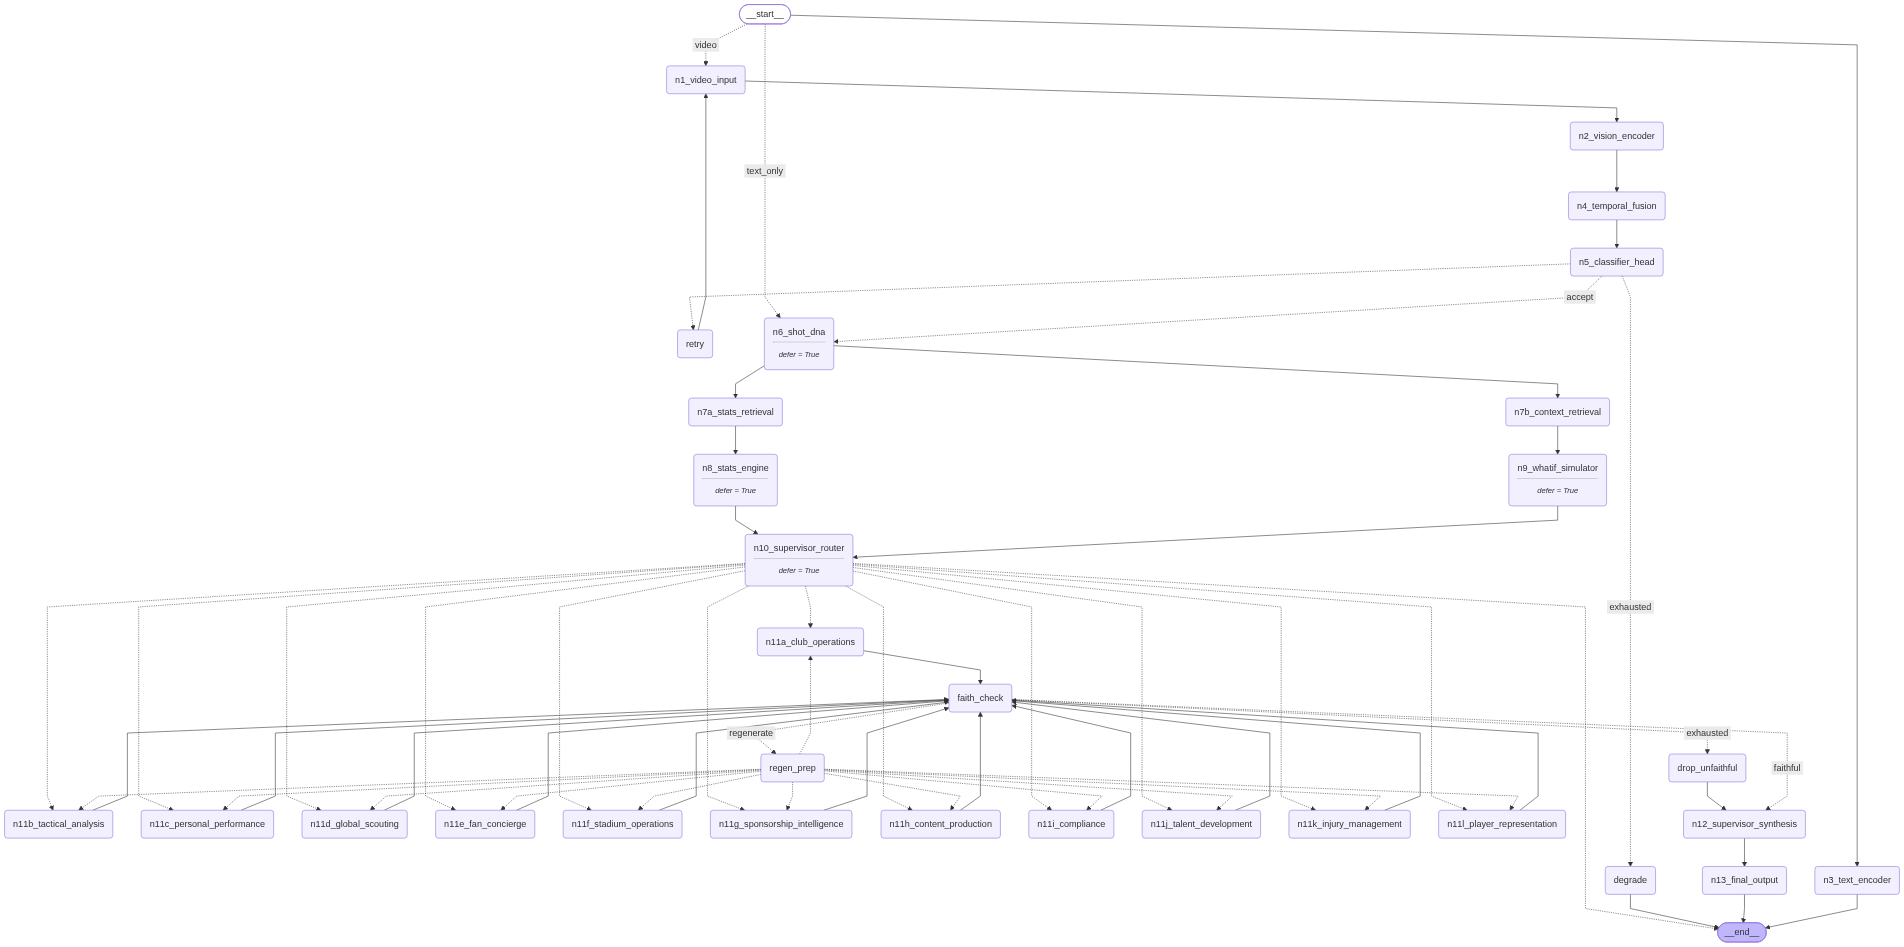

In [93]:
cricketmind = build_cricketmind_graph()
show_graph(cricketmind)

In [94]:
#9A: nothing fabricated -> straight through
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), set()
STUB_CONFIDENCE = 0.92
r9a = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
assert r9a["faith_failures"] == []
assert r9a.get("regen_count", 0) == 0
assert r9a["status"] == "ok"
print("OK: verified findings pass the gate untouched")

  [START] video query
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots
  [N11  ] Coaches: cites ['best_sr', 'worst_sr', 'p_pc

In [95]:
# 9B: one agent fabricates, is caught, and is regenerated
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = {"n11b_tactical_analysis"}, set()
r9b = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
HALLUCINATE_ONCE = set()

print()
print("regen_count      :", r9b["regen_count"])
print("failures at end  :", r9b["faith_failures"])
for f in r9b["agent_findings"]:
    print(f"  {f['agent']:32s} {f['cites']}")

assert r9b["regen_count"] == 1,        "the loop did not fire exactly once"
assert r9b["faith_failures"] == [],    "the corrected finding still fails"
assert not any(999.0 in f["cites"].values() for f in r9b["agent_findings"])
assert len(r9b["agent_findings"]) == len(r9b["active_agents"]), "upsert duplicated"
print()
print("OK: fabrication caught, agent re-run, corrected value replaced the bad one")

  [START] video query
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots
  [N11  ] Coaches: cites ['best_sr', 'worst_sr', 'p_pc

In [96]:
# 9C: an agent that never corrects -> claims withheld
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), {"n11b_tactical_analysis"}
r9c = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
HALLUCINATE_ALWAYS = set()

print()
print("regen_count :", r9c["regen_count"], "| status:", r9c["status"])
for f in r9c["agent_findings"]:
    print(f"  {f['agent']:32s} rejected={f.get('rejected', False)}")

assert r9c["regen_count"] == MAX_REGENS
assert r9c["status"] == "unverified_claims_dropped"
assert any(f.get("rejected") for f in r9c["agent_findings"])
print()
print("OK: budget spent, unverifiable claim withheld rather than published")

  [START] video query
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots
  [N11  ] Coaches: cites ['best_sr', 'worst_sr', 'p_pc

In [97]:
# 10: the whole system, end to end 
TRACE = False
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), set()
STUB_CONFIDENCE = 0.92
final = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
TRACE = True

print(final["report"])

CRICKETMIND REPORT -- Kohli
Query      : Compare Kohli's cover drive vs his pull shot against fast bowlers in the powerplay
Vision     : Cover Drive at 92% confidence (1 attempt(s))
Evidence   : 100 deliveries -- Cover Drive SR 142.0, Pull SR 112.0
Simulation : 6 consecutive deliveries targeting the pull -> 39.4% (95% CI 38.7%-40.1%, 20,000 trials)

FINDINGS (2 agent(s))
------------------------------------------------------------------------
[Players]
  Weight transfer on the Cover Drive measures 0.88, and it is the stronger stroke at SR 142.0. The Pull lags at SR 112.0 -- shot selection, not technique, is the gap to close.

[Coaches]
  Bowl short at Kohli. The Pull returns SR 112.0 against the Cover Drive's SR 142.0; 6 consecutive back-of-a-length deliveries carry a 39.4% chance of dismissal.



In [98]:
# 10B: coverage against Architecture v2
nodes = [n for n in cricketmind.get_graph().nodes if not n.startswith("__")]
expected = {
    "N1-N5 perception":   ["n1_video_input", "n2_vision_encoder", "n4_temporal_fusion",
                           "n5_classifier_head", "n3_text_encoder"],
    "gates + loops":      ["retry", "degrade", "faith_check", "regen_prep", "drop_unfaithful"],
    "N6 grounding":       ["n6_shot_dna"],
    "N7 retrieval":       ["n7a_stats_retrieval", "n7b_context_retrieval"],
    "N8/N9 services":     ["n8_stats_engine", "n9_whatif_simulator"],
    "N10 router":         ["n10_supervisor_router"],
    "N11a-l agents":      list(AGENT_NODES),
    "N12/N13 synthesis":  ["n12_supervisor_synthesis", "n13_final_output"],
}
for group, names in expected.items():
    missing = [n for n in names if n not in nodes]
    print(f"  {group:20s} {len(names):2d} node(s)  {'OK' if not missing else 'MISSING ' + str(missing)}")
    assert not missing

print(f"\n  total: {len(nodes)} nodes, {len(AGENT_NODES)} of them stakeholder agents")
print("  14 agents = 12 stakeholder-facing + 2 shared analytical services (N8, N9)")

  N1-N5 perception      5 node(s)  OK
  gates + loops         5 node(s)  OK
  N6 grounding          1 node(s)  OK
  N7 retrieval          2 node(s)  OK
  N8/N9 services        2 node(s)  OK
  N10 router            1 node(s)  OK
  N11a-l agents        12 node(s)  OK
  N12/N13 synthesis     2 node(s)  OK

  total: 30 nodes, 12 of them stakeholder agents
  14 agents = 12 stakeholder-facing + 2 shared analytical services (N8, N9)


In [99]:
# 10C: Mermaid source, for pasting into the thesis
print(cricketmind.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	n1_video_input(n1_video_input)
	n2_vision_encoder(n2_vision_encoder)
	n4_temporal_fusion(n4_temporal_fusion)
	n5_classifier_head(n5_classifier_head)
	n3_text_encoder(n3_text_encoder)
	retry(retry)
	degrade(degrade)
	n6_shot_dna(n6_shot_dna<hr/><small><em>defer = True</em></small>)
	n7a_stats_retrieval(n7a_stats_retrieval)
	n7b_context_retrieval(n7b_context_retrieval)
	n8_stats_engine(n8_stats_engine<hr/><small><em>defer = True</em></small>)
	n9_whatif_simulator(n9_whatif_simulator<hr/><small><em>defer = True</em></small>)
	n10_supervisor_router(n10_supervisor_router<hr/><small><em>defer = True</em></small>)
	n11a_club_operations(n11a_club_operations)
	n11b_tactical_analysis(n11b_tactical_analysis)
	n11c_personal_performance(n11c_personal_performance)
	n11d_global_scouting(n11d_global_scouting)
	n11e_fan_concierge(n11e_fan_concierge)
	n11f_stadium_operations(n11f_stadium_operations)
	n11g_sp

In [100]:
cricketmind.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n1_video_input': Node(id='n1_video_input', name='n1_video_input', data=n1_video_input(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n2_vision_encoder': Node(id='n2_vision_encoder', name='n2_vision_encoder', data=n2_vision_encoder(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n4_temporal_fusion': Node(id='n4_temporal_fusion', name='n4_temporal_fusion', data=n4_temporal_fusion(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n5_classifier_head': Node(id='n5_classifier_head', name='n5_classifier_head', data=n5_classifier_head(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n3_text_encoder': Node(id='n3_text_encoder', name='n3_text_encoder', data=n3_text_encoder(tags=None, recurse=True, explode_ar

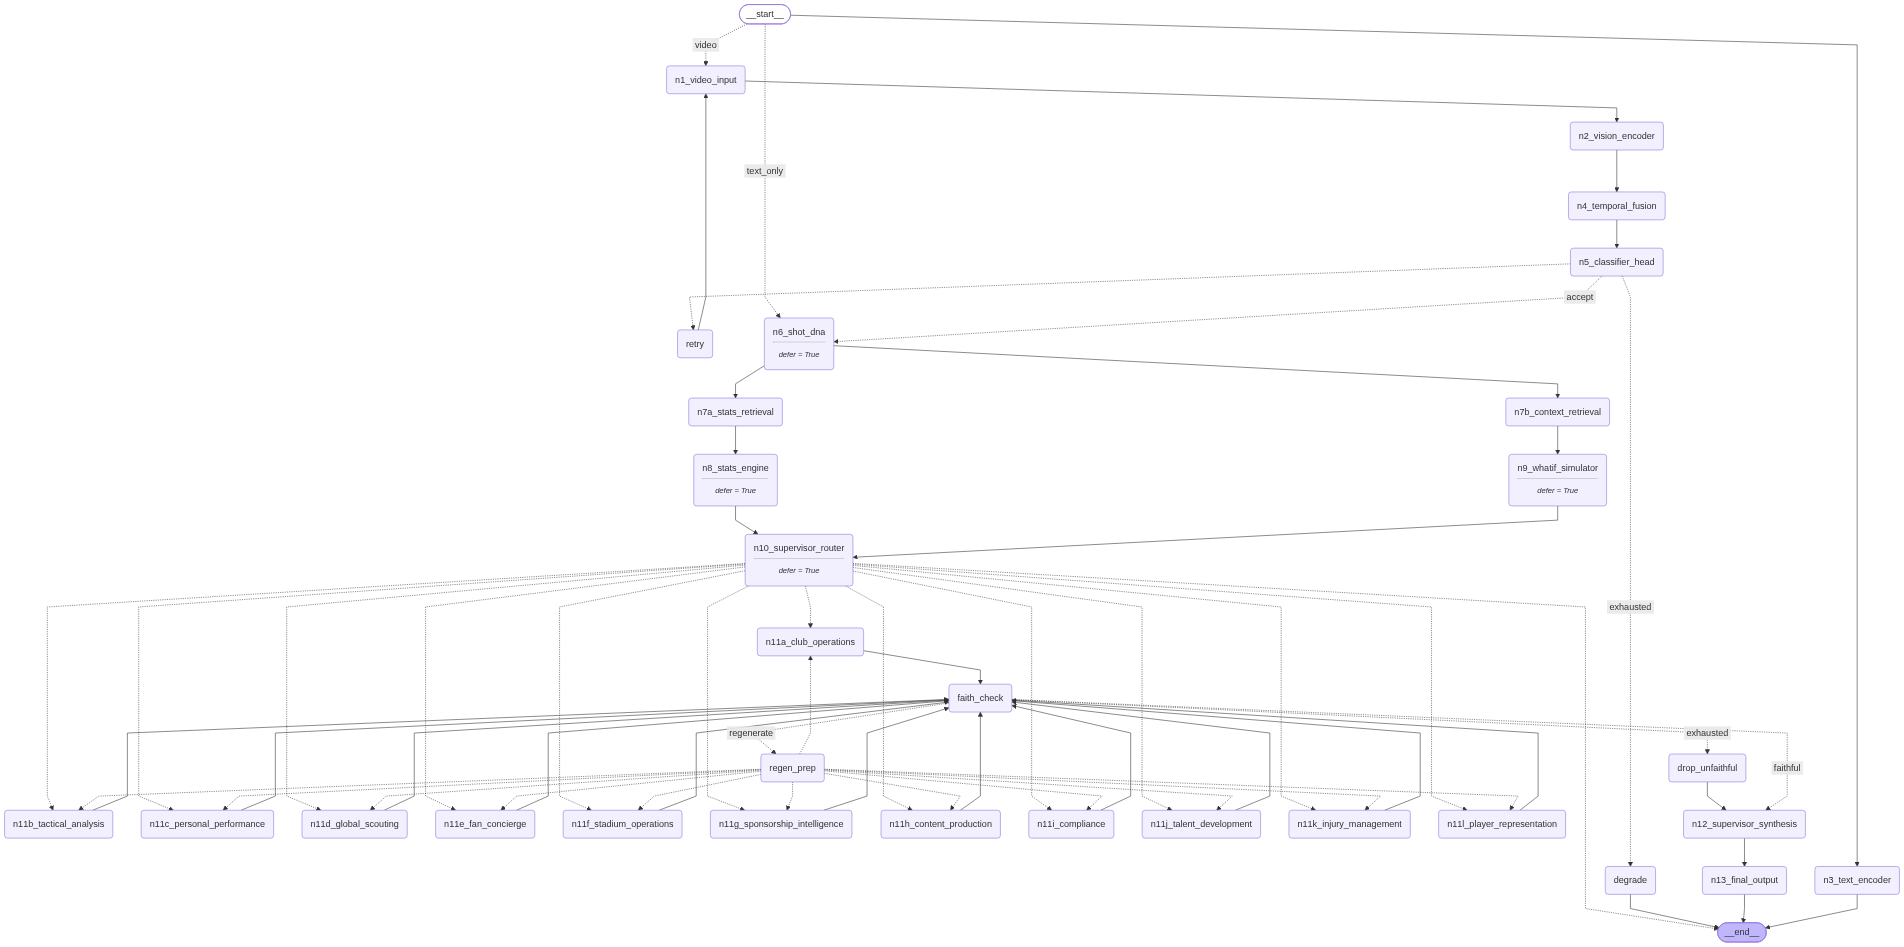

In [101]:
show_graph(cricketmind)

### Checkpoint: both entry paths

Five checks. The first confirms nothing about the video path changed; the rest
exercise the new one. The last is the check that caught a real bug once already
--- a wrong `defer` setting produces a correct run and a wrong diagram.

In [102]:
# 13A: the video path behaves exactly as before
TRACE = False
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), set()
STUB_CONFIDENCE = 0.92
rv = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
TRACE = True

assert rv["shot_dna"]["modality"] == "video"
assert rv["shot_dna"]["shot"]     is not None
assert rv["shot_dna"]["posture"]  is not None
assert rv["status"] == "ok"
assert rv["faith_failures"] == []
print("OK: video path unchanged --", rv["shot_dna"]["shot"],
      "| agents:", len(rv["active_agents"]))

OK: video path unchanged -- Cover Drive | agents: 2


In [103]:
# 13B: a text-only query never enters the vision branch
TRACE = False
rt = cricketmind.invoke(new_state(None, QUERY))
TRACE = True

assert rt["shot_dna"]["modality"] == "text"
assert rt["shot_dna"]["shot"]     is None
assert rt["shot_dna"]["posture"]  is None
assert "frames"     not in rt,  "N1 ran on a query with no clip"
assert "shot_label" not in rt,  "the classifier ran on a query with no clip"
assert rt["retry_count"] == 0
assert rt["stats_hits"],        "retrieval found nothing from the query's own shots"
assert rt["status"] == "ok"
print("OK: text-only path reached the report without the vision branch")
print("    deliveries retrieved:", len(rt["stats_hits"]))

OK: text-only path reached the report without the vision branch
    deliveries retrieved: 100


In [104]:
# 13C: agents whose evidence does not exist are not woken
posture_agents = {a["id"] for a in AGENT_REGISTRY if "weight_transfer" in a["cites"]}
woke = set(rt["active_agents"])
assert not (woke & posture_agents), f"woke an agent with no posture evidence: {woke & posture_agents}"

facts_t = sanctioned_facts(rt)
assert "weight_transfer" not in facts_t, "posture leaked into the sanctioned facts"
assert "shot"            not in facts_t
assert "weight_transfer" in sanctioned_facts(rv), "video path lost its posture facts"

print("OK: text-only facts =", sorted(facts_t))
print("    blocked agents  =", sorted(AGENTS_BY_ID[a]["stakeholder"] for a in posture_agents))
print("    woke            =", [AGENTS_BY_ID[a]["stakeholder"] for a in woke])

OK: text-only facts = ['best_shot', 'best_sr', 'career_sr', 'deliveries', 'p_pct', 'player', 'sample_size', 'target_shot', 'venue_sr', 'worst_shot', 'worst_sr']
    blocked agents  = ['Academies', 'Players']
    woke            = ['Coaches']


In [105]:
# 13D: verification still works on the text-only path
TRACE = False
HALLUCINATE_ALWAYS = set()
HALLUCINATE_ONCE   = {rt["active_agents"][0]}
rt2 = cricketmind.invoke(new_state(None, QUERY))
HALLUCINATE_ONCE   = set()
TRACE = True

assert rt2["regen_count"] == 1, "the fabrication was not caught on the text path"
assert rt2["faith_failures"] == []
assert not any(999.0 in f["cites"].values() for f in rt2["agent_findings"])
print("OK: fabrication caught and regenerated on a text-only query too")

OK: fabrication caught and regenerated on a text-only query too


In [106]:
# 13E: the rendered graph shows both entry paths and no phantom edges
edges = [(e.source, e.target) for e in cricketmind.get_graph().edges]
srcs  = {t for s, t in edges if s == "__start__"}
assert "n1_video_input"  in srcs, "video entry missing"
assert "n6_shot_dna"     in srcs, "text-only entry missing"
assert "n3_text_encoder" in srcs, "the text encoder no longer runs on both paths"
assert ("n13_final_output", "__end__") in edges, "lost n13 -> END"
print("OK: START ->", sorted(srcs))
print("   ", len(edges), "edges total")

OK: START -> ['n1_video_input', 'n3_text_encoder', 'n6_shot_dna']
    61 edges total


In [107]:
# 13F: the same query, answered without a clip
print(rt["report"])

CRICKETMIND REPORT -- Kohli
Query      : Compare Kohli's cover drive vs his pull shot against fast bowlers in the powerplay
Vision     : no clip supplied -- text-only query
Evidence   : 100 deliveries -- Cover Drive SR 142.0, Pull SR 112.0
Simulation : 6 consecutive deliveries targeting the pull -> 39.4% (95% CI 38.7%-40.1%, 20,000 trials)

FINDINGS (1 agent(s))
------------------------------------------------------------------------
[Coaches]
  Bowl short at Kohli. The Pull returns SR 112.0 against the Cover Drive's SR 142.0; 6 consecutive back-of-a-length deliveries carry a 39.4% chance of dismissal.



## 14. Execution profile: what each situation costs

Running one query many times teaches nothing -- the graph is deterministic, so it
gives the same trace every time. What *is* worth measuring is how the cost of a
query changes with the situation: a confident clip, a blurry clip that needs a
retry, an agent that lies, a question with no clip at all.

For each situation we count three things:

| Count | Meaning |
|---|---|
| **steps** | supersteps -- rounds of the graph; nodes in the same round run in parallel |
| **node runs** | total node executions, counting a node again each time a loop re-runs it |
| **agent calls** | stakeholder-agent executions -- in deployment, each one is an LLM call |

First we need a way to *record* a run instead of just getting its final state.

In [108]:
def record_run(state: CricketMindState) -> list:
    """Run one query and write down which node ran in which step.

    invoke() only hands back the final state, so we cannot see the path the
    query took. stream() runs the same graph but reports events as they
    happen. With stream_mode="debug" one kind of event is a "task", which
    means "this node is running in this step" -- that is all we keep.

    Returns a list of (step, node) pairs, for example:
        [(1, "n1_video_input"), (1, "n3_text_encoder"), (2, "n2_vision_encoder"), ...]
    Two pairs with the same step number ran in parallel.
    """
    timeline = []
    for event in cricketmind.stream(state, stream_mode="debug"):
        if event["type"] == "task":
            step = event["step"]
            node = event["payload"]["name"]
            timeline.append((step, node))
    return timeline

In [109]:
# 14A: record the confident video run, step by step
TRACE = False                                   # silence the nodes' own logs
STUB_CONFIDENCE = 0.92                          # clip is classified confidently
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), set()   # no agent lies
timeline = record_run(new_state("clips/kohli_01.mp4", QUERY))
TRACE = True

for step, node in timeline:
    print(f"step {step:2d}: {node}")

step_numbers = {step for step, node in timeline}      # a set keeps each step once
print()
print("steps     :", len(step_numbers))
print("node runs :", len(timeline))

assert len(step_numbers) == 12, f"expected 12 steps, got {len(step_numbers)}"
assert timeline[0][0] == 1, "the first node should run in step 1"
print("OK: the confident video run takes 12 steps")

step  1: n1_video_input
step  1: n3_text_encoder
step  2: n2_vision_encoder
step  3: n4_temporal_fusion
step  4: n5_classifier_head
step  5: n6_shot_dna
step  6: n7a_stats_retrieval
step  6: n7b_context_retrieval
step  7: n8_stats_engine
step  7: n9_whatif_simulator
step  8: n10_supervisor_router
step  9: n11b_tactical_analysis
step  9: n11c_personal_performance
step 10: faith_check
step 11: n12_supervisor_synthesis
step 12: n13_final_output

steps     : 12
node runs : 16
OK: the confident video run takes 12 steps


### Setting up a situation safely

A situation is set by four global settings: `TRACE`, `STUB_CONFIDENCE`,
`HALLUCINATE_ONCE` and `HALLUCINATE_ALWAYS`. Changing them by hand is risky --
forget to change one back, and every later cell silently runs in the wrong
situation.

`run_scenario` changes them, records the run, and **always** puts them back,
even if the run crashes.

In [110]:
def run_scenario(clip, confidence, lie_once=(), lie_always=()) -> list:
    """Set up one situation, record the run, then put every setting back.

    clip        a clip path, or None for a text-only query
    confidence  what the classifier scores -- one number for every attempt,
                or a list with one number per attempt, e.g. [0.40, 0.92]
    lie_once    agent ids that lie on their first try, then correct themselves
    lie_always  agent ids that lie on every try

    Returns the timeline from record_run.
    """
    global TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS

    # 1. remember the current settings
    saved = (TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)

    # 2. set up this situation
    TRACE              = False
    STUB_CONFIDENCE    = confidence
    HALLUCINATE_ONCE   = set(lie_once)
    HALLUCINATE_ALWAYS = set(lie_always)

    # 3. run it, and put the settings back whatever happens
    try:
        return record_run(new_state(clip, QUERY))
    finally:
        TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = saved

In [111]:
# 14B: a scenario changes the settings only while it runs
before = (TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)

timeline = run_scenario("clips/kohli_01.mp4",
                        confidence=[0.40, 0.92],                # fail once, then pass
                        lie_once={"n11b_tactical_analysis"})   # Coaches lies once

after = (TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)
ran_nodes = [node for step, node in timeline]

print("settings before:", before)
print("settings after :", after)
print("retry ran      :", "retry" in ran_nodes)
print("regen ran      :", "regen_prep" in ran_nodes)
print("steps          :", len({step for step, node in timeline}))

assert "retry" in ran_nodes,      "the low-confidence setting did not take effect"
assert "regen_prep" in ran_nodes, "the lying agent setting did not take effect"
assert after == before,           "run_scenario did not put the settings back"
print("OK: the situation applied during the run, and was undone after it")

settings before: (True, 0.92, set(), set())
settings after : (True, 0.92, set(), set())
retry ran      : True
regen ran      : True
steps          : 20
OK: the situation applied during the run, and was undone after it


In [112]:
# 14C: settings are put back even when the run crashes
before = (TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)

try:
    run_scenario("clips/kohli_01.mp4", confidence="not a number")   # N5 cannot use this
    crashed = False
except Exception as e:
    crashed = True
    print("crashed as expected:", type(e).__name__)

after = (TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)
print("settings after crash:", after)

assert crashed,         "the bad setting should have crashed the run"
assert after == before, "a crash left the settings changed"
print("OK: finally restored the settings after a crash")

crashed as expected: ValueError
settings after crash: (True, 0.92, set(), set())
OK: finally restored the settings after a crash


### The cost table

Three pieces:

1. `profile` turns a timeline into counts -- steps, node runs, agent calls, and
   what happened along the way (retries, regenerations, dropped or degraded).
2. `SCENARIOS` lists the six situations to run. It is data, not code: adding a
   situation means adding one entry, not writing a new test.
3. Test 14D runs every scenario and prints one row per situation.

In [113]:
def profile(timeline: list) -> dict:
    """Turn a timeline from record_run into the counts for the cost table.

    steps        how many rounds the graph took (parallel nodes share a round)
    node_runs    how many times any node ran, counting loop re-runs
    agent_calls  how many times a stakeholder agent ran -- an LLM call in deployment
    retries      how many times the vision branch was sent back to N1
    regens       how many times failed agents were sent back to try again
    dropped      True if unverifiable findings were withheld at the end
    degraded     True if the query stopped early because the clip stayed unclear
    """
    ran_nodes = [node for step, node in timeline]

    return {
        "steps":       len({step for step, node in timeline}),
        "node_runs":   len(timeline),
        "agent_calls": sum(1 for node in ran_nodes if node in AGENTS_BY_ID),
        "retries":     ran_nodes.count("retry"),
        "regens":      ran_nodes.count("regen_prep"),
        "dropped":     "drop_unfaithful" in ran_nodes,
        "degraded":    "degrade" in ran_nodes,
    }

In [114]:
# The six situations. Each one is a dictionary of run_scenario's inputs plus
# a name. A key that is left out (for example lie_once) means "nobody lies".
CLIP = "clips/kohli_01.mp4"

SCENARIOS = [
    {"name": "Video, confident",
     "clip": CLIP, "confidence": 0.92},

    {"name": "Text-only (no clip)",
     "clip": None, "confidence": 0.92},

    {"name": "Video, one retry then accept",
     "clip": CLIP, "confidence": [0.40, 0.92]},

    {"name": "Video, one agent lies once",
     "clip": CLIP, "confidence": 0.92,
     "lie_once": {"n11b_tactical_analysis"}},

    {"name": "Retries used up (degrade)",
     "clip": CLIP, "confidence": 0.40},

    {"name": "Worst case: 2 retries, agents never fix",
     "clip": CLIP, "confidence": [0.40, 0.40, 0.92],
     "lie_always": {a["id"] for a in AGENT_REGISTRY}},

    {"name": "Text-only, one agent lies once",
     "clip": None, "confidence": 0.92,
     "lie_once": {"n11b_tactical_analysis"}},
]
print(len(SCENARIOS), "scenarios")

7 scenarios


In [115]:
# 14D: run every scenario and build the cost table
cost_rows = []
for sc in SCENARIOS:
    timeline = run_scenario(sc["clip"], sc["confidence"],
                            lie_once=sc.get("lie_once", ()),
                             lie_always=sc.get("lie_always", ()))
    cost_rows.append({"scenario": sc["name"], **profile(timeline)})

header = f"{'scenario':40s} {'retries':>7s} {'regens':>6s} {'steps':>5s} {'node runs':>9s} {'agent calls':>11s}"
print(header)
print("-" * len(header))
for r in cost_rows:
    print(f"{r['scenario']:40s} {r['retries']:7d} {r['regens']:6d} "
          f"{r['steps']:5d} {r['node_runs']:9d} {r['agent_calls']:11d}")

# What each run measured before this cell existed. If a later change to the
# graph alters a cost, this is where you find out.
EXPECTED_COSTS = {                         # (steps, node runs, agent calls)
    "Video, confident":                        (12, 16, 2),
    "Text-only (no clip)":                     ( 9, 11, 1),
    "Video, one retry then accept":            (17, 21, 2),
    "Video, one agent lies once":              (15, 19, 3),
    "Retries used up (degrade)":               (15, 16, 0),
    "Worst case: 2 retries, agents never fix": (29, 35, 6),
    "Text-only, one agent lies once":          (12, 14, 2),
}
for r in cost_rows:
    got = (r["steps"], r["node_runs"], r["agent_calls"])
    assert got == EXPECTED_COSTS[r["scenario"]], f"{r['scenario']}: got {got}"
print()
print(f"OK: all {len(cost_rows)} scenarios cost what they cost before")

scenario                                 retries regens steps node runs agent calls
-----------------------------------------------------------------------------------
Video, confident                               0      0    12        16           2
Text-only (no clip)                            0      0     9        11           1
Video, one retry then accept                   1      0    17        21           2
Video, one agent lies once                     0      1    15        19           3
Retries used up (degrade)                      2      0    15        16           0
Worst case: 2 retries, agents never fix        2      2    29        35           6
Text-only, one agent lies once                 0      1    12        14           2

OK: all 7 scenarios cost what they cost before


### The cost formula

The table above was **measured**. Now we **predict** the same numbers without
running anything, just by counting the rounds on the graph, and check that the
two agree. If they do, the code does exactly what the diagram says.

Counting rounds on the graph (nodes in brackets share a round):

| Part of the run | Rounds | Count |
|---|---|---|
| video path to the report | [N1 N3] N2 N4 N5 N6 [N7a N7b] [N8 N9] N10 [agents] faith N12 N13 | **12** |
| text-only path to the report | N3 N6 [N7a N7b] [N8 N9] N10 [agents] faith N12 N13 | **9** |
| each vision retry | retry N1 N2 N4 N5 | **+5** |
| each regeneration | regen_prep [failed agents] faith | **+3** |
| findings dropped | drop_unfaithful | **+1** |
| degrade (stops early) | first vision pass [N1 N3] N2 N4 N5, the retries, then degrade | **4 + 5 x retries + 1** |

So:

```
reaches the report:  steps = (12 if clip else 9) + 5 x retries + 3 x regens + (1 if dropped)
degrades:            steps = 4 + 5 x retries + 1
```

In [116]:
def predicted_steps(has_clip: bool, retries: int, regens: int,
                    dropped: bool, degraded: bool) -> int:
    """How many rounds a query should take, worked out from the graph's shape.

    Nothing here runs the graph. Every number is a count of rounds along the
    drawn edges -- see the table in the cell above.
    """
    if degraded:
        # first vision pass (4 rounds) + each retry (5) + the degrade node (1)
        return 4 + 5 * retries + 1

    start = 12 if has_clip else 9
    extra_for_drop = 1 if dropped else 0
    return start + 5 * retries + 3 * regens + extra_for_drop

In [117]:
# 14E: the formula predicts every measured row
print(f"{'scenario':40s} {'measured':>8s} {'formula':>7s}")
print("-" * 57)

for sc, r in zip(SCENARIOS, cost_rows):
    formula = predicted_steps(has_clip=sc["clip"] is not None,
                              retries=r["retries"],
                              regens=r["regens"],
                              dropped=r["dropped"],
                              degraded=r["degraded"])
    mark = "" if formula == r["steps"] else "   <-- MISMATCH"
    print(f"{r['scenario']:40s} {r['steps']:8d} {formula:7d}{mark}")
    assert formula == r["steps"], f"{r['scenario']}: measured {r['steps']}, formula {formula}"

print()
print(f"OK: the formula matches all {len(cost_rows)} measured runs")

scenario                                 measured formula
---------------------------------------------------------
Video, confident                               12      12
Text-only (no clip)                             9       9
Video, one retry then accept                   17      17
Video, one agent lies once                     15      15
Retries used up (degrade)                      15      15
Worst case: 2 retries, agents never fix        29      29
Text-only, one agent lies once                 12      12

OK: the formula matches all 7 measured runs


In [118]:
# 14F: the worst case is known before any query runs
# The worst a query can do: use every retry, use every regeneration, and still
# end with findings dropped. Put the limits into the formula:
WORST_STEPS = predicted_steps(has_clip=True, retries=MAX_RETRIES,
                              regens=MAX_REGENS, dropped=True, degraded=False)

# Agent calls: at most MAX_ACTIVE_AGENTS agents are woken, and each one can run
# once plus once per regeneration.
WORST_AGENT_CALLS = MAX_ACTIVE_AGENTS * (1 + MAX_REGENS)

print(f"limits           : MAX_RETRIES={MAX_RETRIES}  MAX_REGENS={MAX_REGENS}  "
      f"MAX_ACTIVE_AGENTS={MAX_ACTIVE_AGENTS}")
print(f"worst steps      : {WORST_STEPS}")
print(f"worst agent calls: {WORST_AGENT_CALLS}")
print()

longest = max(r["steps"] for r in cost_rows)
busiest = max(r["agent_calls"] for r in cost_rows)
print(f"longest run seen : {longest} steps")
print(f"most calls seen  : {busiest}")

assert all(r["steps"] <= WORST_STEPS for r in cost_rows), "a run went past the step bound"
assert all(r["agent_calls"] <= WORST_AGENT_CALLS for r in cost_rows), "too many agent calls"
assert longest == WORST_STEPS, "the worst-case scenario should reach the bound exactly"
print()
print(f"OK: no run exceeds the bounds, and the worst case reaches {WORST_STEPS} steps exactly")

limits           : MAX_RETRIES=2  MAX_REGENS=2  MAX_ACTIVE_AGENTS=4
worst steps      : 29
worst agent calls: 12

longest run seen : 29 steps
most calls seen  : 6

OK: no run exceeds the bounds, and the worst case reaches 29 steps exactly


### The trace figure: labels and colours

The figure draws one recorded run as a timeline -- one row per step, boxes side
by side when nodes ran in parallel. Before drawing, two decisions:

**Labels.** Node names like `n7b_context_retrieval` are too long for a small
box, so every node gets a short label that matches Figure 1 (`N7b Context
retrieval`).

**Colours.** Colour has one job here: telling three kinds of node apart. Every
other node stays neutral grey, so the eye goes to the parts the paper is about.

| Group | Nodes | Colour |
|---|---|---|
| pipeline | perception, retrieval, engines, router, synthesis | grey |
| agent | the twelve stakeholder agents | blue |
| check | the gates and correction loops | orange |

The two hues were checked with a colour-blindness validator (worst-case
separation 24.7, target 8). A fabricated citation is shown with **hatching**
rather than a third colour, so it still shows when the paper is printed in
black and white.

In [119]:
# Figure style: short labels, colour groups and ink colours for the trace figure.
NODE_LABELS = {
    # perception and grounding
    "n1_video_input":        "N1 Video input",
    "n2_vision_encoder":     "N2 Vision encoder",
    "n3_text_encoder":       "N3 Text encoder",
    "n4_temporal_fusion":    "N4 Temporal fusion",
    "n5_classifier_head":    "N5 Classifier",
    "n6_shot_dna":           "N6 Shot DNA",
    # retrieval, analytics, routing
    "n7a_stats_retrieval":   "N7a Stats retrieval",
    "n7b_context_retrieval": "N7b Context retrieval",
    "n8_stats_engine":       "N8 Stats engine",
    "n9_whatif_simulator":   "N9 What-if simulator",
    "n10_supervisor_router": "N10 Router",
    # the twelve stakeholder agents
    "n11a_club_operations":          "N11a Franchises",
    "n11b_tactical_analysis":        "N11b Coaches",
    "n11c_personal_performance":     "N11c Players",
    "n11d_global_scouting":          "N11d Scouts",
    "n11e_fan_concierge":            "N11e Fans",
    "n11f_stadium_operations":       "N11f Stadiums",
    "n11g_sponsorship_intelligence": "N11g Sponsors",
    "n11h_content_production":       "N11h Broadcasters",
    "n11i_compliance":               "N11i Governing bodies",
    "n11j_talent_development":       "N11j Academies",
    "n11k_injury_management":        "N11k Medical teams",
    "n11l_player_representation":    "N11l Player agents",
    # gates and correction loops
    "retry":           "Retry",
    "degrade":         "Degrade",
    "faith_check":     "Faith Check",
    "regen_prep":      "Regenerate",
    "drop_unfaithful": "Drop unverified",
    # synthesis and output
    "n12_supervisor_synthesis": "N12 Synthesis",
    "n13_final_output":         "N13 Output",
}

CHECK_NODES = {"retry", "degrade", "faith_check", "regen_prep", "drop_unfaithful"}

ROLE_STYLE = {                        # group -> (fill colour, border colour)
    "pipeline": ("#f0efec", "#c3c2b7"),   # neutral grey
    "agent":    ("#cde2fb", "#2a78d6"),   # blue
    "check":    ("#fbded2", "#eb6834"),   # orange
}
ROLE_NAMES = {
    "pipeline": "Pipeline node",
    "agent":    "Stakeholder agent",
    "check":    "Gate or correction loop",
}

INK_TEXT  = "#0b0b0b"    # box labels
INK_NOTE  = "#52514e"    # notes beside the boxes
INK_MUTED = "#898781"    # step numbers

In [120]:
def node_role(node: str) -> str:
    """Which colour group a node belongs to in the trace figure."""
    if node in AGENTS_BY_ID:
        return "agent"
    if node in CHECK_NODES:
        return "check"
    return "pipeline"

In [121]:
# 14G: every node the graph can run has a label and a colour group
graph_nodes = {n for n in cricketmind.get_graph().nodes if not n.startswith("__")}
no_label     = graph_nodes - set(NODE_LABELS)
stray_labels = set(NODE_LABELS) - graph_nodes

groups = {"pipeline": [], "agent": [], "check": []}
for node in sorted(graph_nodes):
    groups[node_role(node)].append(node)

for role, members in groups.items():
    print(f"{ROLE_NAMES[role]:24s} {len(members):2d}  e.g. {NODE_LABELS[members[0]]}")
print()
print("nodes in graph      :", len(graph_nodes))
print("nodes with no label :", sorted(no_label) or "none")
print("labels with no node :", sorted(stray_labels) or "none")

assert not no_label,     f"these nodes would be drawn without a label: {no_label}"
assert not stray_labels, f"these labels match no node (typo?): {stray_labels}"
assert len(groups["agent"]) == 12
assert set(groups["check"]) == CHECK_NODES
print("OK: all", len(graph_nodes), "nodes have a label and a colour group")

Pipeline node            13  e.g. N10 Router
Stakeholder agent        12  e.g. N11a Franchises
Gate or correction loop   5  e.g. Degrade

nodes in graph      : 30
nodes with no label : none
labels with no node : none
OK: all 30 nodes have a label and a colour group


### Drawing the trace figure

`draw_timeline` turns a recorded timeline into a picture. Everything it draws
comes from the recording -- which node ran, and in which step. Only the short
notes beside the boxes are written by us, and they contain no numbers.

The figure is sized for **one column of a two-column paper** (3.35 inches wide)
and saved as a **PDF**, which stays sharp at any zoom. Fonts are embedded as
TrueType (`pdf.fonttype = 42`), because many conference systems reject PDFs
with the default Type 3 fonts.

In [122]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch


def draw_timeline(timeline: list, notes: dict = None, hatched: set = None,
                  save_to=None):
    """Draw a recorded run: one row per step, one box per node.

    timeline  the (step, node) list from record_run
    notes     {step: text}, a short note written beside that step's box
    hatched   {(step, node)}, boxes to hatch, e.g. a rejected agent run
    save_to   file path to save to; a .pdf path gives a vector figure
    Returns the matplotlib figure.
    """
    notes   = notes or {}
    hatched = hatched or set()

    steps    = sorted({step for step, node in timeline})
    per_step = {step: [node for s, node in timeline if s == step] for step in steps}
    n_cols   = max(len(nodes) for nodes in per_step.values())

    # page geometry, in inches
    WIDTH   = 3.35                 # one column of a two-column paper
    LEFT    = 0.34                 # room for the step numbers
    TOP     = 0.24                 # room for the "step" heading
    ROW     = 0.21                 # distance from one row to the next
    BOX_H   = 0.16
    GAP     = 0.06                 # space between boxes in the same row
    LEGEND  = 0.42                 # room for the legend underneath
    col_w   = (WIDTH - LEFT - 0.04 - GAP * (n_cols - 1)) / n_cols
    height  = TOP + ROW * len(steps) + LEGEND

    with plt.rc_context({"pdf.fonttype": 42, "font.size": 6.5,
                         "hatch.linewidth": 0.6}):
        fig = plt.figure(figsize=(WIDTH, height))
        ax  = fig.add_axes([0, 0, 1, 1])
        ax.set_xlim(0, WIDTH)
        ax.set_ylim(height, 0)     # y grows downwards, like reading a page
        ax.axis("off")

        ax.text(LEFT - 0.12, TOP - 0.08, "step", ha="right", va="center",
                color=INK_MUTED)

        for row, step in enumerate(steps):
            y = TOP + row * ROW
            ax.text(LEFT - 0.12, y + BOX_H / 2, str(step), ha="right",
                    va="center", color=INK_MUTED)

            for col, node in enumerate(per_step[step]):
                x = LEFT + col * (col_w + GAP)
                fill, edge = ROLE_STYLE[node_role(node)]
                is_hatched = (step, node) in hatched
                ax.add_patch(FancyBboxPatch(
                    (x, y), col_w, BOX_H,
                    boxstyle="round,pad=0,rounding_size=0.03",
                    facecolor=fill, edgecolor=edge, linewidth=0.8,
                    hatch="//////" if is_hatched else None))
                # on a hatched box, give the label a plain patch behind it
                label_bg = dict(facecolor=fill, edgecolor="none", pad=0.8) if is_hatched else None
                ax.text(x + 0.06, y + BOX_H / 2, NODE_LABELS[node], va="center",
                        color=INK_TEXT, bbox=label_bg)

            if step in notes:
                assert len(per_step[step]) < n_cols, f"step {step} has no free space for a note"
                x = LEFT + len(per_step[step]) * (col_w + GAP)
                ax.text(x + 0.02, y + BOX_H / 2, notes[step], va="center",
                        color=INK_NOTE, style="italic")

        # legend: one entry per colour group, plus the hatching if it was used
        handles = [Patch(facecolor=ROLE_STYLE[r][0], edgecolor=ROLE_STYLE[r][1],
                         linewidth=0.8, label=ROLE_NAMES[r]) for r in ROLE_STYLE]
        if hatched:
            fill, edge = ROLE_STYLE["agent"]
            handles.append(Patch(facecolor=fill, edgecolor=edge, linewidth=0.8,
                                 hatch="//////", label="Rejected agent run"))
        ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.0),
                  ncol=2, frameon=False, fontsize=6, handlelength=1.6,
                  handleheight=1.0, columnspacing=1.2)

        if save_to is not None:
            fig.savefig(save_to)
    return fig

steps drawn : 15
boxes drawn : 19 | node runs recorded: 19
saved       : paper\figures\fig_execution_trace.pdf (25 KB)
OK: one box per node run, notes on the right steps, PDF saved


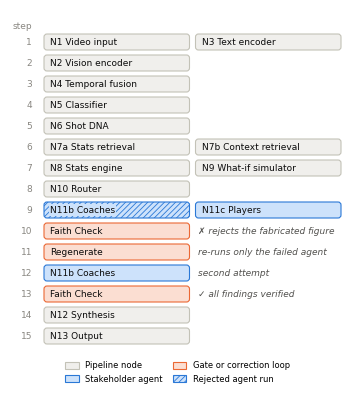

In [123]:
# 14H: draw the run where one agent lies once, and save it for the paper
LIAR     = "n11b_tactical_analysis"
timeline = run_scenario(CLIP, 0.92, lie_once={LIAR})

# find the interesting steps from the recording, not by counting by hand
first_try  = min(step for step, node in timeline if node == LIAR)
regen_step = min(step for step, node in timeline if node == "regen_prep")

fig_path = PROJECT_ROOT / "paper" / "figures" / "fig_execution_trace.pdf"
fig_path.parent.mkdir(parents=True, exist_ok=True)

fig = draw_timeline(
    timeline,
    hatched={(first_try, LIAR)},
    notes={
        first_try + 1:  "\u2717 rejects the fabricated figure",
        regen_step:     "re-runs only the failed agent",
        regen_step + 1: "second attempt",
        regen_step + 2: "\u2713 all findings verified",
    },
    save_to=fig_path,
)

boxes = [p for p in fig.axes[0].patches if isinstance(p, FancyBboxPatch)]
print("steps drawn :", len({step for step, node in timeline}))
print("boxes drawn :", len(boxes), "| node runs recorded:", len(timeline))
print("saved       :", fig_path.relative_to(PROJECT_ROOT),
      f"({fig_path.stat().st_size // 1024} KB)")

# the notes must sit beside the nodes they describe
assert [n for s, n in timeline if s == first_try + 1]  == ["faith_check"]
assert [n for s, n in timeline if s == regen_step + 1] == [LIAR]
assert [n for s, n in timeline if s == regen_step + 2] == ["faith_check"]
assert len(boxes) == len(timeline), "every node run should be exactly one box"
print("OK: one box per node run, notes on the right steps, PDF saved")

### From the notebook to the paper

**No number is typed into the paper by hand.** The table is written to
`paper/tables/tab_execution_profile.tex` from `cost_rows`, the measured
numbers, and the paper pulls it in with `\input`. If the graph changes and a
cost moves, re-running this notebook updates the paper.

The paper uses shorter scenario names than the notebook, so a small dictionary
maps one to the other. It also fixes the row order in the paper.

In [124]:
# Scenario names as they appear in the paper, in the order the paper lists them.
# Left: the name in SCENARIOS. Right: the shorter name for the printed table.
PAPER_ROW_NAMES = {
    "Video, confident":                        "Video, confident",
    "Text-only (no clip)":                     "Text-only",
    "Video, one retry then accept":            "Video, 1 retry",
    "Video, one agent lies once":              "Video, 1 fabrication",
    "Text-only, one agent lies once":          "Text-only, 1 fabrication",
    "Retries used up (degrade)":               "Retries exhausted",
    "Worst case: 2 retries, agents never fix": "Worst case",
}

In [125]:
def write_cost_table(rows: list, path) -> str:
    """Write the cost table as a LaTeX tabular, straight from measured rows.

    Only the tabular is written. The caption stays in the paper, where it can
    be edited freely; the numbers stay here, where they are measured.
    The paper must load the booktabs package (for the three rules).
    Returns the LaTeX text, so it can be printed and checked.
    """
    by_name = {r["scenario"]: r for r in rows}

    lines = [
        "% Generated by notebooks/cricketmind_langgraph_demo.ipynb (test 14I).",
        "% Do not edit by hand -- re-run the notebook instead.",
        r"\begin{tabular}{@{}lrrrrr@{}}",
        r"\toprule",
        r"Scenario & $r$ & $g$ & Steps & \shortstack{Node\\runs} & \shortstack{Agent\\calls} \\",
        r"\midrule",
    ]
    for notebook_name, paper_name in PAPER_ROW_NAMES.items():
        r = by_name[notebook_name]
        lines.append(f"{paper_name} & {r['retries']} & {r['regens']} & {r['steps']} & "
                     f"{r['node_runs']} & {r['agent_calls']} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}"]

    text = "\n".join(lines) + "\n"
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return text

In [126]:
# 14I: write the table for the paper, then read it back and check every number
table_path = PROJECT_ROOT / "paper" / "tables" / "tab_execution_profile.tex"
latex = write_cost_table(cost_rows, table_path)
print(latex)

# every scenario must have a paper name -- a new one must not vanish silently
assert set(PAPER_ROW_NAMES) == {r["scenario"] for r in cost_rows}, \
    "a scenario is missing from PAPER_ROW_NAMES (or a name there is misspelt)"

# read the file back: each data row must hold exactly the measured numbers
by_name   = {r["scenario"]: r for r in cost_rows}
data_rows = [line for line in table_path.read_text(encoding="utf-8").splitlines()
             if line.count("&") == 5 and not line.startswith("Scenario")]
assert len(data_rows) == len(PAPER_ROW_NAMES)

for line, (notebook_name, paper_name) in zip(data_rows, PAPER_ROW_NAMES.items()):
    cells   = [c.strip() for c in line.rstrip("\\ ").split("&")]
    r       = by_name[notebook_name]
    written = [int(c) for c in cells[1:]]
    wanted  = [r["retries"], r["regens"], r["steps"], r["node_runs"], r["agent_calls"]]
    assert cells[0] == paper_name and written == wanted, f"{paper_name}: {written} != {wanted}"

print("saved:", table_path.relative_to(PROJECT_ROOT))
print(f"OK: all {len(data_rows)} rows in the file match the measured numbers")

% Generated by notebooks/cricketmind_langgraph_demo.ipynb (test 14I).
% Do not edit by hand -- re-run the notebook instead.
\begin{tabular}{@{}lrrrrr@{}}
\toprule
Scenario & $r$ & $g$ & Steps & \shortstack{Node\\runs} & \shortstack{Agent\\calls} \\
\midrule
Video, confident & 0 & 0 & 12 & 16 & 2 \\
Text-only & 0 & 0 & 9 & 11 & 1 \\
Video, 1 retry & 1 & 0 & 17 & 21 & 2 \\
Video, 1 fabrication & 0 & 1 & 15 & 19 & 3 \\
Text-only, 1 fabrication & 0 & 1 & 12 & 14 & 2 \\
Retries exhausted & 2 & 0 & 15 & 16 & 0 \\
Worst case & 2 & 2 & 29 & 35 & 6 \\
\bottomrule
\end{tabular}

saved: paper\tables\tab_execution_profile.tex
OK: all 7 rows in the file match the measured numbers


## 15. Routing: which agents answer which question

Different questions need different experts. This section runs a set of prompts
through the graph and records which agents the router wakes, and why.

First, a fix in N3. When a question names two players, N3 used to check the
names in a fixed order -- Kohli first -- so *"What if Rohit faced the attack
instead of Kohli?"* was read as a question about Kohli. N3 now takes the player
named **first in the question**.

In [127]:
# 15A: N3 reads the player the question is about
player_checks = [
    ("What if Rohit faced the pace attack instead of Kohli?", "Rohit"),
    ("Compare Kohli's cover drive vs his pull shot",          "Kohli"),
    ("How does Babar play spin compared with Root?",          "Babar"),
    ("Tell me about this delivery",                           None),
]

TRACE = False
for question, expected in player_checks:
    got = n3_text_encoder({"query": question})["query_filters"].get("player")
    print(f"{str(got):6s} <- {question}")
    assert got == expected, f"expected {expected}, got {got}"
TRACE = True
print()
print("OK: the player named first in the question is the one it is about")

Rohit  <- What if Rohit faced the pace attack instead of Kohli?
Kohli  <- Compare Kohli's cover drive vs his pull shot
Babar  <- How does Babar play spin compared with Root?
None   <- Tell me about this delivery

OK: the player named first in the question is the one it is about


### The prompt set

If every question contained the router's own trigger words, the keyword router
would pass by construction -- it would be graded on questions written for it.
So every stakeholder gets **two questions that ask for the same thing**:

| Style | Example (Medical Teams) |
|---|---|
| **keyword** | "Is Kohli's **workload** a **fatigue** risk before the final?" |
| **plain** | "Is Kohli too tired or sore to play the final safely?" -- none of the trigger words |

Five **tricky** prompts are added on purpose: one with no signal at all, one
that names many stakeholders at once, the running example, and two with no clip.

`target` is the stakeholder each question was *written for*. It describes the
prompt; it is not ground truth, because we wrote both the questions and the
keywords.

In [128]:
# The prompts for the routing experiment. Each entry:
#   id      short name used in tables, e.g. "k-plain" = Medical Teams, plain wording
#   target  the agent the question was written for (None for tricky prompts)
#   style   "keyword", "plain" or "tricky"
#   clip    CLIP, or None for a text-only question
#   prompt  the question itself
# Every prompt is about Kohli (or no named player): the fake database holds only
# Kohli's deliveries, and a player with no data is not handled yet.
ROUTING_PROMPTS = [
    # a -- Franchises / Boards
    {"id": "a-keyword", "target": "n11a_club_operations", "style": "keyword", "clip": CLIP,
     "prompt": "Should we keep Kohli in the squad or release him before the auction?"},
    {"id": "a-plain",   "target": "n11a_club_operations", "style": "plain",   "clip": CLIP,
     "prompt": "Should our team keep Kohli next season, or let him go to save money?"},
    # b -- Coaches
    {"id": "b-keyword", "target": "n11b_tactical_analysis", "style": "keyword", "clip": CLIP,
     "prompt": "What field should we set to exploit Kohli's weakness against spin?"},
    {"id": "b-plain",   "target": "n11b_tactical_analysis", "style": "plain",   "clip": CLIP,
     "prompt": "How do we get Kohli out early when he faces spin?"},
    # c -- Players
    {"id": "c-keyword", "target": "n11c_personal_performance", "style": "keyword", "clip": CLIP,
     "prompt": "How is Kohli's technique on the cover drive trending this season?"},
    {"id": "c-plain",   "target": "n11c_personal_performance", "style": "plain",   "clip": CLIP,
     "prompt": "Has Kohli's batting got better or worse this season, and what should he change?"},
    # d -- Scouts
    {"id": "d-keyword", "target": "n11d_global_scouting", "style": "keyword", "clip": CLIP,
     "prompt": "Which emerging batters in other leagues play the pull shot like Kohli?"},
    {"id": "d-plain",   "target": "n11d_global_scouting", "style": "plain",   "clip": CLIP,
     "prompt": "Find young overseas batters who could become the next Kohli."},
    # e -- Fans
    {"id": "e-keyword", "target": "n11e_fan_concierge", "style": "keyword", "clip": CLIP,
     "prompt": "Should I pick Kohli as my fantasy captain for the next match?"},
    {"id": "e-plain",   "target": "n11e_fan_concierge", "style": "plain",   "clip": CLIP,
     "prompt": "I want to watch Kohli bat live; which home game should I go to?"},
    # f -- Stadiums
    {"id": "f-keyword", "target": "n11f_stadium_operations", "style": "keyword", "clip": CLIP,
     "prompt": "Should the curator prepare a greener pitch to trouble Kohli against pace?"},
    {"id": "f-plain",   "target": "n11f_stadium_operations", "style": "plain",   "clip": CLIP,
     "prompt": "How should the ground staff get the wicket ready if we want Kohli to struggle?"},
    # g -- Sponsors
    {"id": "g-keyword", "target": "n11g_sponsorship_intelligence", "style": "keyword", "clip": CLIP,
     "prompt": "Which sponsor brand gets the most logo visibility when Kohli plays the cover drive?"},
    {"id": "g-plain",   "target": "n11g_sponsorship_intelligence", "style": "plain",   "clip": CLIP,
     "prompt": "Is paying to put our company name on Kohli's bat good value for money?"},
    # h -- Broadcasters
    {"id": "h-keyword", "target": "n11h_content_production", "style": "keyword", "clip": CLIP,
     "prompt": "Make a highlight clip with a wagon wheel overlay of Kohli's pull shots"},
    {"id": "h-plain",   "target": "n11h_content_production", "style": "plain",   "clip": CLIP,
     "prompt": "What on-screen visuals should the TV team show when Kohli walks out to bat?"},
    # i -- Governing Bodies
    {"id": "i-keyword", "target": "n11i_compliance", "style": "keyword", "clip": CLIP,
     "prompt": "Does Kohli's bat meet ICC eligibility rules?"},
    {"id": "i-plain",   "target": "n11i_compliance", "style": "plain",   "clip": CLIP,
     "prompt": "Did Kohli break any of the game's official regulations in this innings?"},
    # j -- Academies
    {"id": "j-keyword", "target": "n11j_talent_development", "style": "keyword", "clip": CLIP,
     "prompt": "Design an academy drill so U-19 batters learn the cover drive"},
    {"id": "j-plain",   "target": "n11j_talent_development", "style": "plain",   "clip": CLIP,
     "prompt": "How can we teach teenage batters to hit the ball through the covers like Kohli?"},
    # k -- Medical Teams
    {"id": "k-keyword", "target": "n11k_injury_management", "style": "keyword", "clip": CLIP,
     "prompt": "Is Kohli's workload a fatigue risk before the final?"},
    {"id": "k-plain",   "target": "n11k_injury_management", "style": "plain",   "clip": CLIP,
     "prompt": "Is Kohli too tired or sore to play the final safely?"},
    # l -- Player Agents / Managers
    {"id": "l-keyword", "target": "n11l_player_representation", "style": "keyword", "clip": CLIP,
     "prompt": "What is Kohli's market valuation before the auction?"},
    {"id": "l-plain",   "target": "n11l_player_representation", "style": "plain",   "clip": CLIP,
     "prompt": "How much money should Kohli ask for in his next deal?"},
    # tricky prompts -- no single intended stakeholder
    {"id": "no-signal",       "target": None, "style": "tricky", "clip": CLIP,
     "prompt": "Tell me about this delivery"},
    {"id": "many-asked",      "target": None, "style": "tricky", "clip": CLIP,
     "prompt": "Scout, sponsor, injury, broadcast, fantasy and auction view of Kohli's drive"},
    {"id": "running-example", "target": None, "style": "tricky", "clip": CLIP,
     "prompt": QUERY},
    {"id": "text-compare",    "target": None, "style": "tricky", "clip": None,
     "prompt": "Compare Kohli's cover drive and pull shot against pace in the powerplay"},
    {"id": "text-academy",    "target": None, "style": "tricky", "clip": None,
     "prompt": "Design an academy drill so U-19 batters learn the cover drive"},
]
print(len(ROUTING_PROMPTS), "prompts")

29 prompts


In [129]:
# 15B: the prompt set is built the way the table above says
TRACE = False
print(f"{'id':16s} {'target keywords found in the prompt'}")
print("-" * 60)
for p in ROUTING_PROMPTS:
    q = p["prompt"].lower()

    # keyword prompts must use the target's trigger words; plain ones must avoid them
    if p["target"]:
        kw_found = [k for k in AGENTS_BY_ID[p["target"]]["keywords"] if k in q]
        print(f"{p['id']:16s} {kw_found or '-'}")
        if p["style"] == "keyword":
            assert kw_found, f"{p['id']}: a keyword prompt must use the target's keywords"
        else:
            assert not kw_found, f"{p['id']}: a plain prompt must not use {kw_found}"

    # every prompt must be answerable with the data we have
    parsed = n3_text_encoder({"query": p["prompt"]})["query_filters"]
    assert parsed.get("player") in (None, "Kohli"), f"{p['id']}: no data for {parsed['player']}"
    if p["clip"] is None:
        assert parsed.get("shots"), f"{p['id']}: a text-only prompt must name a shot"
TRACE = True

styles = [p["style"] for p in ROUTING_PROMPTS]
targets = {p["target"] for p in ROUTING_PROMPTS if p["target"]}
print()
print(f"keyword {styles.count('keyword')} | plain {styles.count('plain')} | tricky {styles.count('tricky')}")
assert targets == set(AGENTS_BY_ID), "every agent must have its own prompts"
assert styles.count("keyword") == styles.count("plain") == 12
print("OK: 12 keyword + 12 plain prompts, one pair per agent; all answerable")

id               target keywords found in the prompt
------------------------------------------------------------
a-keyword        ['auction', 'squad']
a-plain          -
b-keyword        ['field', 'weakness']
b-plain          -
c-keyword        ['technique', 'drive', 'trend']
c-plain          -
d-keyword        ['emerging', 'league']
d-plain          -
e-keyword        ['fan', 'fantasy']
e-plain          -
f-keyword        ['curator']
f-plain          -
g-keyword        ['sponsor', 'brand', 'logo', 'visibility']
g-plain          -
h-keyword        ['overlay', 'wagon wheel', 'clip', 'highlight']
h-plain          -
i-keyword        ['eligibility', 'icc']
i-plain          -
j-keyword        ['academy', 'u-19', 'drill']
j-plain          -
k-keyword        ['workload', 'fatigue']
k-plain          -
l-keyword        ['valuation', 'market']
l-plain          -

keyword 12 | plain 12 | tricky 5
OK: 12 keyword + 12 plain prompts, one pair per agent; all answerable


### The routing table

Each prompt runs through the **whole graph**, so the router sees exactly what it
would see in use: the query, the Shot DNA and the engine results. For every
agent it wakes we keep the router's own reason.

A target agent can be woken for two different reasons, and they must not be
counted together:

| Woken by | Meaning |
|---|---|
| **signal** | the router found evidence for that agent in this query |
| **default** | nothing matched, so the router fell back to its default pair (Coaches, Players) |

A target woken by default is a lucky guess, not understanding.

In [130]:
def route_prompt(p: dict) -> dict:
    """Run one prompt through the whole graph and record the router's choice.

    p is one entry of ROUTING_PROMPTS. The clip is always classified
    confidently and no agent lies, so the only thing that varies is the
    question. Settings are put back afterwards, as in run_scenario.
    Whichever router ROUTER_MODE selects is the one recorded.

    Returns a row: the prompt's id, style and target; which router ran; the
    agents it proposed, the ones the rules removed, and the ones woken; a
    reason for each woken agent -- the keyword evidence, "llm", or "default";
    and how the target was woken: "signal", "default", "no", or None for
    prompts without a target.
    """
    global TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS
    saved = (TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)
    TRACE, STUB_CONFIDENCE = False, 0.92
    HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), set()
    try:
        final = cricketmind.invoke(new_state(p["clip"], p["prompt"]))
    finally:
        TRACE, STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = saved

    info  = final["routing_info"]
    woken = final["active_agents"]

    if info["defaulted"]:                     # nobody proposed survived the rules
        why = {a: "default" for a in woken}
    elif info["router"] == "llm":             # the model's single reason covers them all
        why = {a: "llm" for a in woken}
    else:                                     # the keyword scorer's evidence, per agent
        scored = _score_agents(final)
        why = {a: "; ".join(r.replace("query mentions ", "") for r in scored[a][1])
               for a in woken}

    if p["target"] is None:
        target_woken = None
    elif p["target"] not in woken:
        target_woken = "no"
    elif why[p["target"]] == "default":
        target_woken = "default"
    else:
        target_woken = "signal"

    return {"id": p["id"], "style": p["style"], "target": p["target"],
            "clip": p["clip"], "status": final["status"],
            "router": info["router"], "proposed": info["proposed"],
            "blocked": info["blocked"], "reason": info["reason"],
            "seconds": info["seconds"],
            "woken": woken, "why": why, "target_woken": target_woken}


In [131]:
def agent_name(agent_id: str) -> str:
    """Short stakeholder name for tables: "Franchises / Boards" -> "Franchises"."""
    return AGENTS_BY_ID[agent_id]["stakeholder"].split(" /")[0]

In [132]:
# 15C: the keyword router on all 29 prompts
from collections import Counter

keyword_routing = [route_prompt(p) for p in ROUTING_PROMPTS]

print(f"{'id':16s} {'target':8s} agents woken [why]")
print("-" * 100)
for r in keyword_routing:
    agents = ", ".join(f"{agent_name(a)} [{r['why'][a]}]" for a in r["woken"])
    print(f"{r['id']:16s} {r['target_woken'] or '':8s} {agents}")

# how many prompts of each style had their target woken, and how
tally = Counter((r["style"], r["target_woken"]) for r in keyword_routing)

mean_woken = sum(len(r["woken"]) for r in keyword_routing) / len(keyword_routing)
defaulted  = sum(1 for r in keyword_routing if all(w == "default" for w in r["why"].values()))
print()
print(f"keyword prompts: target woken by signal {tally['keyword', 'signal']:2d}/12")
print(f"plain prompts  : target woken by signal {tally['plain', 'signal']:2d}/12"
      f"   (+{tally['plain', 'default']} only because the default pair contained it)")
print(f"fell back to the default pair: {defaulted} of {len(keyword_routing)} prompts")
print(f"agents woken per prompt: mean {mean_woken:.2f} of {len(AGENT_REGISTRY)} "
      f"-> {1 - mean_woken / len(AGENT_REGISTRY):.0%} fewer agent calls than waking all")

# sanity checks on the router's rules -- these are guarantees, not results
posture_agents = {a["id"] for a in AGENT_REGISTRY if "weight_transfer" in a["cites"]}
for r in keyword_routing:
    assert r["status"] == "ok", f"{r['id']}: run did not finish cleanly"
    assert 1 <= len(r["woken"]) <= MAX_ACTIVE_AGENTS, f"{r['id']}: woke {len(r['woken'])}"
    if r["clip"] is None:
        assert not set(r["woken"]) & posture_agents, f"{r['id']}: woke an agent with no posture"
assert tally["keyword", "signal"] == 12, "a keyword prompt did not wake its own target"
print()
print("OK: every run finished, the cap and the evidence rule held on all 29 prompts")

id               target   agents woken [why]
----------------------------------------------------------------------------------------------------
a-keyword        signal   Franchises [auction, squad]
a-plain          no       Coaches [default], Players [default]
b-keyword        signal   Coaches [field, weakness]
b-plain          default  Coaches [default], Players [default]
c-keyword        signal   Players [technique, drive, trend]
c-plain          default  Coaches [default], Players [default]
d-keyword        signal   Players [shot, pull], Scouts [emerging, league]
d-plain          no       Coaches [default], Players [default]
e-keyword        signal   Fans [fan, fantasy]
e-plain          no       Coaches [default], Players [default]
f-keyword        signal   Stadiums [curator]
f-plain          no       Coaches [default], Players [default]
g-keyword        signal   Sponsors [sponsor, brand, logo, visibility], Players [drive]
g-plain          no       Coaches [default], Players [defa

### A prompt's journey through the graph

`record_run` recorded **which** node ran. Here we record **what each node
wrote** into the shared state, using `stream_mode="updates"`: every event is
`{node_name: the dictionary that node returned}`.

`describe_write` turns each of those dictionaries into one short line a person
can read. Two questions are then shown side by side, stage by stage -- the same
pipeline, different evidence, different experts.

In [133]:
def record_writes(state: CricketMindState) -> list:
    """Run one query and record what every node wrote into the state.

    Like record_run, but with stream_mode="updates": each event is
    {node_name: the dictionary that node returned}. Returns (node, update)
    pairs in the order the nodes finished.
    """
    writes = []
    for event in cricketmind.stream(state, stream_mode="updates"):
        for node, update in event.items():
            writes.append((node, update or {}))
    return writes

In [134]:
def describe_write(node: str, update: dict) -> str:
    """One short, readable line for what a node wrote."""
    u = update
    if node == "n1_video_input":
        return f"{len(u['frames'])} frames sampled"
    if node in ("n2_vision_encoder", "n4_temporal_fusion"):
        key = "frame_features" if node == "n2_vision_encoder" else "temporal_features"
        return f"features {u[key].shape}"
    if node == "n3_text_encoder":
        parts = [f"{k}={'+'.join(v) if isinstance(v, list) else v}"
                 for k, v in u["query_filters"].items()]
        return ", ".join(parts) or "no filters"
    if node == "n5_classifier_head":
        return f"{u['shot_label']} (p={u['shot_confidence']:.2f})"
    if node == "n6_shot_dna":
        dna = u["shot_dna"]
        if dna["posture"]:
            return f"{dna['shot']} + posture (weight transfer {dna['posture']['weight_transfer']}) + filters"
        return "query filters only (no clip)"
    if node == "n7a_stats_retrieval":
        return f"{len(u['stats_hits'])} matching deliveries"
    if node == "n7b_context_retrieval":
        return f"{len(u['context_hits'])} context rows"
    if node == "n8_stats_engine":
        return ", ".join(f"{shot} SR {s['strike_rate']} ({s['balls']} balls)"
                         for shot, s in u["stats_results"]["by_shot"].items())
    if node == "n9_whatif_simulator":
        s = u["sim_results"]
        lo, hi = s["ci95"]
        return f"{s['scenario']}: {s['p_dismissal']:.1%} out (95% CI {lo:.1%}-{hi:.1%})"
    if node == "n10_supervisor_router":
        return "wakes " + ", ".join(agent_name(a) for a in u["active_agents"])
    if node in AGENTS_BY_ID:
        f = u["agent_findings"][0]
        return f"{agent_name(node)} cites {f['cites']}"
    if node == "faith_check":
        n = len(u["faith_failures"])
        return "all cited figures match the engines" if n == 0 else f"{n} citation(s) rejected"
    if node == "n12_supervisor_synthesis":
        return f"report written ({len(u['report'].splitlines())} lines)"
    if node == "n13_final_output":
        return f"status = {u['status']}"
    return "wrote " + ", ".join(u) if u else "wrote nothing"

In [135]:
# 15E: two questions, side by side, stage by stage
FLOW_PROMPTS = {
    "A": QUERY,                                                  # a coaching comparison
    "B": "Is Kohli's workload a fatigue risk before the final?",  # a medical question
}

# the stages to show, and which nodes each stage covers
FLOW_STAGES = [
    ("N3 reads the question",   ["n3_text_encoder"]),
    ("N1-N5 classify the clip", ["n5_classifier_head"]),
    ("N6 builds the Shot DNA",  ["n6_shot_dna"]),
    ("N7a finds deliveries",    ["n7a_stats_retrieval"]),
    ("N7b finds context",       ["n7b_context_retrieval"]),
    ("N8 computes statistics",  ["n8_stats_engine"]),
    ("N9 simulates",            ["n9_whatif_simulator"]),
    ("N10 picks the experts",   ["n10_supervisor_router"]),
    ("N11 agents answer",       list(AGENTS_BY_ID)),
    ("Faith Check",             ["faith_check"]),
    ("N13 output",              ["n13_final_output"]),
]

assert (STUB_CONFIDENCE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS) == (0.92, set(), set()), \
    "an earlier cell left a setting changed"
TRACE = False
flow_writes = {label: record_writes(new_state(CLIP, q)) for label, q in FLOW_PROMPTS.items()}
TRACE = True

for label, q in FLOW_PROMPTS.items():
    print(f"{label}: {q}")
for stage, nodes in FLOW_STAGES:
    print()
    print(stage)
    for label, writes in flow_writes.items():
        stage_lines = [describe_write(node, upd) for node, upd in writes if node in nodes]
        print(f"   {label}: {' | '.join(stage_lines) or '-'}")

# the point of the table: one pipeline, different evidence, different experts
flow_woken  = {label: next(u["active_agents"] for n, u in writes if n == "n10_supervisor_router")
               for label, writes in flow_writes.items()}
flow_hits   = {label: next(len(u["stats_hits"]) for n, u in writes if n == "n7a_stats_retrieval")
               for label, writes in flow_writes.items()}
flow_status = {label: next(u["status"] for n, u in writes if n == "n13_final_output")
               for label, writes in flow_writes.items()}
print()
assert flow_status == {"A": "ok", "B": "ok"}
assert not set(flow_woken["A"]) & set(flow_woken["B"]), "the two questions should wake different experts"
assert flow_hits["A"] != flow_hits["B"], "the two questions should retrieve different evidence"
print("OK: same pipeline, different evidence and different experts for each question")

A: Compare Kohli's cover drive vs his pull shot against fast bowlers in the powerplay
B: Is Kohli's workload a fatigue risk before the final?

N3 reads the question
   A: bowler_type=pace, phase=powerplay, player=Kohli, shots=Cover Drive+Pull
   B: player=Kohli

N1-N5 classify the clip
   A: Cover Drive (p=0.92)
   B: Cover Drive (p=0.92)

N6 builds the Shot DNA
   A: Cover Drive + posture (weight transfer 0.88) + filters
   B: Cover Drive + posture (weight transfer 0.88) + filters

N7a finds deliveries
   A: 100 matching deliveries
   B: 80 matching deliveries

N7b finds context
   A: 4 context rows
   B: 4 context rows

N8 computes statistics
   A: Cover Drive SR 142.0 (50 balls), Pull SR 112.0 (50 balls)
   B: Cover Drive SR 130.0 (80 balls)

N9 simulates
   A: 6 consecutive deliveries targeting the pull: 39.4% out (95% CI 38.7%-40.1%)
   B: 6 consecutive deliveries targeting the cover drive: 13.9% out (95% CI 13.4%-14.4%)

N10 picks the experts
   A: wakes Players, Coaches
   B: wa

## 16. A language-model router

The keyword router only sees its trigger words, so it failed every plain
question. Here N10 gets a real language model: **Qwen2.5-7B**, running locally
through **Ollama**.

**Fairness.** The model is told about each agent using exactly what the keyword
router knows -- the stakeholder name and its keyword list, read from
`AGENT_REGISTRY`. No extra descriptions are written for it. If it does better
on plain questions, the only difference is that it reads meaning, not words.

**Fixed answer shape.** Ollama forces the reply into a JSON shape: a one-sentence
reason, then 1 to 4 agent ids taken from a fixed list. The model cannot invent
an agent or wake more than the cap.

**Both machines.** The notebook only talks to Ollama at `localhost`; Ollama
decides how to use the GPU. The same code runs on the Arc and the RTX machine,
as long as the model is installed on each (`ollama pull qwen2.5:7b`).

In [136]:
# LLM router settings
import time
import urllib.request

OLLAMA_URL   = "http://localhost:11434"
ROUTER_MODEL = "qwen2.5:7b"
# ROUTER_MODE ("keyword" or "llm") is set next to MAX_ACTIVE_AGENTS, before N10.

In [137]:
def ollama_ready() -> bool:
    """True if Ollama is running and ROUTER_MODEL is installed."""
    try:
        with urllib.request.urlopen(f"{OLLAMA_URL}/api/tags", timeout=3) as reply:
            installed = [m["name"] for m in json.load(reply)["models"]]
    except OSError:                  # not running, refused, timed out
        return False
    return ROUTER_MODEL in installed

In [138]:
def llm_route(query: str) -> dict:
    """Ask the local language model which agents should answer a query.

    The model sees each agent's id, stakeholder name and keyword list -- the
    same knowledge the keyword router has. Its reply is forced into a JSON
    shape: a short reason, then 1 to MAX_ACTIVE_AGENTS ids from the registry.
    temperature 0 and a fixed seed make repeated calls as stable as possible.

    Returns {"reason": str, "agents": [agent ids], "seconds": float}.
    Raises OSError if Ollama cannot be reached -- the caller decides what to do.
    """
    roster = "\n".join(f"- {a['id']}: {a['stakeholder']} (topics: {', '.join(a['keywords'])})"
                       for a in AGENT_REGISTRY)
    system = ("You route questions about cricket to expert agents. Choose only the agents "
              "whose expertise the question actually needs. Judge by what the question "
              "means, not by the exact words it uses. Answer with a one-sentence reason "
              "that explains your choice, then the list of agents.\n\nAgents:\n" + roster)

    schema = {                                  # the only shape Ollama will let it answer in
        "type": "object",
        "properties": {
            "reason": {"type": "string"},
            "agents": {"type": "array", "minItems": 1, "maxItems": MAX_ACTIVE_AGENTS,
                       "items": {"type": "string", "enum": list(AGENTS_BY_ID)}},
        },
        "required": ["reason", "agents"],
    }
    body = {"model": ROUTER_MODEL, "stream": False, "format": schema,
            "options": {"temperature": 0, "seed": SEED},
            "messages": [{"role": "system", "content": system},
                         {"role": "user",   "content": query}]}

    request = urllib.request.Request(f"{OLLAMA_URL}/api/chat",
                                     data=json.dumps(body).encode("utf-8"),
                                     headers={"Content-Type": "application/json"})
    start = time.perf_counter()
    with urllib.request.urlopen(request, timeout=300) as reply:
        message = json.load(reply)["message"]["content"]
    answer = json.loads(message)

    answer["agents"]  = list(dict.fromkeys(answer["agents"]))   # drop repeats, keep order
    answer["seconds"] = time.perf_counter() - start
    return answer

In [139]:
# 15F: the local model answers in the required shape
if not ollama_ready():
    print(f"SKIPPED: Ollama is not running, or {ROUTER_MODEL} is not installed.")
    print(f"Start Ollama, then run once:  ollama pull {ROUTER_MODEL}")
else:
    valid_ids = set(AGENTS_BY_ID)
    for pid in ("k-plain", "a-plain"):
        p = next(x for x in ROUTING_PROMPTS if x["id"] == pid)
        llm_answer = llm_route(p["prompt"])
        print(f"{pid}: {p['prompt']}")
        print(f"   written for: {agent_name(p['target'])}")
        print(f"   LLM chose  : {[agent_name(a) for a in llm_answer['agents']]}")
        print(f"   reason     : {llm_answer['reason']}")
        print(f"   time       : {llm_answer['seconds']:.1f} s")
        print()
        assert set(llm_answer["agents"]) <= valid_ids
        assert 1 <= len(llm_answer["agents"]) <= MAX_ACTIVE_AGENTS
    print("OK: the model answers with 1-4 real agent ids and a reason")

k-plain: Is Kohli too tired or sore to play the final safely?
   written for: Medical Teams
   LLM chose  : ['Medical Teams', 'Players']
   reason     : The question is about a player's physical condition, so it requires an expert in injury management or a player's personal performance.
   time       : 3.0 s

a-plain: Should our team keep Kohli next season, or let him go to save money?
   written for: Franchises
   LLM chose  : ['Franchises', 'Players', 'Player Agents']
   reason     : The question is about the financial and strategic decision regarding a player's contract, which involves budget and contract topics.
   time       : 3.1 s

OK: the model answers with 1-4 real agent ids and a reason


In [140]:
# 16A: the LLM proposes, the rules decide
saved_mode, saved_url = ROUTER_MODE, OLLAMA_URL
try:
    # (a) keyword mode still routes all 29 prompts exactly as in 15C
    assert ROUTER_MODE == "keyword"
    keyword_again = [route_prompt(p) for p in ROUTING_PROMPTS]
    assert [r["woken"] for r in keyword_again] == [r["woken"] for r in keyword_routing]
    print("(a) keyword mode: all 29 prompts routed exactly as in 15C")
    print()

    # (b) LLM mode: the model proposes, the evidence rule still removes agents
    #     whose facts do not exist (no clip -> no posture -> no Players, Academies)
    if ollama_ready():
        ROUTER_MODE = "llm"
        for pid in ("k-plain", "text-academy"):
            p = next(x for x in ROUTING_PROMPTS if x["id"] == pid)
            TRACE = False
            run16 = cricketmind.invoke(new_state(p["clip"], p["prompt"]))
            TRACE = True
            info = run16["routing_info"]
            print(f"(b) {pid} ({'video' if p['clip'] else 'no clip'}): {p['prompt']}")
            print(f"    LLM proposed : {', '.join(agent_name(a) for a in info['proposed'])}")
            print(f"    rules removed: {', '.join(agent_name(a) for a in info['blocked']) or '-'}")
            print(f"    woken        : {', '.join(agent_name(a) for a in run16['active_agents'])}"
                  + ("   (default pair)" if info["defaulted"] else ""))
            print(f"    reason       : {info['reason']}")
            print()
            assert info["router"] == "llm"
            assert not set(run16["active_agents"]) & set(info["blocked"])
            assert set(run16["active_agents"]) <= set(info["proposed"]) | set(DEFAULT_AGENTS)
            assert len(run16["active_agents"]) <= MAX_ACTIVE_AGENTS
            assert run16["status"] == "ok"
        ROUTER_MODE = saved_mode
    else:
        print("(b) SKIPPED: Ollama is not running")
        print()

    # (c) Ollama unreachable: fall back to the keyword router, and say so
    ROUTER_MODE, OLLAMA_URL = "llm", "http://localhost:9"     # nothing listens here
    p = next(x for x in ROUTING_PROMPTS if x["id"] == "k-keyword")
    TRACE = False
    run16 = cricketmind.invoke(new_state(p["clip"], p["prompt"]))
    TRACE = True
    expected_woken = next(r["woken"] for r in keyword_routing if r["id"] == "k-keyword")
    print(f"(c) Ollama unreachable -> router = {run16['routing_info']['router']!r}, "
          f"woken = {[agent_name(a) for a in run16['active_agents']]}")
    assert run16["routing_info"]["router"] == "keyword (LLM unavailable)"
    assert run16["active_agents"] == expected_woken
finally:
    ROUTER_MODE, OLLAMA_URL, TRACE = saved_mode, saved_url, True

print()
print("OK: keyword routing unchanged; LLM proposals pass through the same rules; "
      "a missing LLM falls back and is recorded")

(a) keyword mode: all 29 prompts routed exactly as in 15C

(b) k-plain (video): Is Kohli too tired or sore to play the final safely?
    LLM proposed : Medical Teams, Players
    rules removed: -
    woken        : Medical Teams, Players
    reason       : The question is about a player's physical condition, so it requires an expert in injury management or a player's personal performance.

(b) text-academy (no clip): Design an academy drill so U-19 batters learn the cover drive
    LLM proposed : Players, Academies
    rules removed: Players, Academies
    woken        : Coaches   (default pair)
    reason       : The question is about designing a training drill for U-19 batters, which falls under the topic of player development and technique.

(c) Ollama unreachable -> router = 'keyword (LLM unavailable)', woken = ['Medical Teams']

OK: keyword routing unchanged; LLM proposals pass through the same rules; a missing LLM falls back and is recorded


### Keyword router vs LLM router

The same 29 prompts, now routed by the language model. Each prompt is asked
**three times**: temperature 0 and a fixed seed should make the answers
identical, and the experiment checks that rather than assuming it.

87 model calls take a few minutes, so the answers are **saved** to
`experiments/routing/llm_routing_runs.json`. Later runs reuse the file as long
as the model and the prompts are unchanged. Set `RERUN_LLM = True` to ask the
model again -- for example after changing the instructions in `llm_route`.

In [141]:
# 16B: route all 29 prompts with the LLM, three times each (or load the saved answers)
LLM_RUNS    = 3
LLM_RESULTS = PROJECT_ROOT / "experiments" / "routing" / "llm_routing_runs.json"
RERUN_LLM   = False        # True = ask the model again even if saved answers exist

# the saved answers are only valid for this exact setup
llm_setup = {"model": ROUTER_MODEL, "runs": LLM_RUNS,
             "prompts": [[p["id"], p["prompt"]] for p in ROUTING_PROMPTS]}
saved_file = json.loads(LLM_RESULTS.read_text(encoding="utf-8")) if LLM_RESULTS.exists() else None

llm_runs = None
if saved_file and saved_file["setup"] == llm_setup and not RERUN_LLM:
    llm_runs = saved_file["runs"]
    print(f"loaded saved answers: {LLM_RESULTS.relative_to(PROJECT_ROOT)}")
elif ollama_ready():
    saved_mode = ROUTER_MODE
    ROUTER_MODE = "llm"
    try:
        llm_runs = []
        for run in range(LLM_RUNS):
            start = time.perf_counter()
            llm_runs.append([route_prompt(p) for p in ROUTING_PROMPTS])
            print(f"run {run + 1}/{LLM_RUNS}: {time.perf_counter() - start:.0f} s")
    finally:
        ROUTER_MODE = saved_mode
    LLM_RESULTS.parent.mkdir(parents=True, exist_ok=True)
    LLM_RESULTS.write_text(json.dumps({"setup": llm_setup, "runs": llm_runs}, indent=1),
                           encoding="utf-8")
    print(f"saved: {LLM_RESULTS.relative_to(PROJECT_ROOT)}")
else:
    print(f"SKIPPED: Ollama is not running and no saved answers match this setup.")

if llm_runs is not None:
    posture_agents = {a["id"] for a in AGENT_REGISTRY if "weight_transfer" in a["cites"]}
    for run in llm_runs:
        for r in run:
            assert r["router"] == "llm", f"{r['id']}: fell back to {r['router']!r}"
            assert r["status"] == "ok", f"{r['id']}: run did not finish cleanly"
            assert 1 <= len(r["woken"]) <= MAX_ACTIVE_AGENTS
            if r["clip"] is None:
                assert not set(r["woken"]) & posture_agents, f"{r['id']}: woke an agent with no posture"
    print(f"OK: {LLM_RUNS} x {len(ROUTING_PROMPTS)} LLM-routed runs; "
          "every one used the LLM and obeyed the cap and the evidence rule")

loaded saved answers: experiments\routing\llm_routing_runs.json
OK: 3 x 29 LLM-routed runs; every one used the LLM and obeyed the cap and the evidence rule


In [142]:
# 16C: keyword router vs LLM router, prompt by prompt and in total
if llm_runs is None:
    print("SKIPPED: no LLM answers available (see 16B)")
else:
    first_run = llm_runs[0]
    # a prompt is stable if every run woke exactly the same agents
    stable = [all(run[i]["woken"] == first_run[i]["woken"] for run in llm_runs)
              for i in range(len(ROUTING_PROMPTS))]

    MARK = {"signal": "+", "default": "~", "no": "x", None: " "}   # how the target was woken
    print("target woken:  + by the router's own choice   ~ only by the default pair   x not woken")
    print()
    print(f"{'id':16s}   {'keyword router':34s}   {'LLM router (run 1)':34s} same in all runs")
    print("-" * 106)
    for kw, llm, same in zip(keyword_routing, first_run, stable):
        kw_agents  = ", ".join(agent_name(a) for a in kw["woken"])[:34]
        llm_agents = ", ".join(agent_name(a) for a in llm["woken"])[:34]
        print(f"{kw['id']:16s} {MARK[kw['target_woken']]} {kw_agents:34s} "
              f"{MARK[llm['target_woken']]} {llm_agents:34s} {'yes' if same else 'NO'}")

    # totals: the keyword router is deterministic, so one number; the LLM gets one per run
    per_run = {
        "keyword prompts, target woken by the router":
            ([sum(r["style"] == "keyword" and r["target_woken"] == "signal" for r in keyword_routing)],
             [sum(r["style"] == "keyword" and r["target_woken"] == "signal" for r in run) for run in llm_runs]),
        "plain prompts, target woken by the router":
            ([sum(r["style"] == "plain" and r["target_woken"] == "signal" for r in keyword_routing)],
             [sum(r["style"] == "plain" and r["target_woken"] == "signal" for r in run) for run in llm_runs]),
        "prompts that fell back to the default pair":
            ([sum(all(w == "default" for w in r["why"].values()) for r in keyword_routing)],
             [sum(all(w == "default" for w in r["why"].values()) for r in run) for run in llm_runs]),
        "agents woken per prompt (mean)":
            ([sum(len(r["woken"]) for r in keyword_routing) / len(keyword_routing)],
             [sum(len(r["woken"]) for r in run) / len(run) for run in llm_runs]),
    }
    print()
    print(f"{'':44s} {'keyword':>8s} {'LLM':>12s}")
    for label, (kw_vals, llm_vals) in per_run.items():
        as_text = [f"{v:.2f}" if isinstance(v, float) else str(v) for v in llm_vals]
        llm_text = as_text[0] if len(set(as_text)) == 1 else f"{min(as_text)}-{max(as_text)}"
        kw_text  = f"{kw_vals[0]:.2f}" if isinstance(kw_vals[0], float) else str(kw_vals[0])
        print(f"{label:44s} {kw_text:>8s} {llm_text:>12s}")

    seconds = [r["seconds"] for run in llm_runs for r in run]
    print(f"{'prompts routed identically in every run':44s} {'-':>8s} {f'{sum(stable)}/{len(stable)}':>12s}")
    print(f"{'LLM routing time per prompt (mean)':44s} {'-':>8s} {f'{sum(seconds) / len(seconds):.1f} s':>12s}")

    assert len(first_run) == len(keyword_routing)
    print()
    print("OK: both routers compared on the same 29 prompts")

target woken:  + by the router's own choice   ~ only by the default pair   x not woken

id                 keyword router                       LLM router (run 1)                 same in all runs
----------------------------------------------------------------------------------------------------------
a-keyword        + Franchises                         + Franchises                         yes
a-plain          x Coaches, Players                   + Franchises, Players, Player Agents yes
b-keyword        + Coaches                            + Coaches                            yes
b-plain          ~ Coaches, Players                   x Players                            yes
c-keyword        + Players                            + Players                            yes
c-plain          ~ Coaches, Players                   + Players                            yes
d-keyword        + Players, Scouts                    + Scouts                             yes
d-plain          x Coaches, Play

### Routing tables for the paper

As with the cost table, no number is typed into the paper by hand. Three
tables are written to `paper/tables/`:

| File | Content |
|---|---|
| `tab_routing_summary.tex` | keyword router vs LLM router, the totals from 16C |
| `tab_routing_plain.tex` | the twelve plain prompts and the agents the LLM activated |
| `tab_prompt_flow.tex` | the two questions of 15E, stage by stage |

The paper needs `\usepackage{booktabs}` and `\usepackage{array}`. The last two
tables are meant for a two-column-wide `table*`.

In [143]:
def latex_escape(text: str) -> str:
    """Make plain text safe inside a LaTeX table: & % $ # _ { } ~ ^ \ are special."""
    special = {"\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
               "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}",
               "~": r"\textasciitilde{}", "^": r"\textasciicircum{}"}
    return "".join(special.get(ch, ch) for ch in str(text))

In [144]:
def write_routing_summary(per_run: dict, stable: list, seconds: list, path) -> str:
    """Write the keyword-vs-LLM summary table from the numbers test 16C computed.

    per_run maps a 16C label to (keyword values, LLM values -- one per run).
    If the LLM runs disagree, the cell shows the range, e.g. "8/12--9/12".
    """
    styles = Counter(p["style"] for p in ROUTING_PROMPTS)
    rows = [   # (label in 16C, label in the paper, denominator -- None for a mean)
        ("keyword prompts, target woken by the router", "Keyword prompts: target activated",  styles["keyword"]),
        ("plain prompts, target woken by the router",   "Plain prompts: target activated",    styles["plain"]),
        ("prompts that fell back to the default pair",  "Fell back to the default agents",    len(ROUTING_PROMPTS)),
        ("agents woken per prompt (mean)",              "Agents activated per prompt (mean)", None),
    ]
    n_runs = len(per_run[rows[0][0]][1])

    lines = [
        "% Generated by notebooks/cricketmind_langgraph_demo.ipynb (test 16D).",
        "% Do not edit by hand -- re-run the notebook instead.",
        r"\begin{tabular}{@{}lrr@{}}",
        r"\toprule",
        r" & Keyword & LLM \\",
        r"\midrule",
    ]
    for key, label, den in rows:
        cells = []
        for values in per_run[key]:
            lo, hi = min(values), max(values)
            a, b = (f"{lo:.2f}", f"{hi:.2f}") if den is None else (f"{lo}/{den}", f"{hi}/{den}")
            cells.append(a if lo == hi else f"{a}--{b}")
        lines.append(f"{label} & {cells[0]} & {cells[1]} \\\\")
    lines.append(f"Identical routing in all {n_runs} runs & -- & {sum(stable)}/{len(stable)} \\\\")
    lines.append(f"Routing time per prompt (mean) & -- & {sum(seconds) / len(seconds):.1f}\\,s \\\\")
    lines += [r"\bottomrule", r"\end{tabular}"]

    text = "\n".join(lines) + "\n"
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return text

In [145]:
def write_plain_table(llm_rows: list, path) -> str:
    """One row per plain prompt: who it was written for, the question, and the
    agents the LLM router activated. The target is bold when the router chose
    it; "(default)" marks a fall-back to the default agents.
    """
    by_id = {r["id"]: r for r in llm_rows}
    col = r">{\raggedright\arraybackslash}p"
    lines = [
        "% Generated by notebooks/cricketmind_langgraph_demo.ipynb (test 16D).",
        "% Do not edit by hand -- re-run the notebook instead.",
        rf"\begin{{tabular}}{{@{{}}l{col}{{0.52\textwidth}}{col}{{0.30\textwidth}}@{{}}}}",
        r"\toprule",
        r"Written for & Plain question (no trigger words) & LLM router activated \\",
        r"\midrule",
    ]
    for p in ROUTING_PROMPTS:
        if p["style"] != "plain":
            continue
        r = by_id[p["id"]]
        names = []
        for a in r["woken"]:
            name = latex_escape(agent_name(a))
            chosen_target = a == p["target"] and r["target_woken"] == "signal"
            names.append(rf"\textbf{{{name}}}" if chosen_target else name)
        default = " (default)" if all(w == "default" for w in r["why"].values()) else ""
        lines.append(f"{latex_escape(agent_name(p['target']))} & {latex_escape(p['prompt'])} & "
                     f"{', '.join(names)}{default} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}"]

    text = "\n".join(lines) + "\n"
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return text

In [146]:
def write_flow_table(flow_writes: dict, path) -> str:
    """The two questions of test 15E, stage by stage, as a LaTeX table.

    Each cell is what that stage wrote for that question -- describe_write's
    line, except that agents list every figure they cite.
    """
    col = r">{\raggedright\arraybackslash}p"
    labels = list(flow_writes)
    lines = [
        "% Generated by notebooks/cricketmind_langgraph_demo.ipynb (test 16D).",
        "% Do not edit by hand -- re-run the notebook instead.",
        rf"\begin{{tabular}}{{@{{}}{col}{{0.18\textwidth}}{col}{{0.38\textwidth}}{col}{{0.38\textwidth}}@{{}}}}",
        r"\toprule",
        f"Stage & Question {labels[0]} & Question {labels[1]} \\\\",
        r"\midrule",
    ]
    for stage, nodes in FLOW_STAGES:
        cells = []
        for label in labels:
            parts = []
            for node, upd in flow_writes[label]:
                if node not in nodes:
                    continue
                if node in AGENTS_BY_ID:
                    cites = upd["agent_findings"][0]["cites"]
                    parts.append(f"{agent_name(node)}: " + ", ".join(f"{k}={v}" for k, v in cites.items()))
                else:
                    parts.append(describe_write(node, upd))
            cells.append(latex_escape("; ".join(parts)) or "--")
        lines.append(f"{latex_escape(stage)} & {cells[0]} & {cells[1]} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}"]

    text = "\n".join(lines) + "\n"
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return text

In [147]:
# 16D: write the three routing tables, then read them back and check them
TABLES_DIR = PROJECT_ROOT / "paper" / "tables"

if llm_runs is None:
    print("SKIPPED: no LLM answers available (see 16B)")
else:
    summary_tex = write_routing_summary(per_run, stable, seconds, TABLES_DIR / "tab_routing_summary.tex")
    plain_tex   = write_plain_table(llm_runs[0], TABLES_DIR / "tab_routing_plain.tex")
    flow_tex    = write_flow_table(flow_writes, TABLES_DIR / "tab_prompt_flow.tex")
    print(summary_tex)
    print(plain_tex)
    print(flow_tex)

    # recount from the raw rows -- not from per_run -- so the check is independent
    summary_file = (TABLES_DIR / "tab_routing_summary.tex").read_text(encoding="utf-8")
    for style in ("keyword", "plain"):
        kw_hits  = sum(r["style"] == style and r["target_woken"] == "signal" for r in keyword_routing)
        llm_hits = sum(r["style"] == style and r["target_woken"] == "signal" for r in llm_runs[0])
        table_row = next(line for line in summary_file.splitlines() if line.lower().startswith(style))
        assert f"& {kw_hits}/12 & {llm_hits}/12" in table_row, f"{style} row does not match the runs: {table_row}"

    plain_file = (TABLES_DIR / "tab_routing_plain.tex").read_text(encoding="utf-8")
    llm_plain  = sum(r["style"] == "plain" and r["target_woken"] == "signal" for r in llm_runs[0])
    assert plain_file.count(r"\textbf{") == llm_plain, "bold targets do not match the LLM's hits"
    assert sum(line.count("&") == 2 for line in plain_file.splitlines()) == 12 + 1   # 12 rows + header

    flow_file = (TABLES_DIR / "tab_prompt_flow.tex").read_text(encoding="utf-8")
    assert sum(line.count("&") == 2 for line in flow_file.splitlines()) == len(FLOW_STAGES) + 1

    print("saved:", ", ".join(f.name for f in sorted(TABLES_DIR.glob("tab_*.tex"))))
    print("OK: three routing tables written; their numbers match the recorded runs")

% Generated by notebooks/cricketmind_langgraph_demo.ipynb (test 16D).
% Do not edit by hand -- re-run the notebook instead.
\begin{tabular}{@{}lrr@{}}
\toprule
 & Keyword & LLM \\
\midrule
Keyword prompts: target activated & 12/12 & 12/12 \\
Plain prompts: target activated & 0/12 & 9/12 \\
Fell back to the default agents & 14/29 & 2/29 \\
Agents activated per prompt (mean) & 1.79 & 1.41 \\
Identical routing in all 3 runs & -- & 29/29 \\
Routing time per prompt (mean) & -- & 3.0\,s \\
\bottomrule
\end{tabular}

% Generated by notebooks/cricketmind_langgraph_demo.ipynb (test 16D).
% Do not edit by hand -- re-run the notebook instead.
\begin{tabular}{@{}l>{\raggedright\arraybackslash}p{0.52\textwidth}>{\raggedright\arraybackslash}p{0.30\textwidth}@{}}
\toprule
Written for & Plain question (no trigger words) & LLM router activated \\
\midrule
Franchises & Should our team keep Kohli next season, or let him go to save money? & \textbf{Franchises}, Players, Player Agents \\
Coaches & How do w